In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [7]:
df_de = pd.read_csv("../imp_de.csv", dtype=np.float32)
df_de.drop(columns=['index'], inplace=True)
df_de.rename(columns={
    'value0': 'giga',
    'value1': 'imp_min',
    'value2': 'imp_max'
}, inplace=True)
df_re = pd.read_csv("../imp_re.csv", dtype=np.float32)
df_re.drop(columns=['index'], inplace=True)
df_re.rename(columns={
    'value0': 'giga',
    'value1': 'imp_min',
    'value2': 'imp_max'
}, inplace=True)

In [15]:
df = df_de.merge(df_re, on='giga', suffixes=('', '_re'))
df['giga_int'] = df['giga'].astype(int)
for col in ['imp_min', 'imp_max', 'imp_min_re', 'imp_max_re']:
    df[f'{col}_diff'] = df['giga'] - df[col]
df['imp'] = df['imp_max'] - df['imp_min']
df['imp_re'] = df['imp_max_re'] - df['imp_min_re']

In [17]:
df[['imp_min', 'imp_max', 'imp_min_re', 'imp_max_re']].max()

imp_min       172.000000
imp_max       260.980103
imp_min_re    313.000000
imp_max_re    408.461426
dtype: float32

In [14]:
df['imp'], df['imp_re'] = df['imp'].astype(int), df['imp_re'].astype(int)
df['imp'].unique(), df['imp_re'].unique()

(array([ 0, 63, 60, 66, 69, 72, 75, 78, 81, 84, 87, 90]),
 array([ 0, 75, 78, 81, 84, 87, 90, 93, 96]))

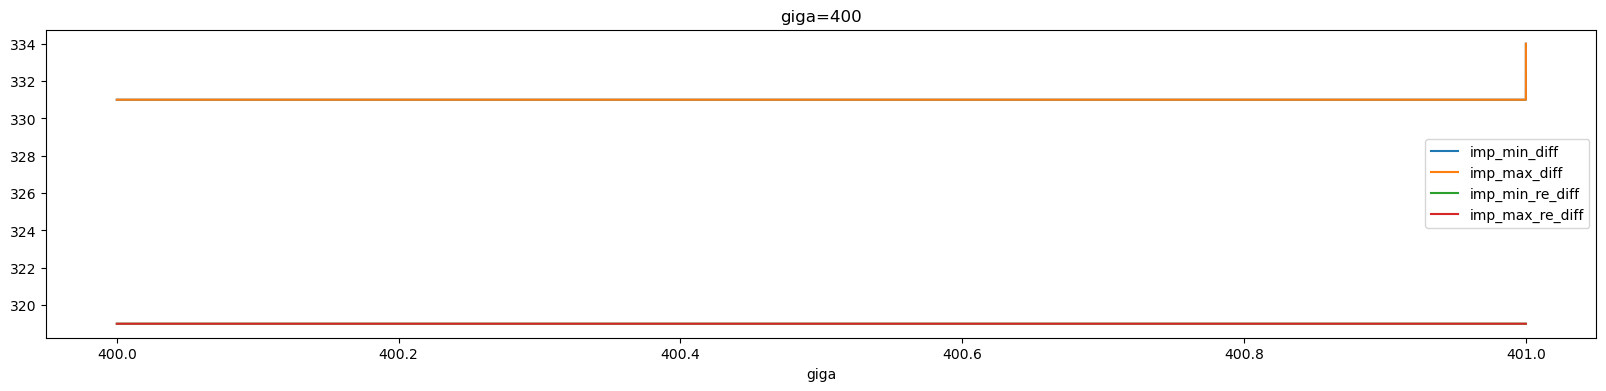

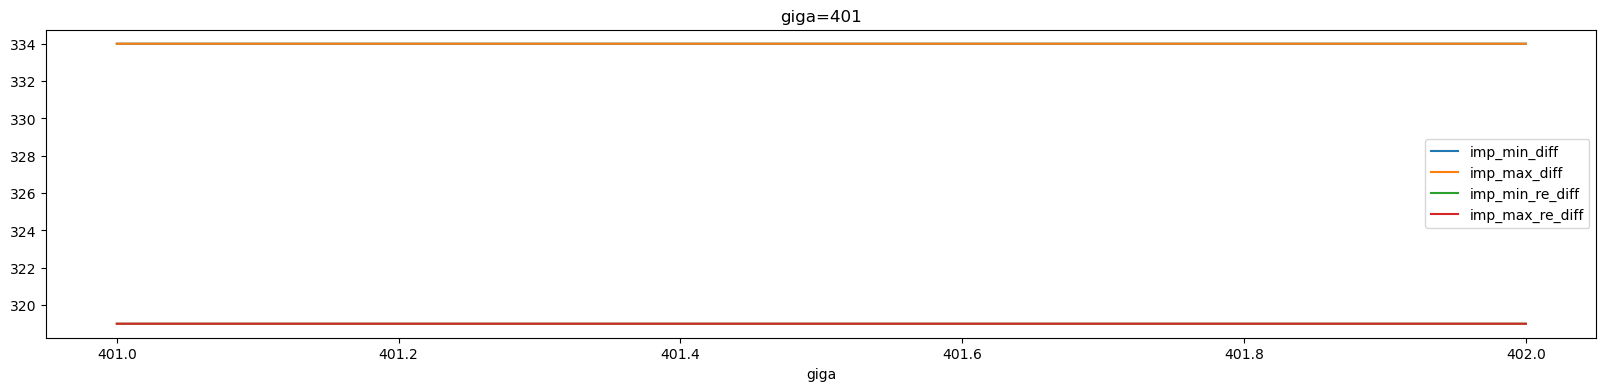

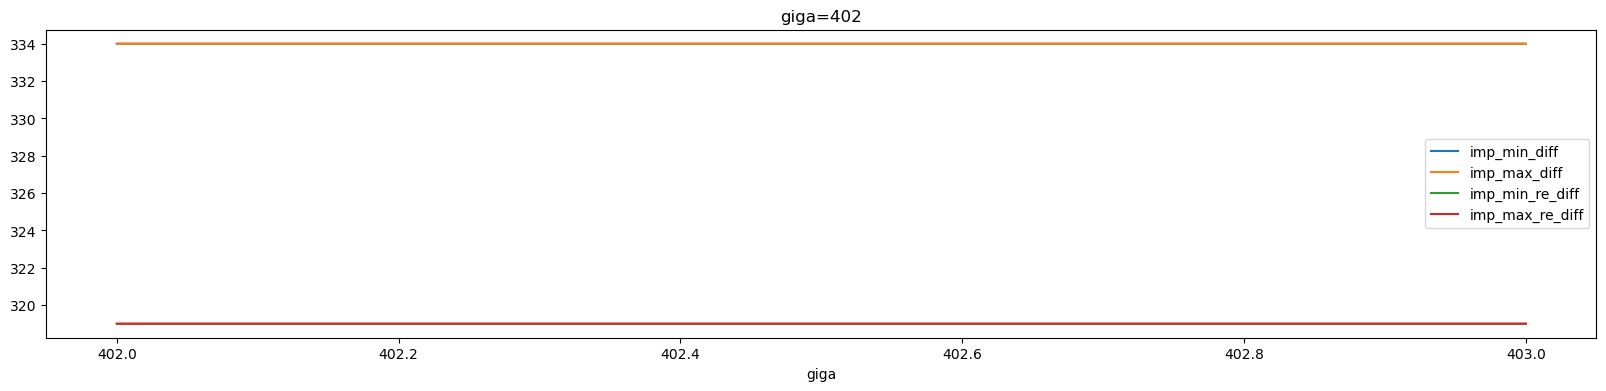

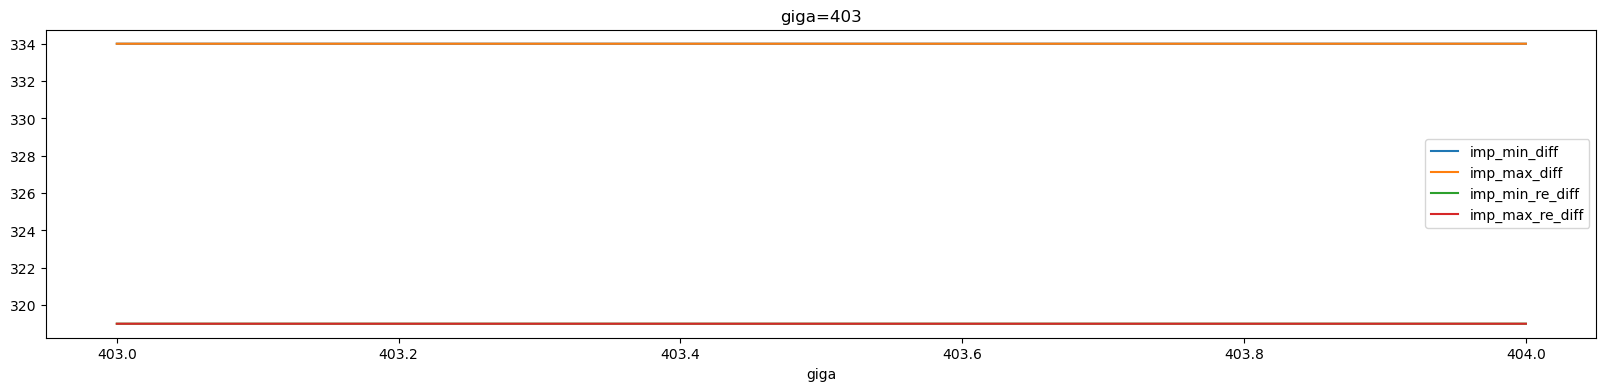

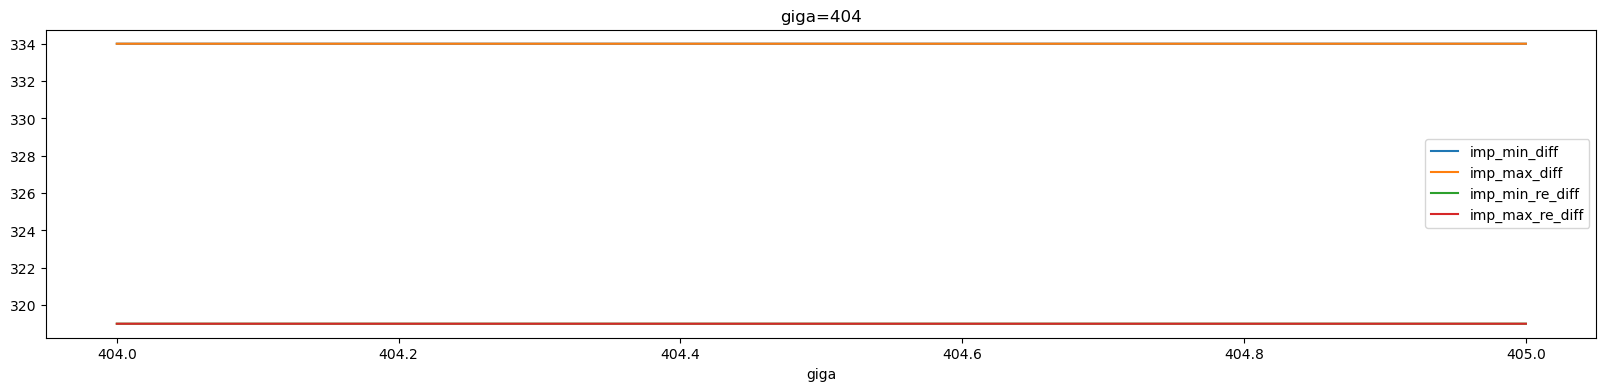

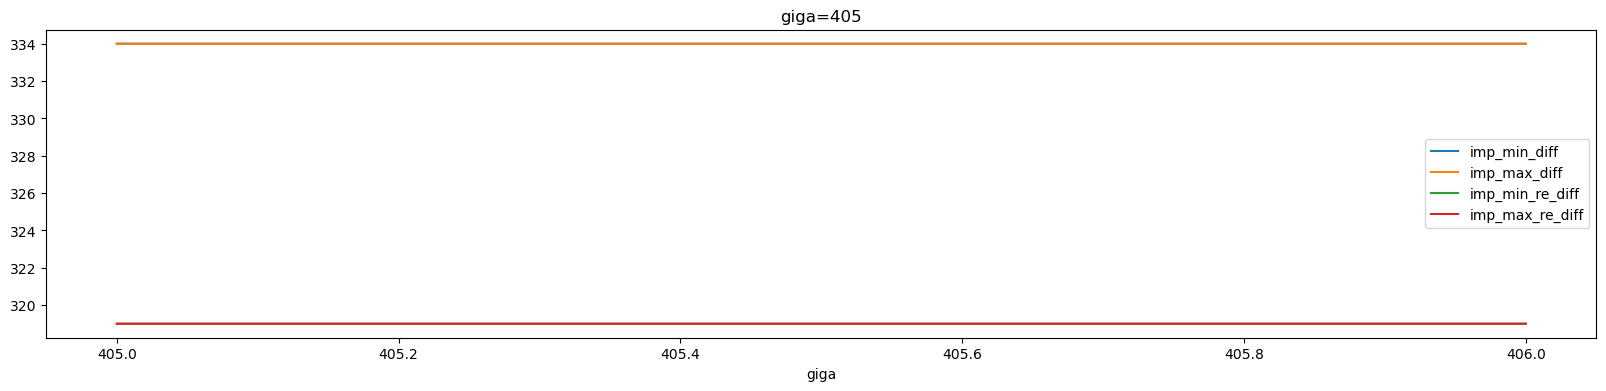

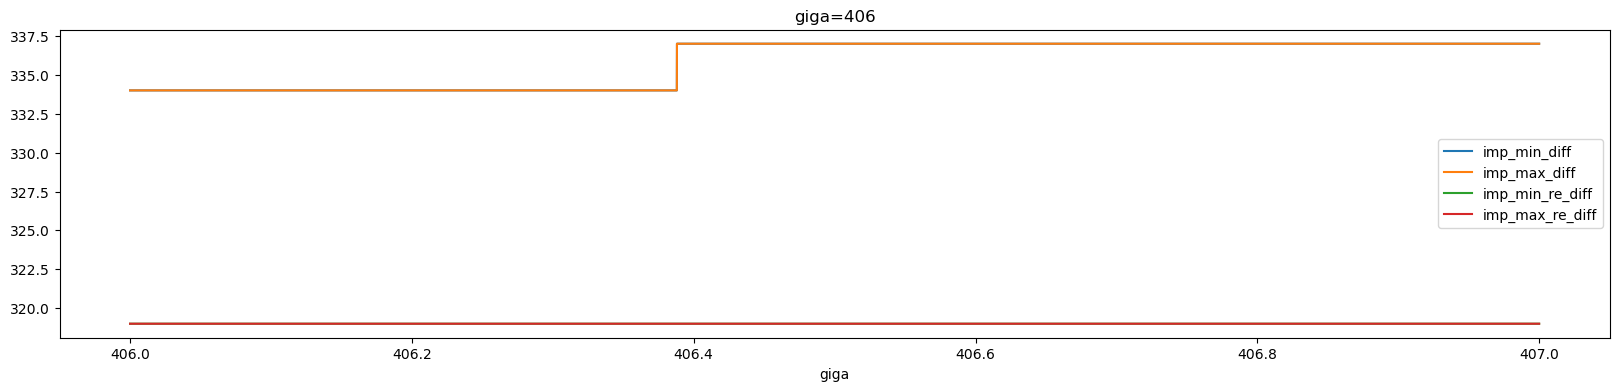

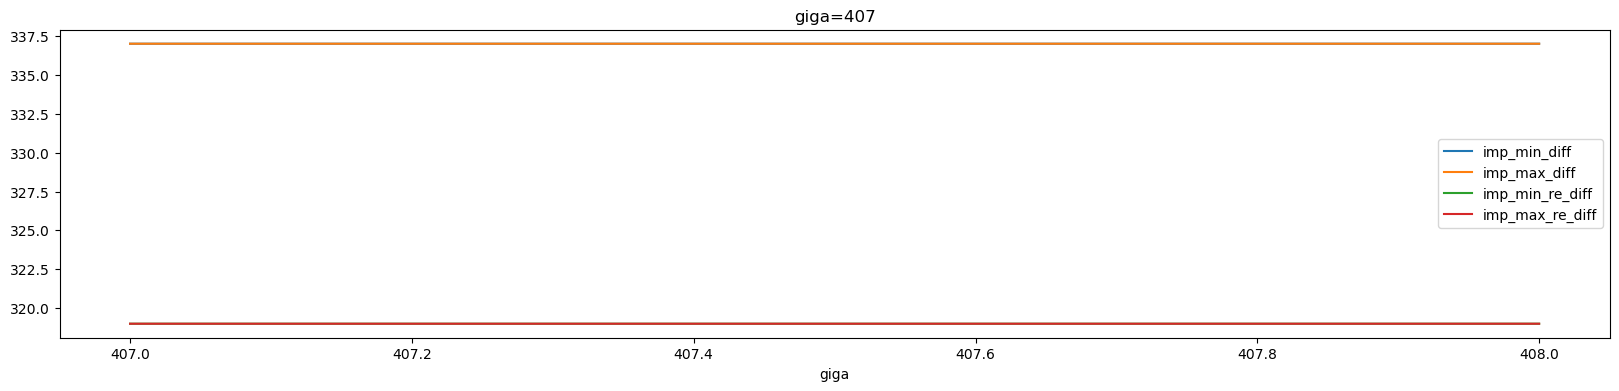

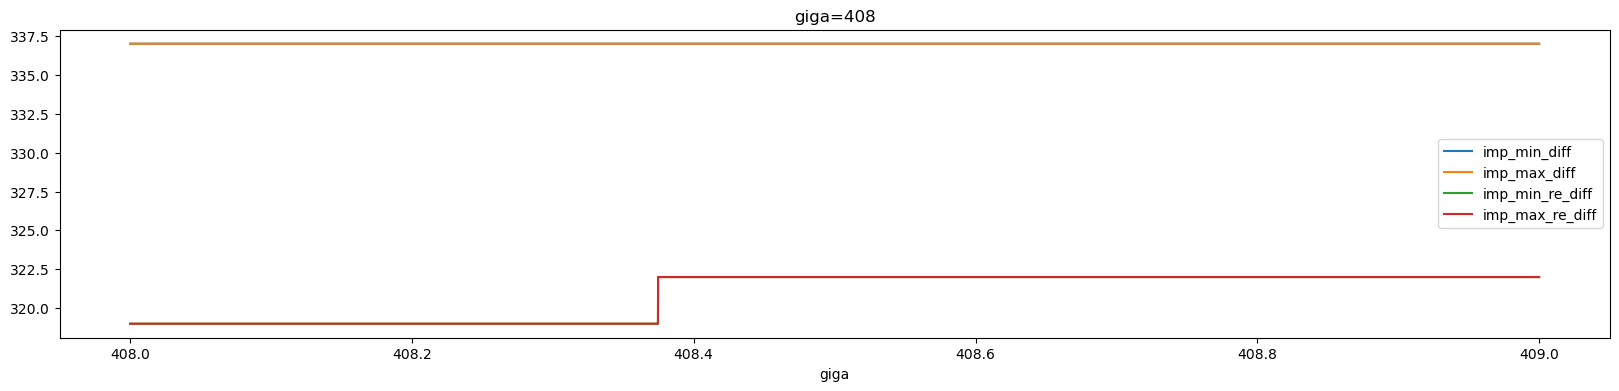

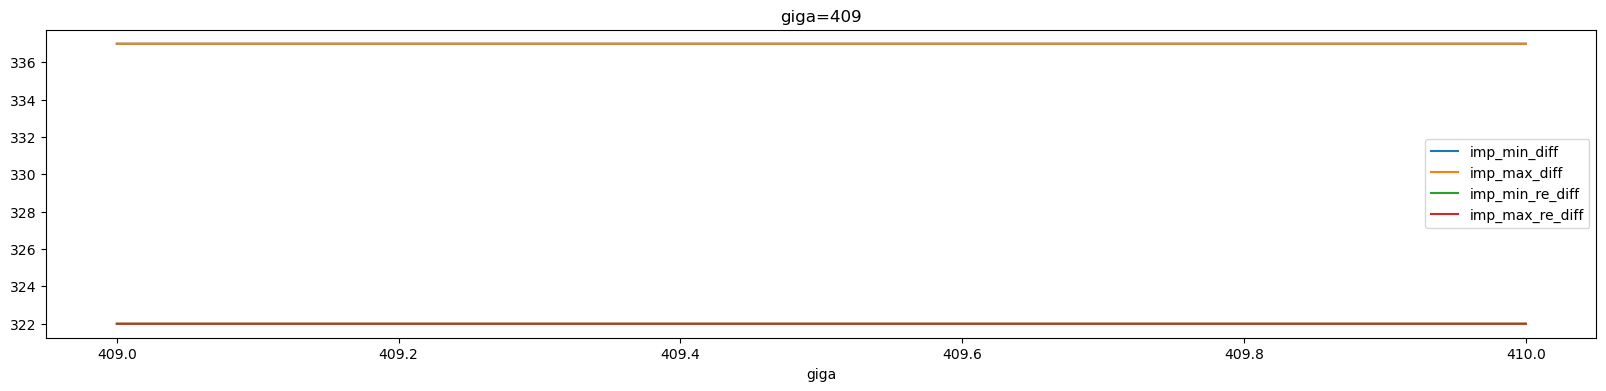

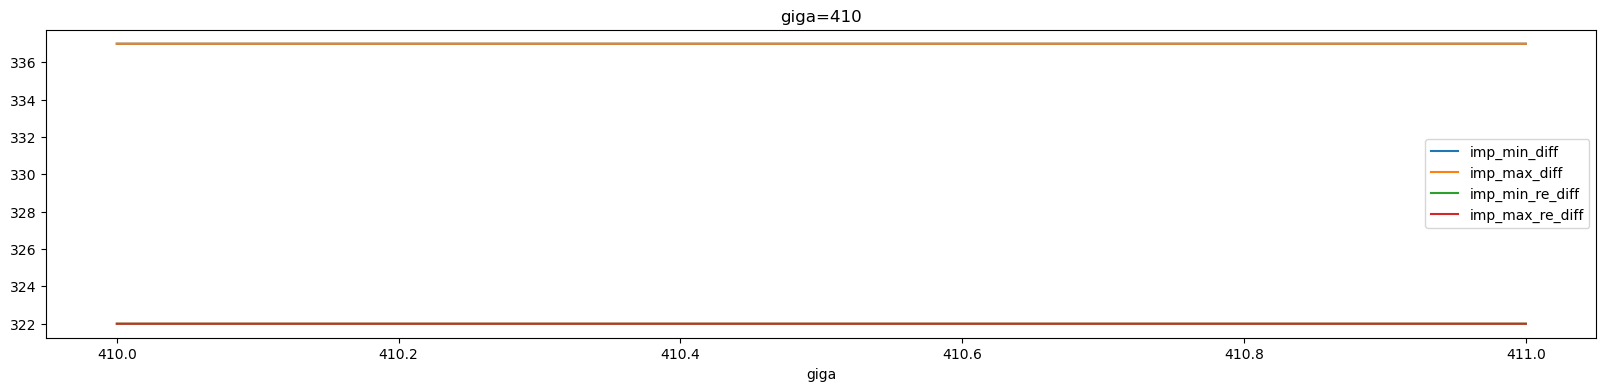

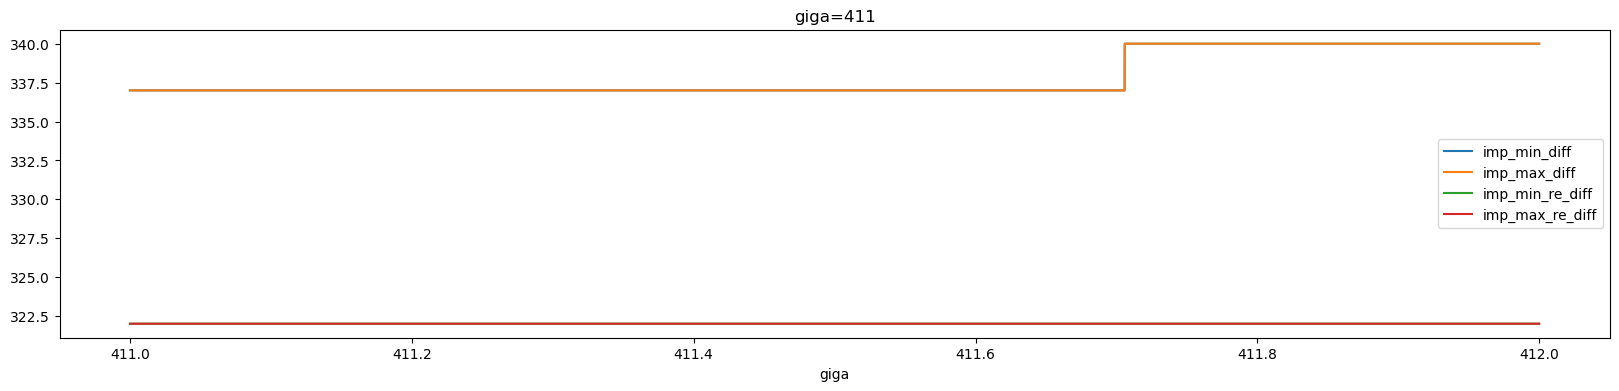

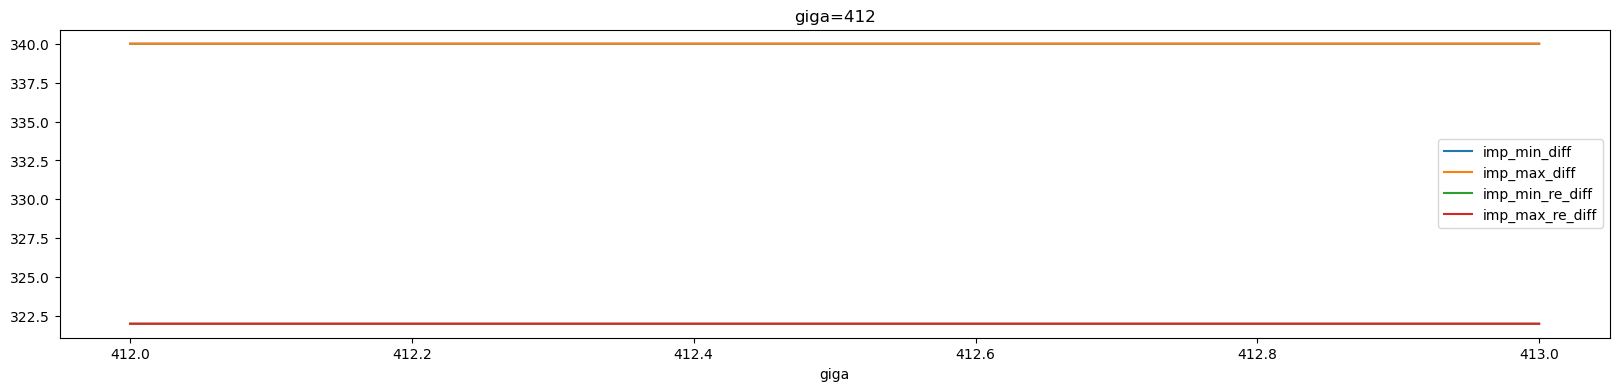

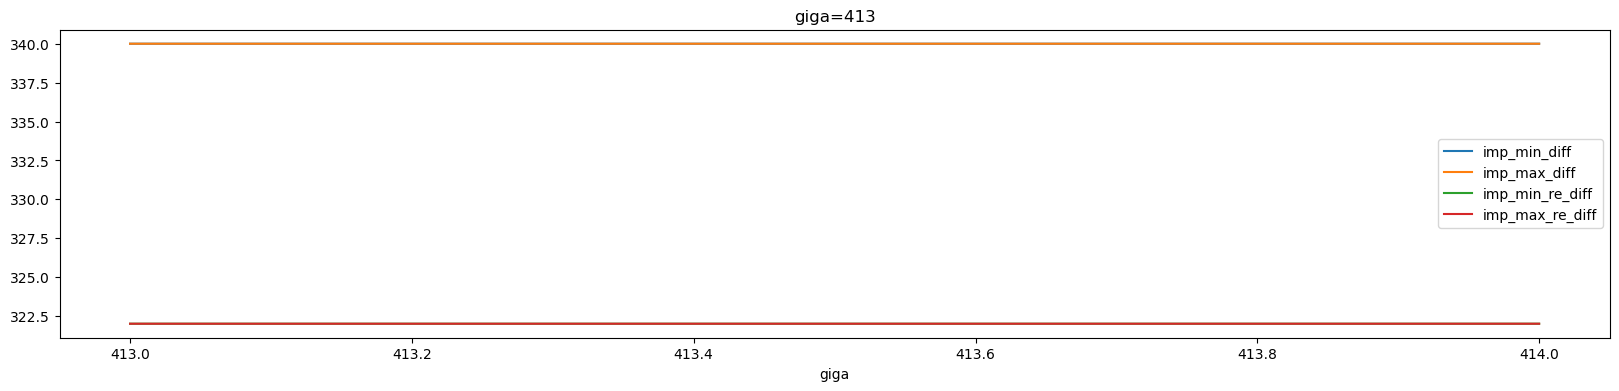

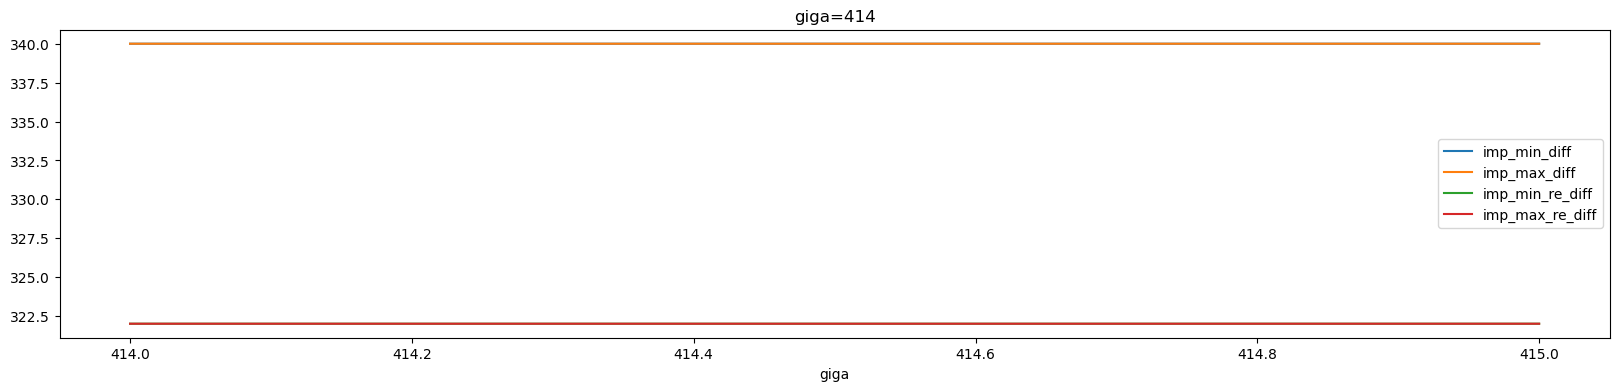

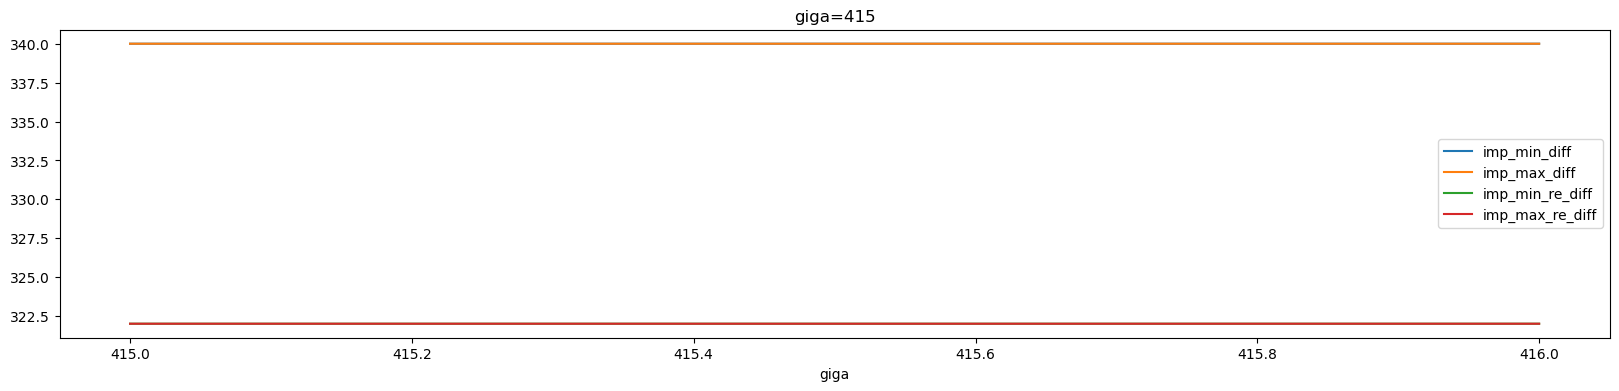

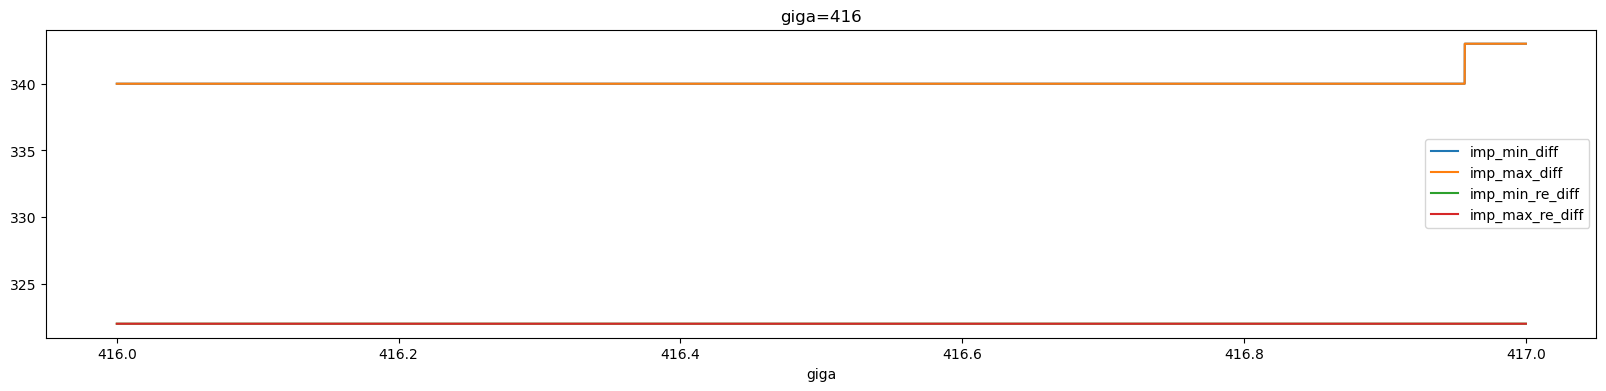

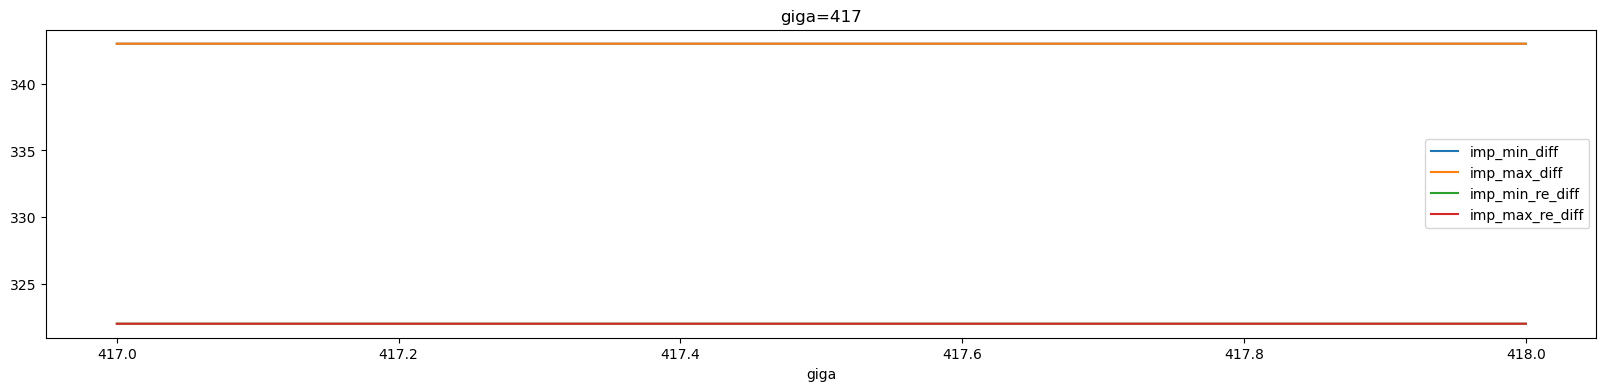

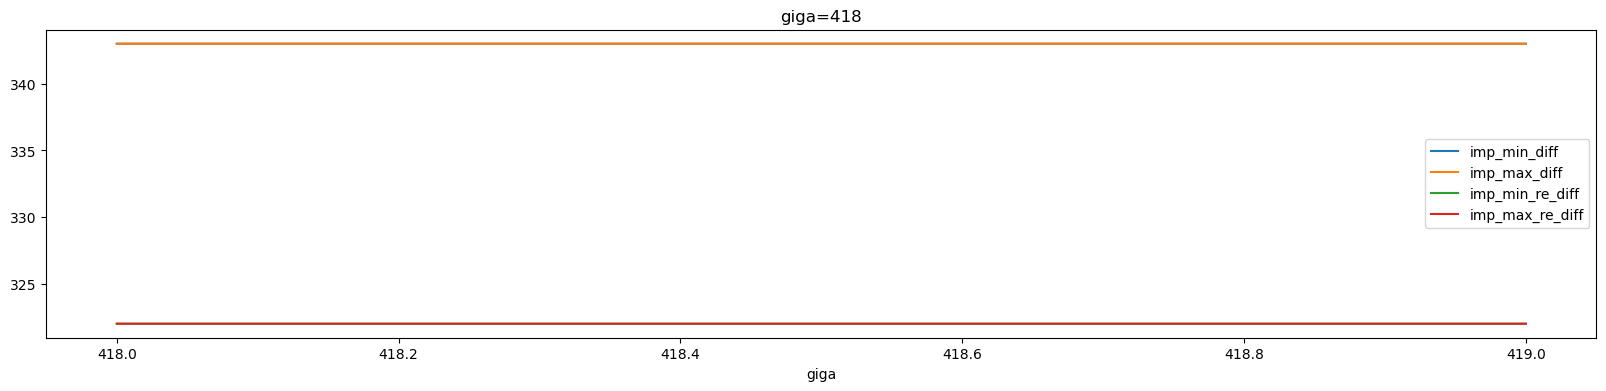

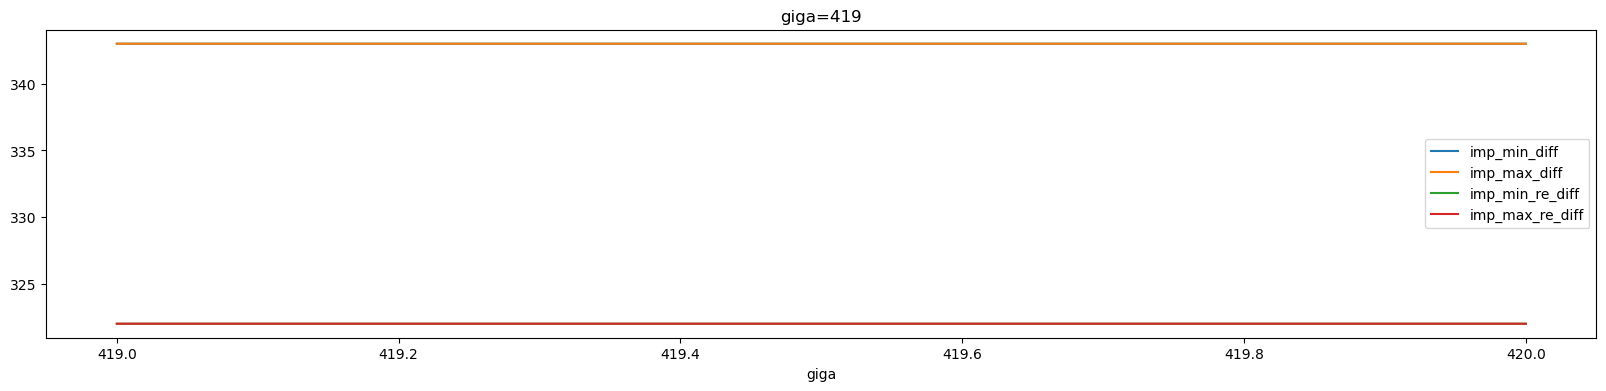

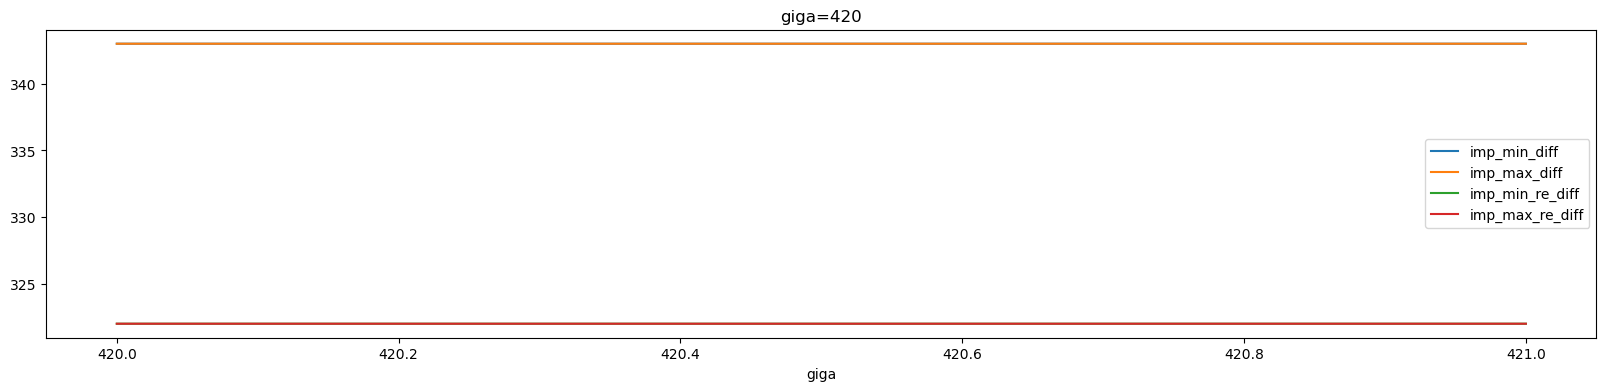

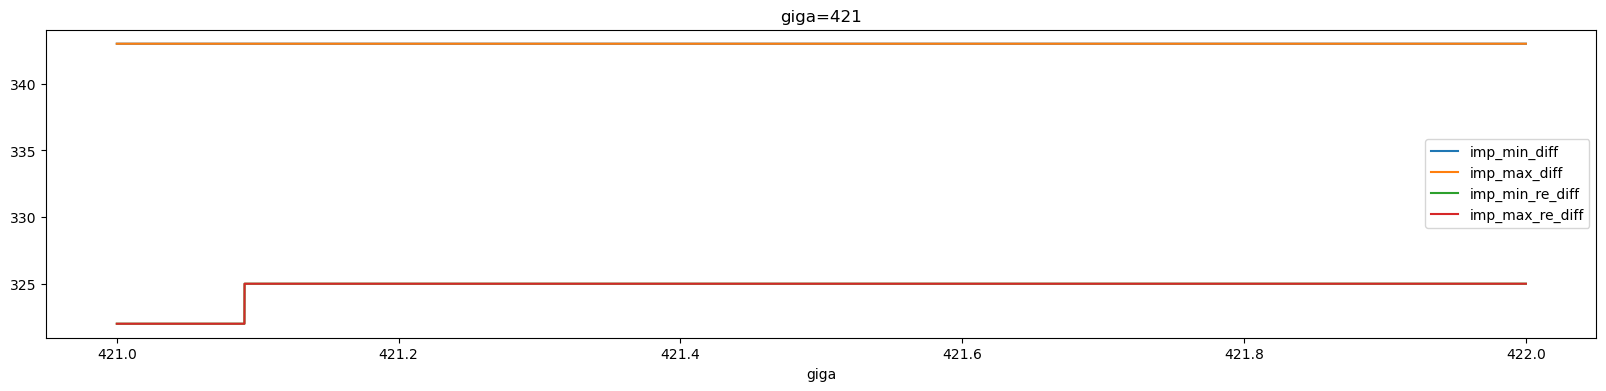

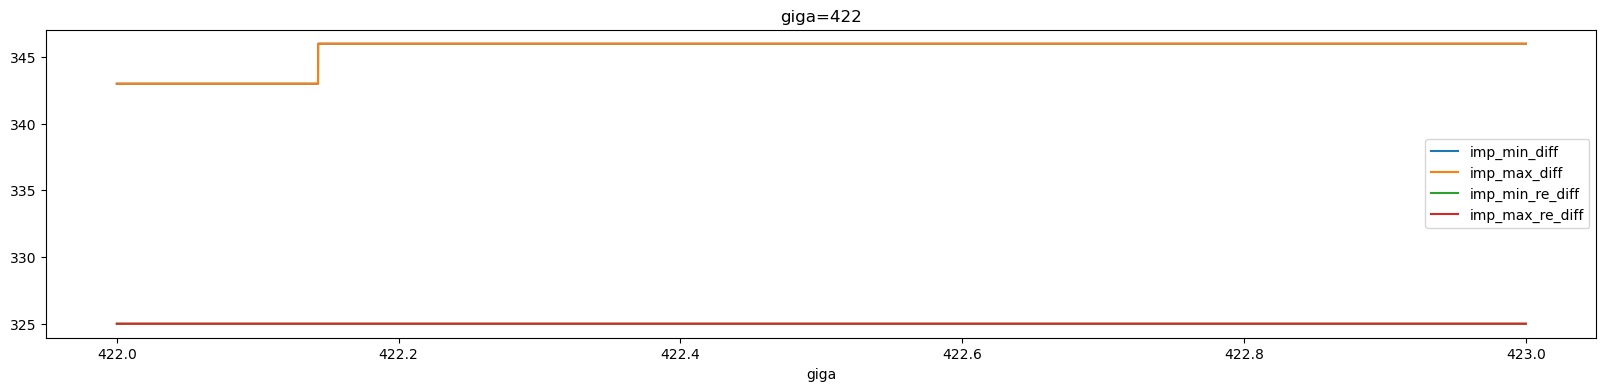

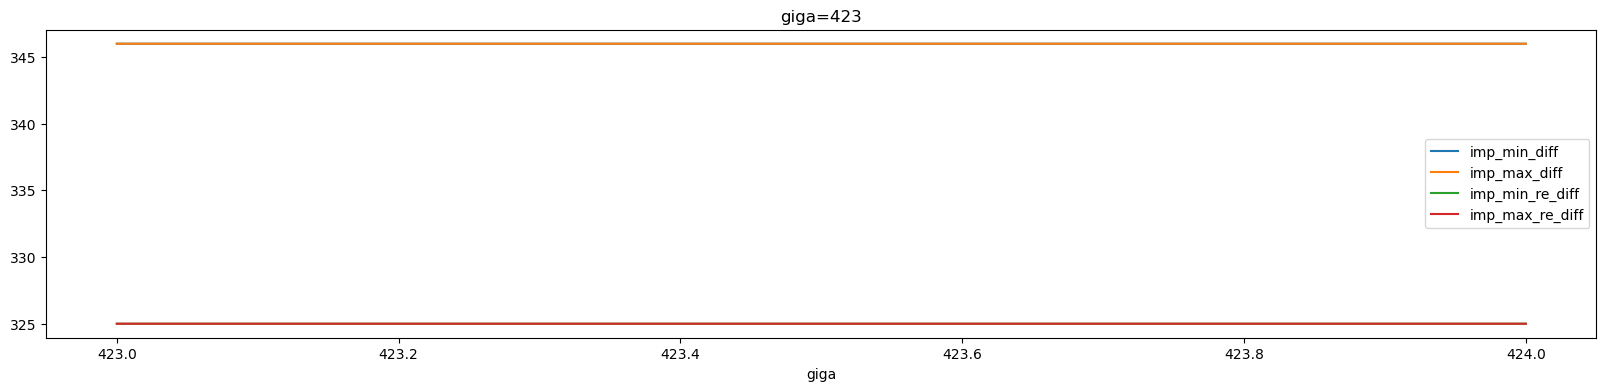

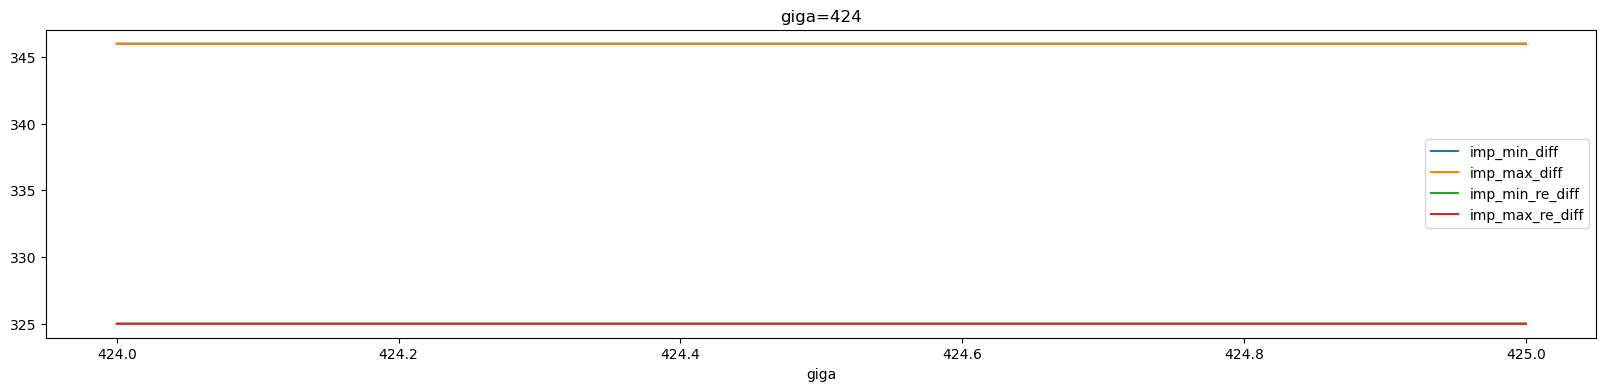

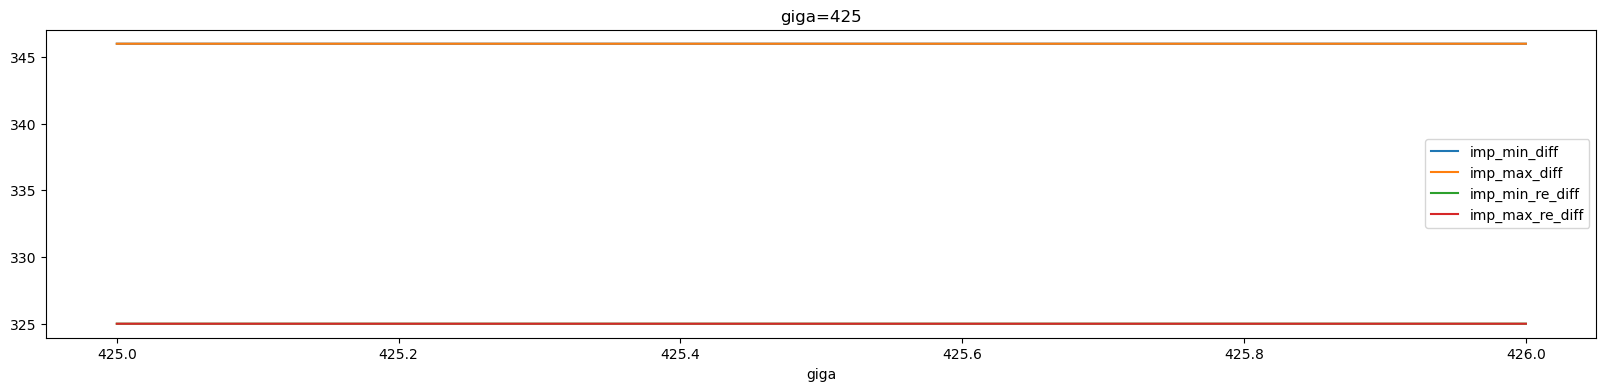

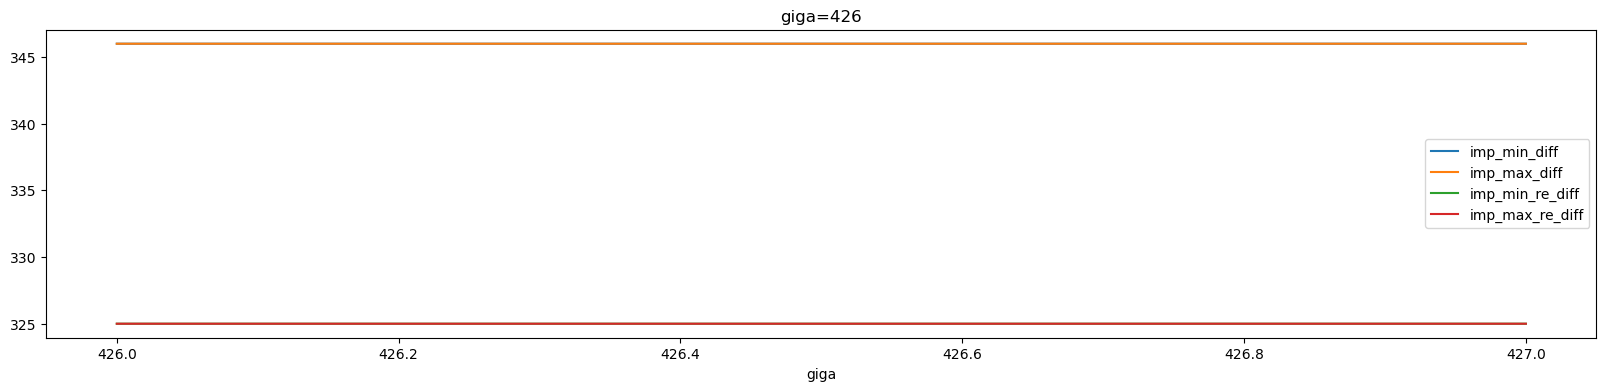

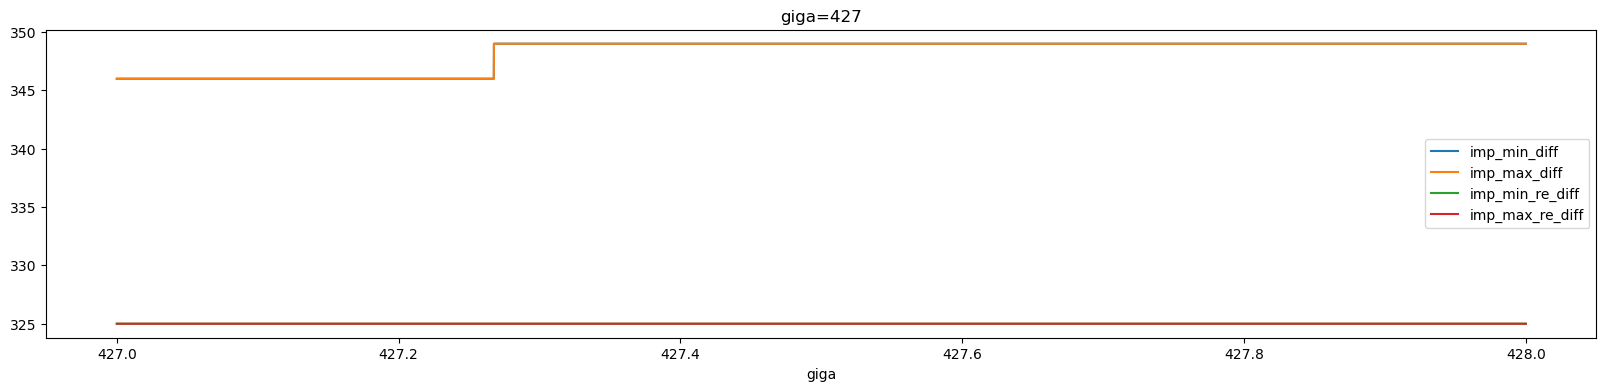

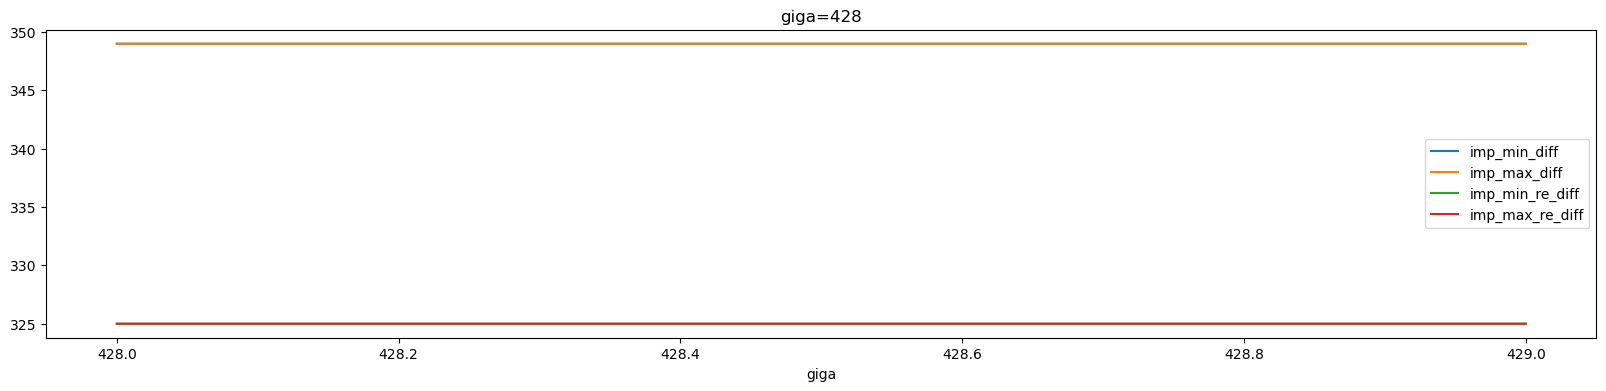

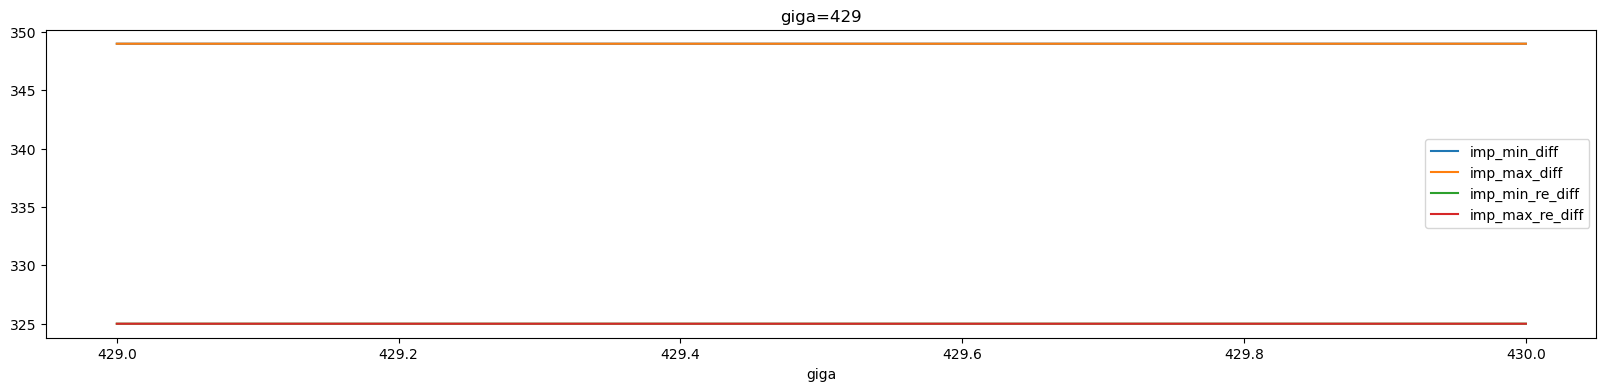

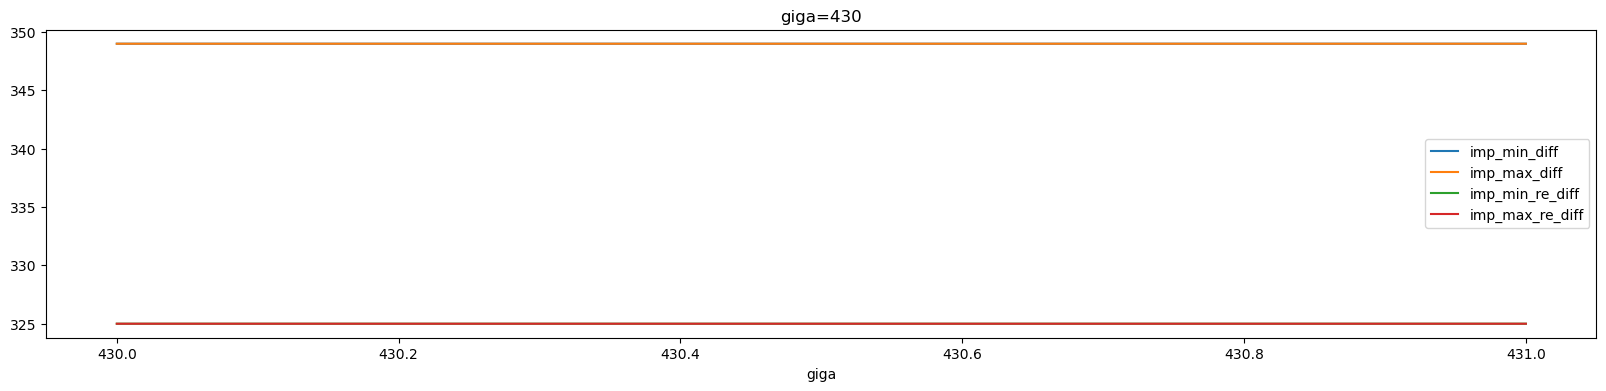

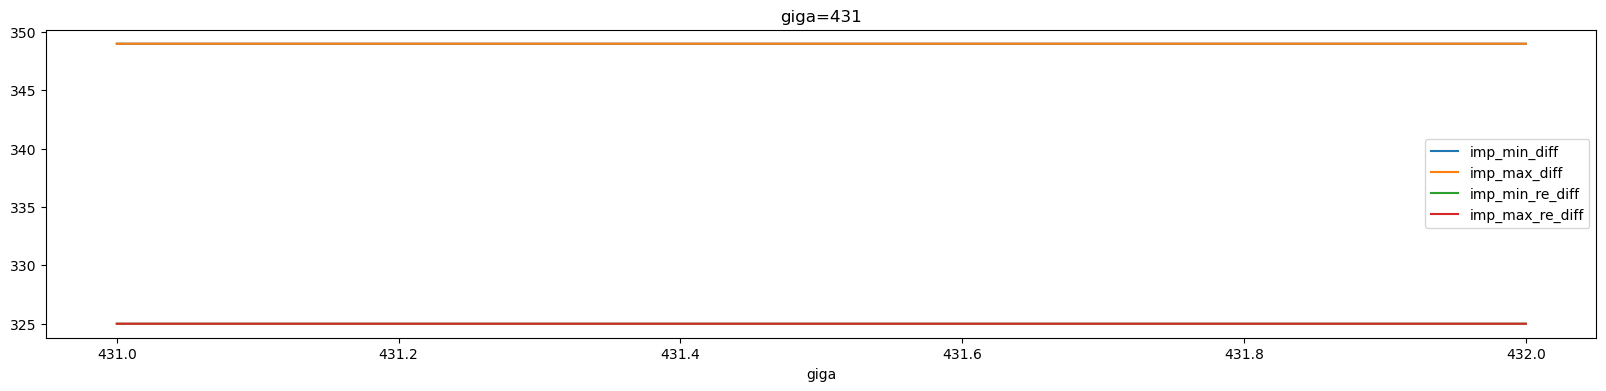

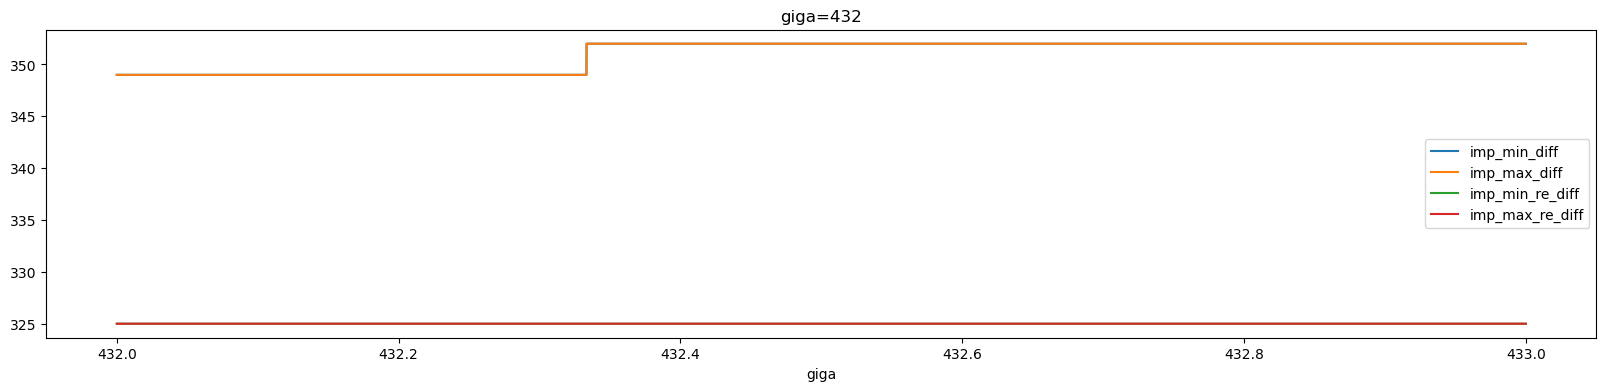

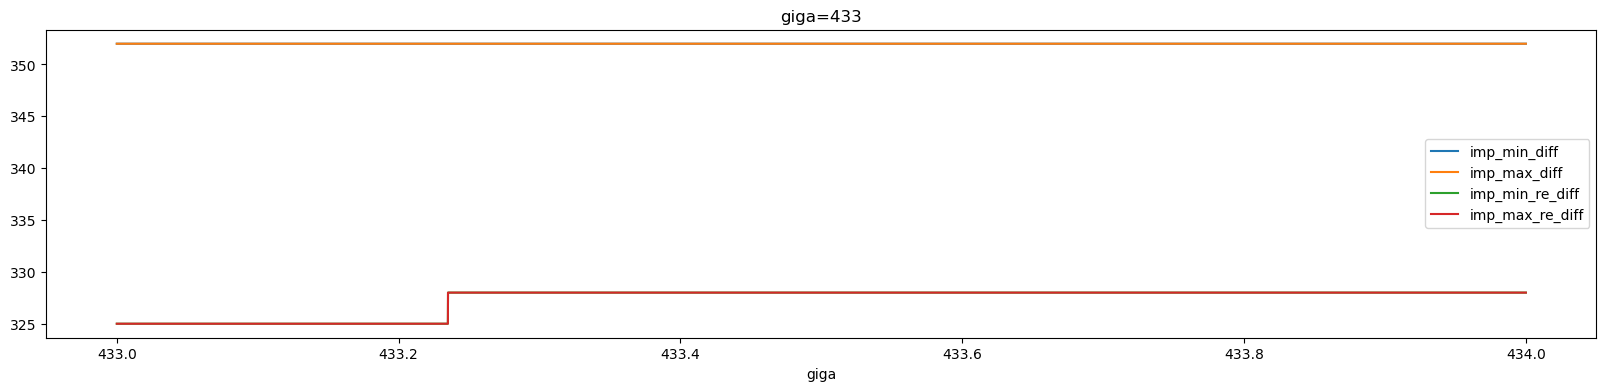

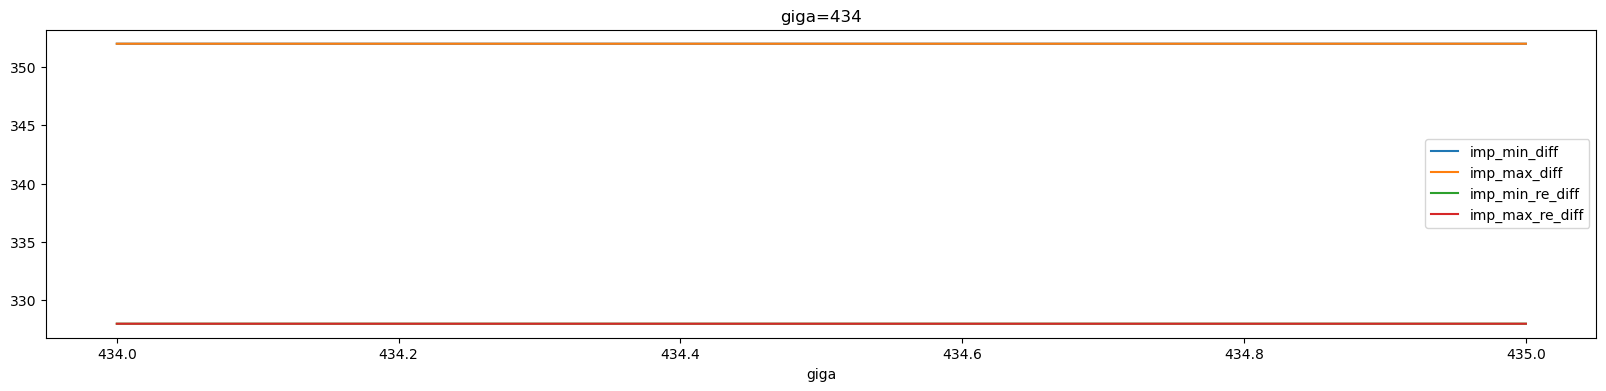

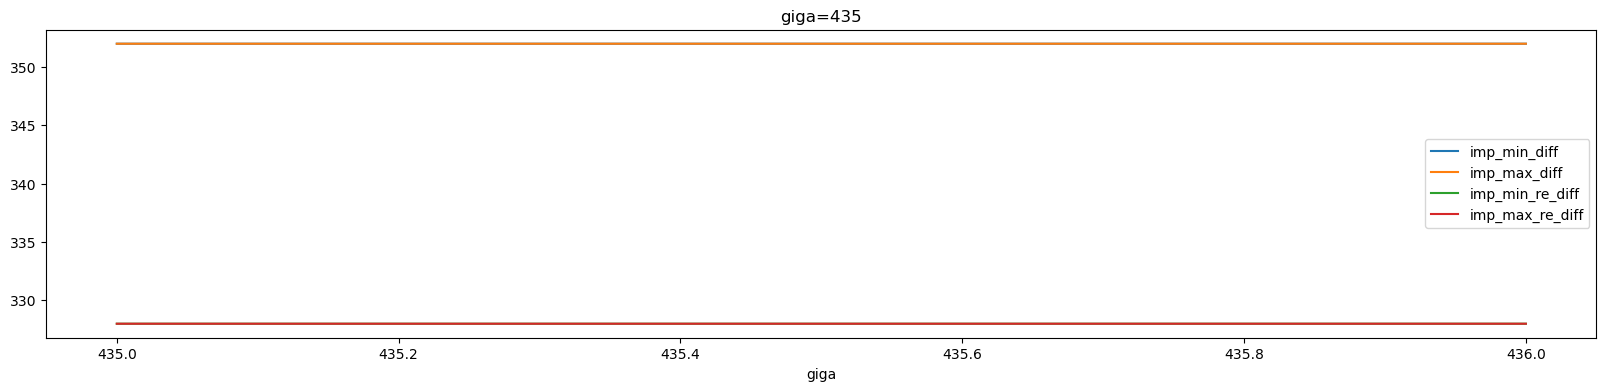

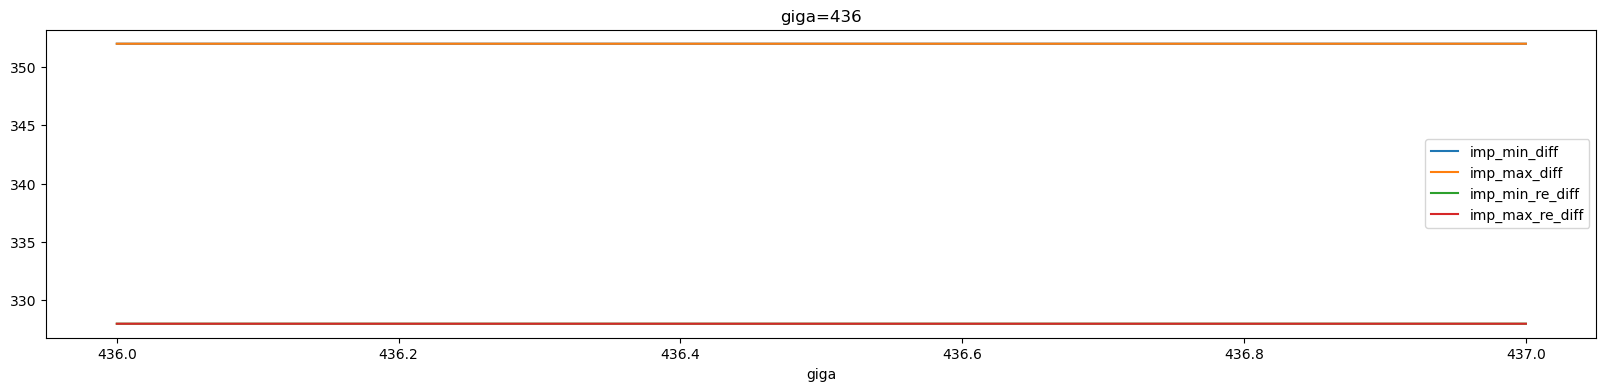

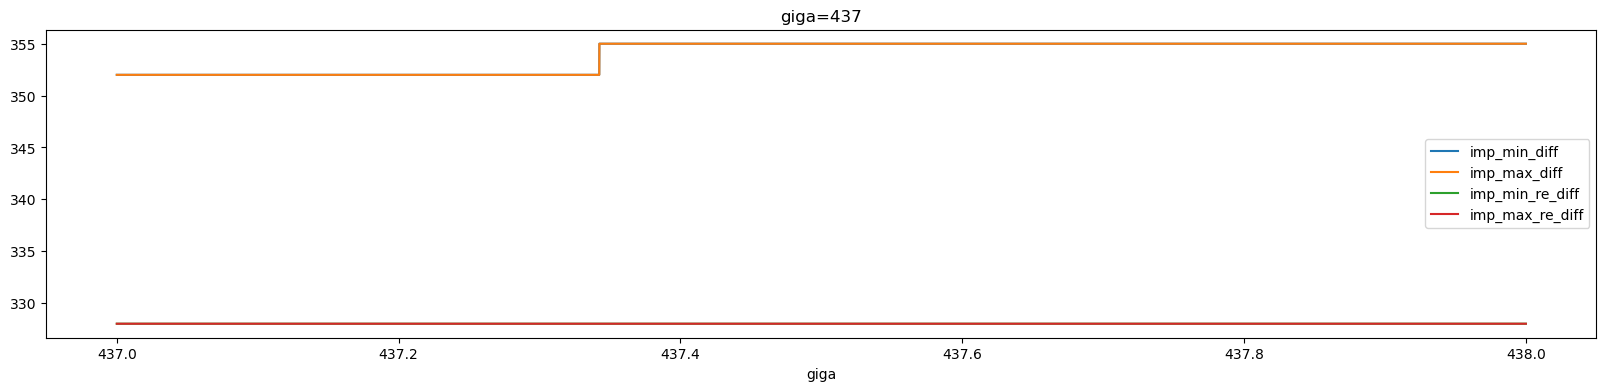

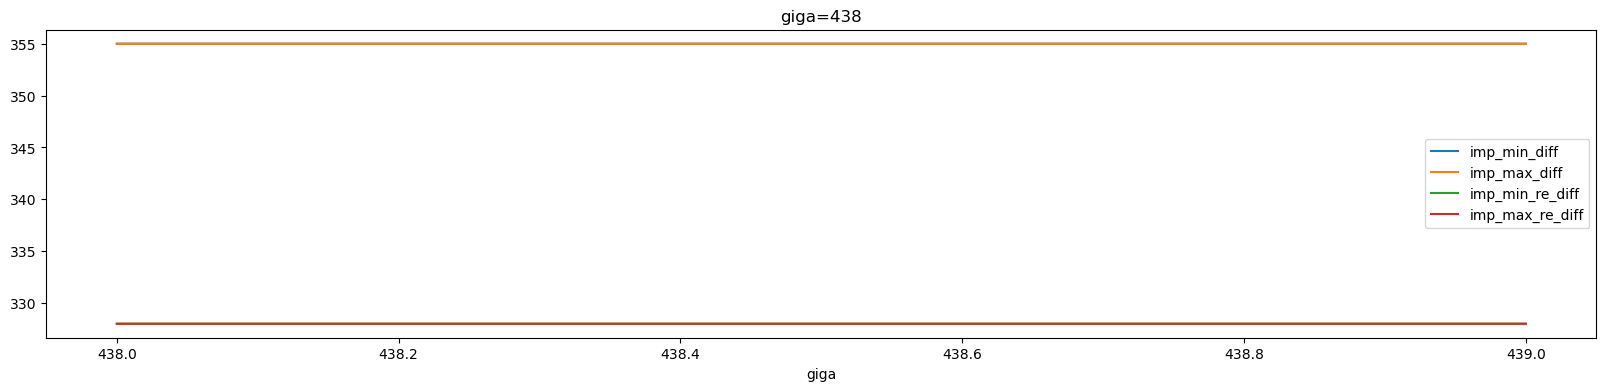

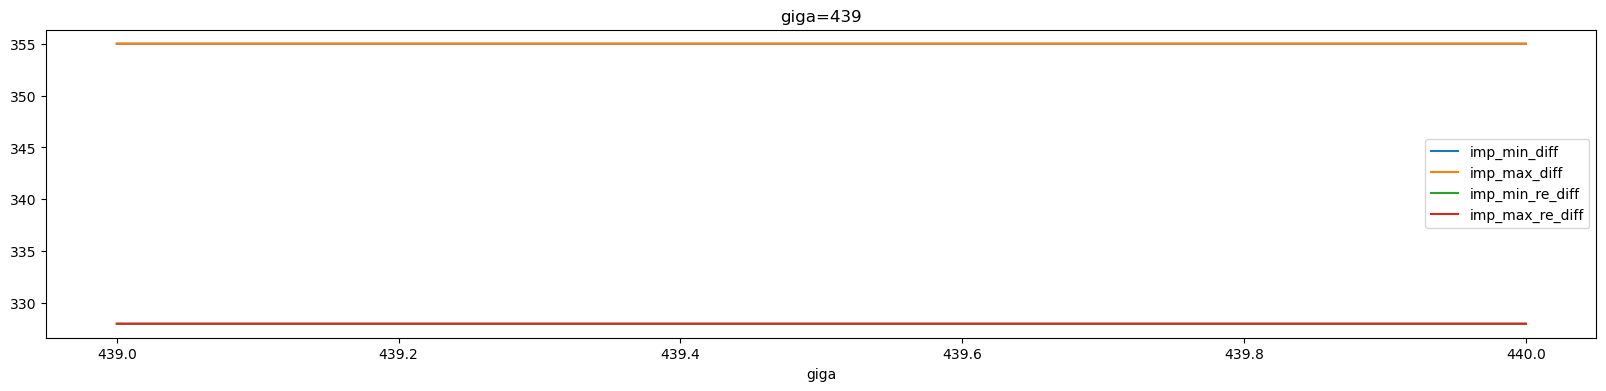

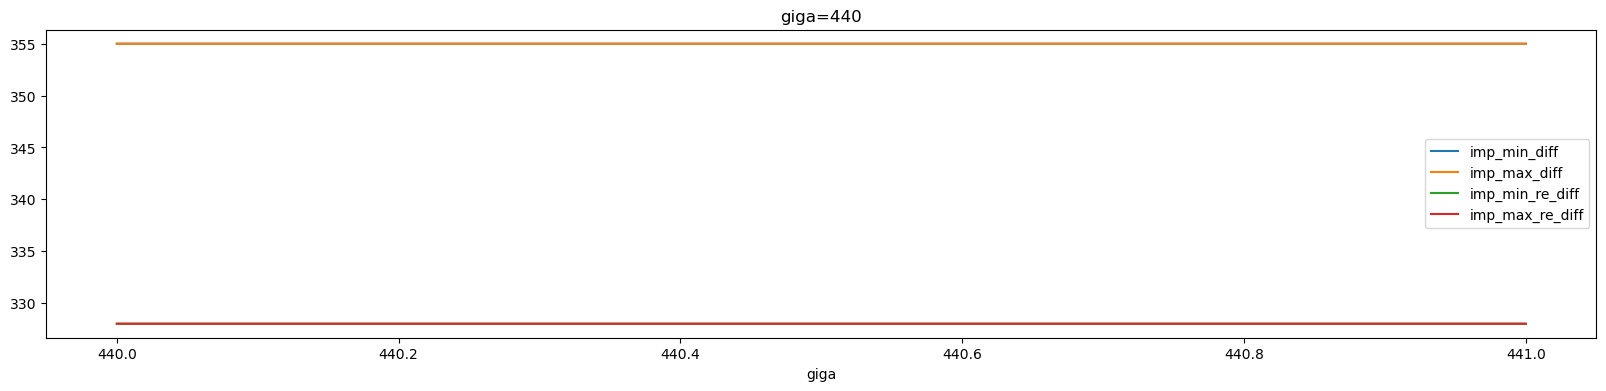

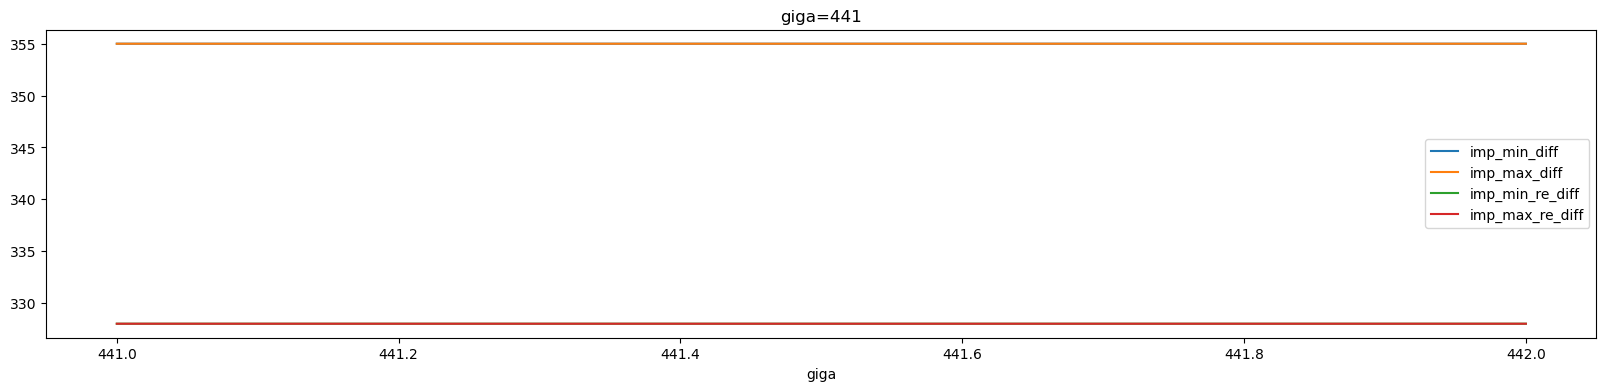

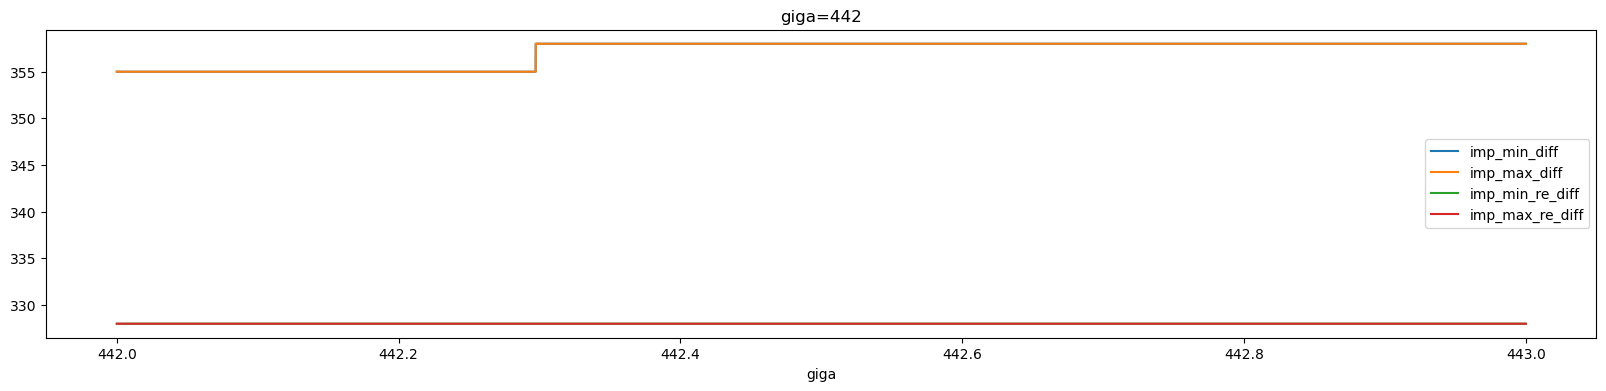

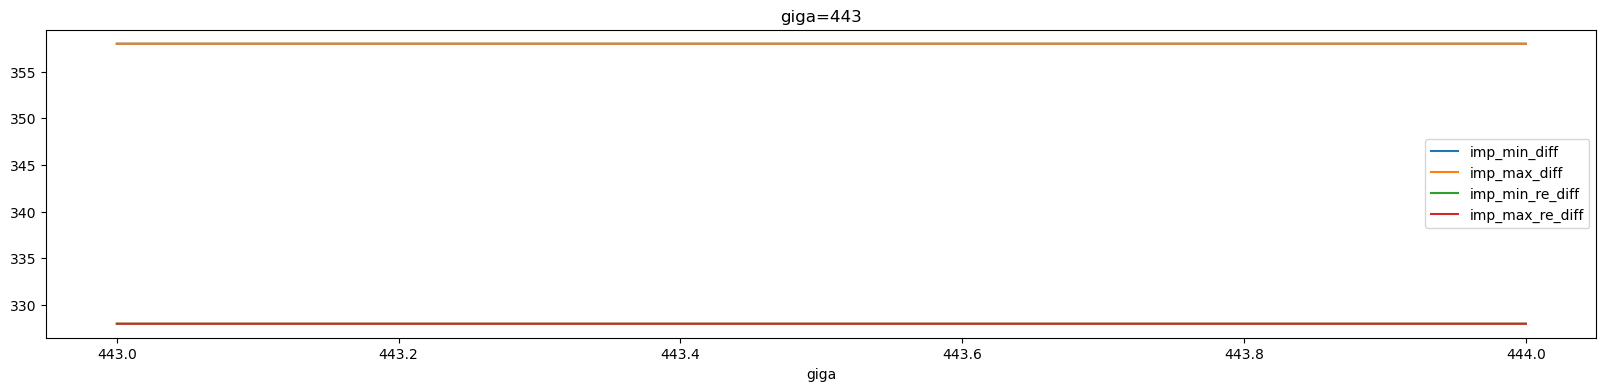

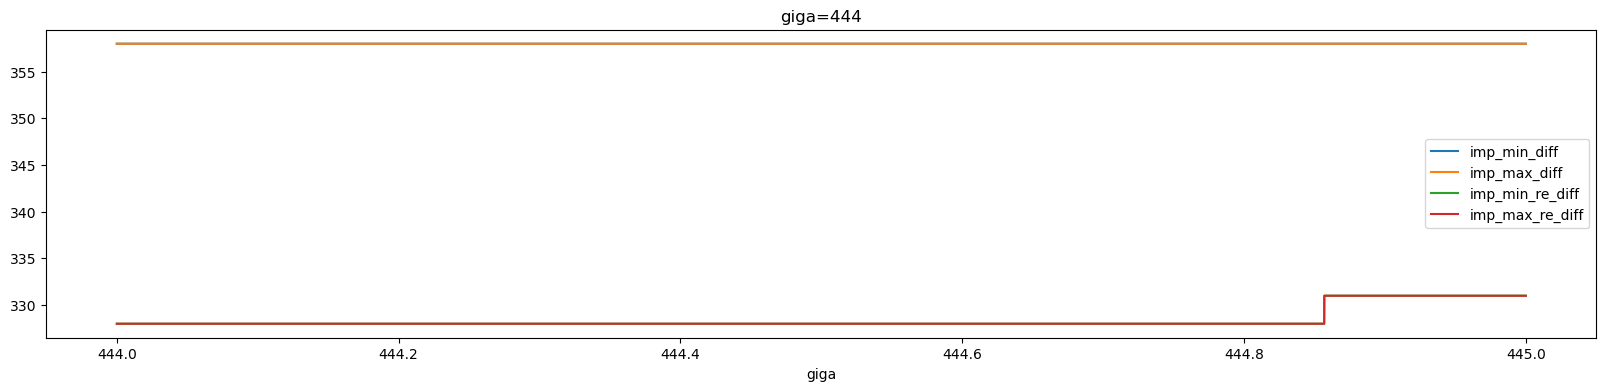

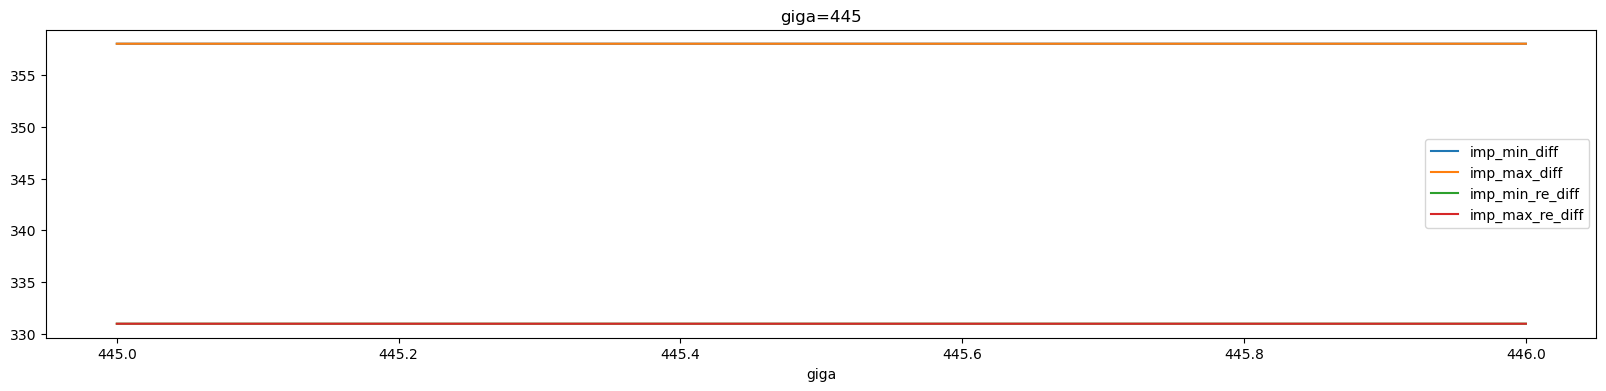

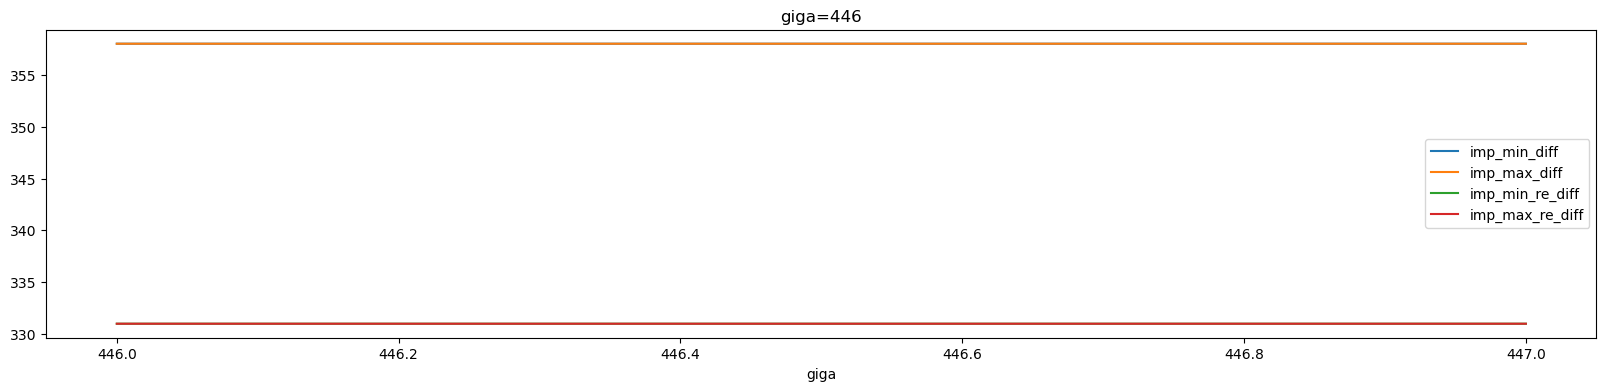

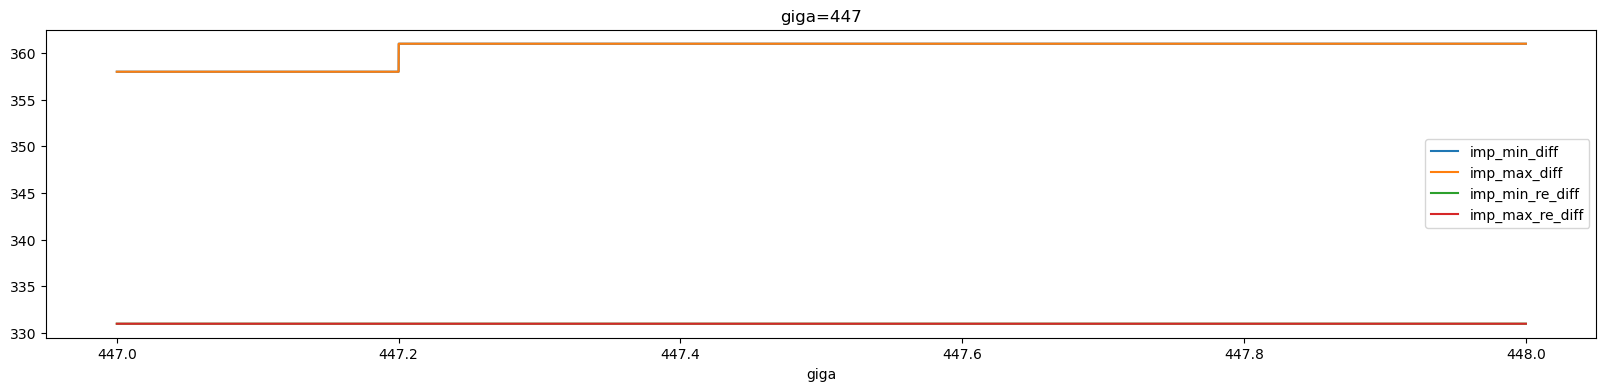

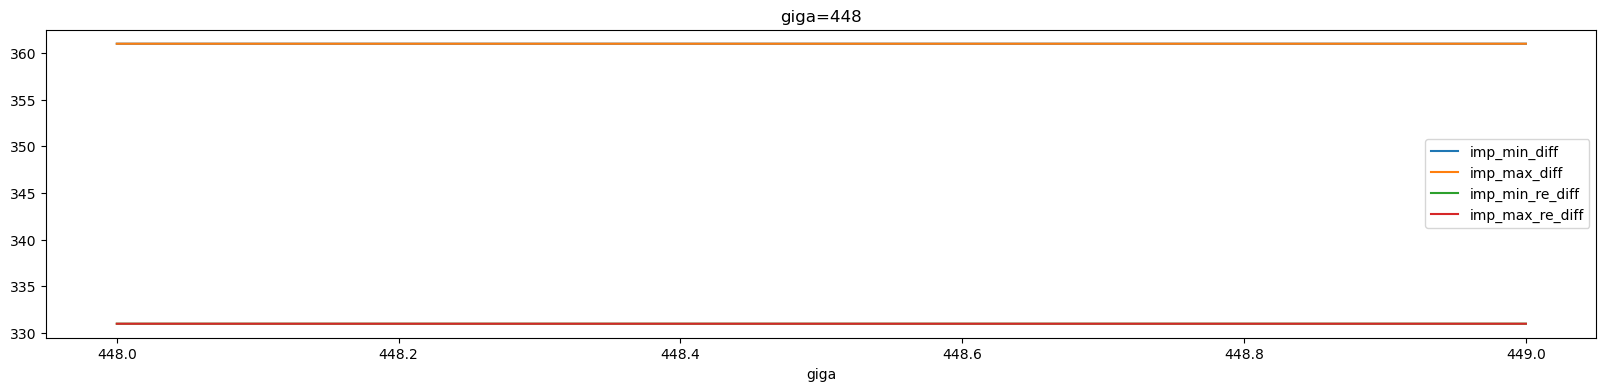

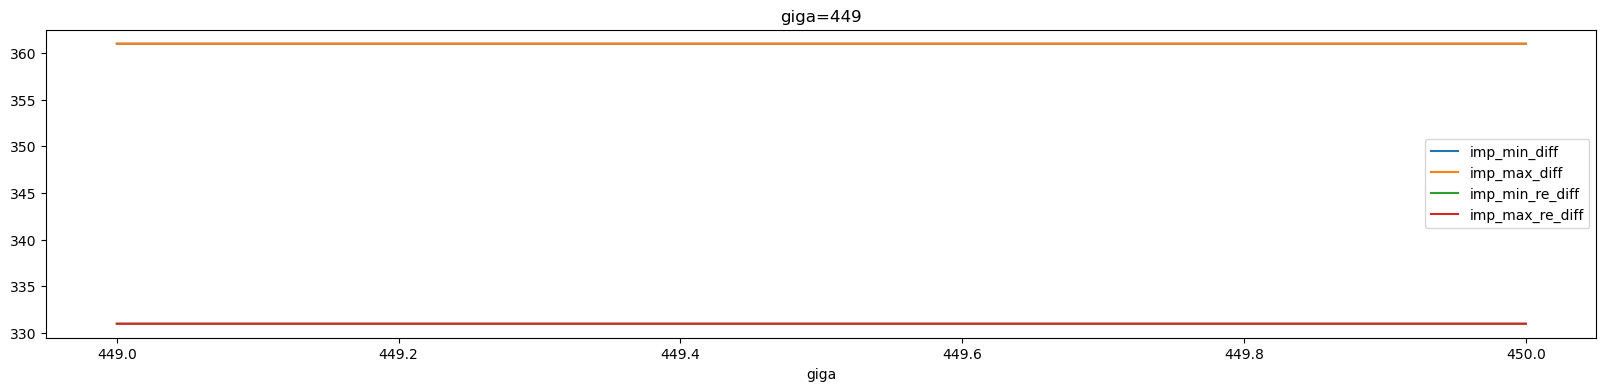

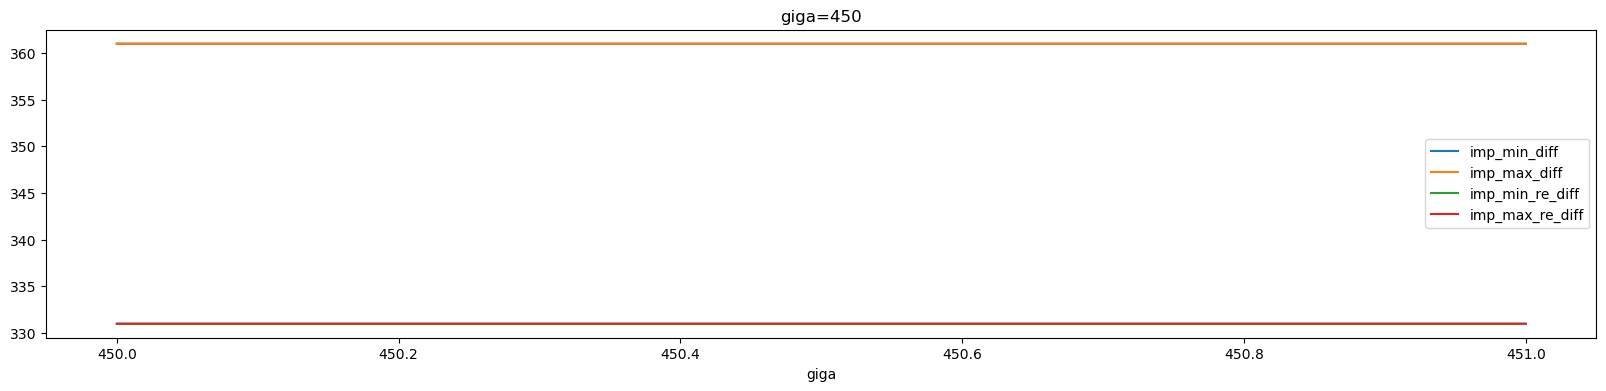

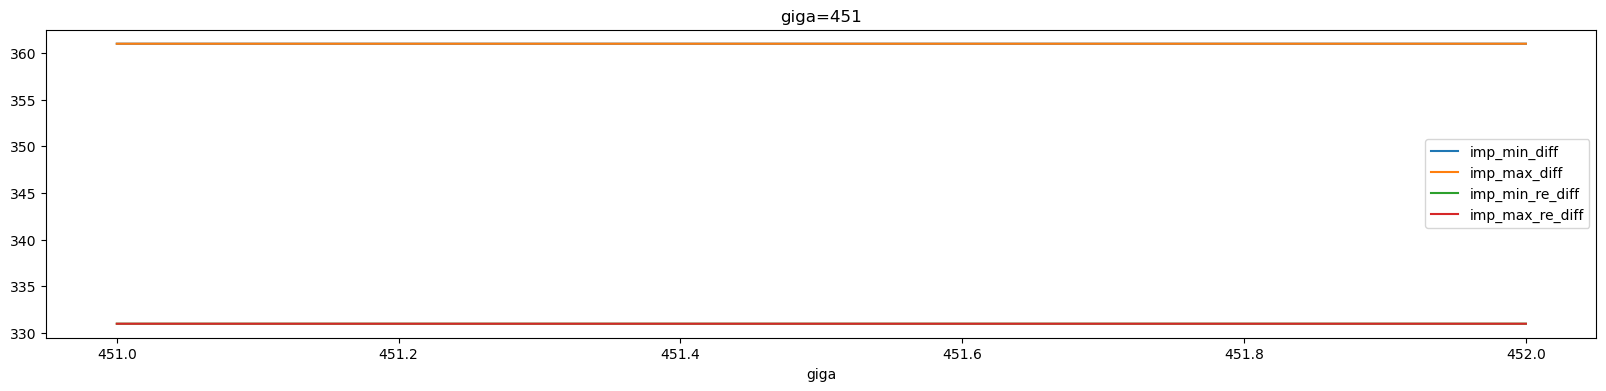

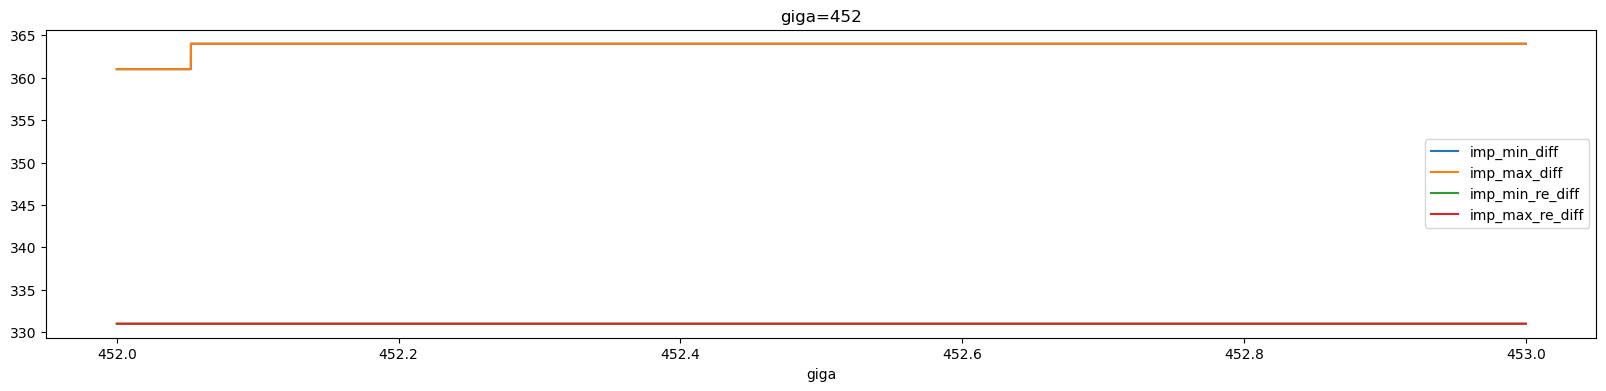

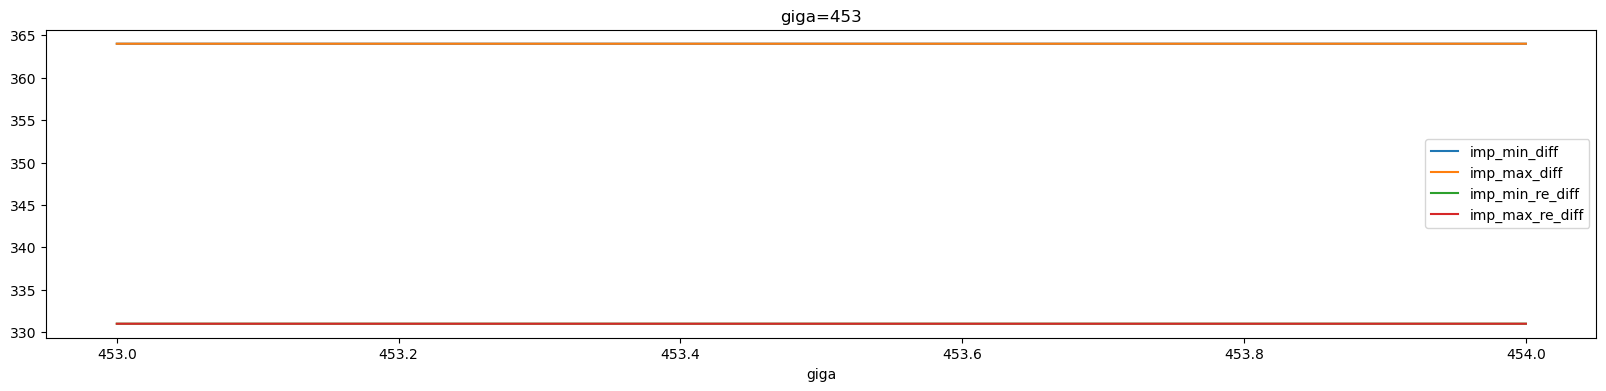

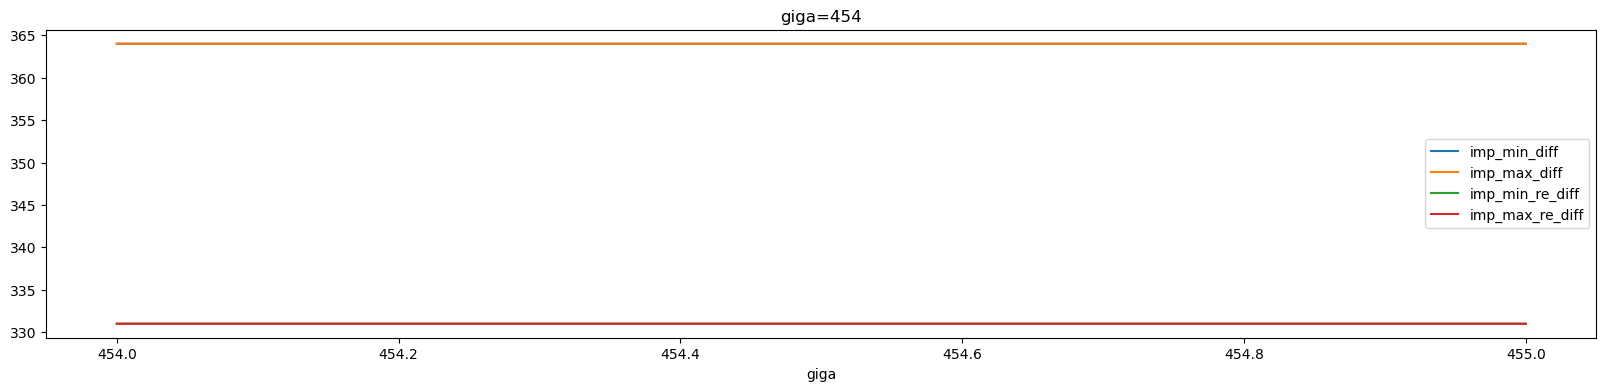

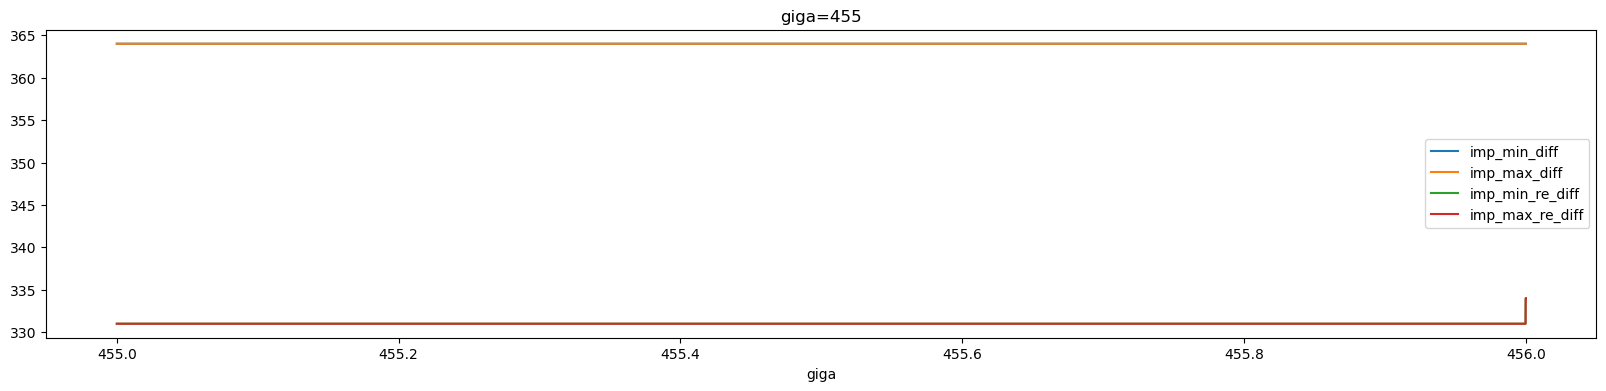

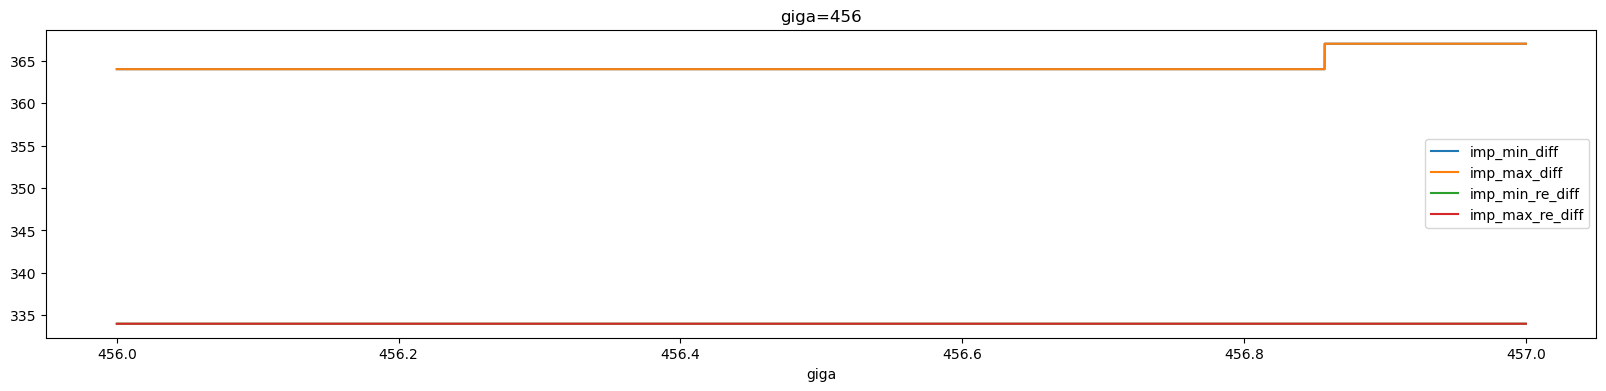

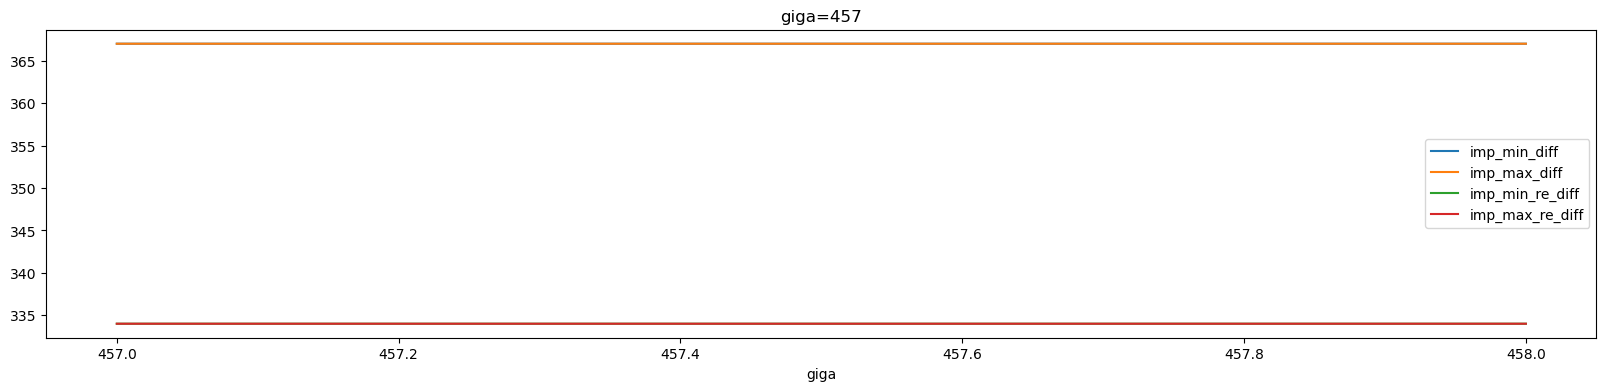

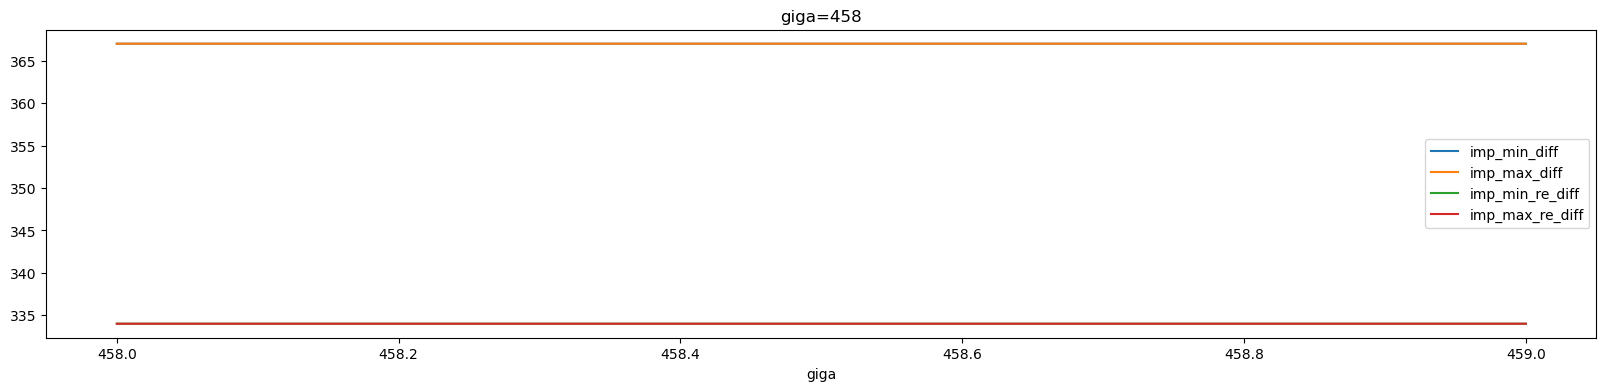

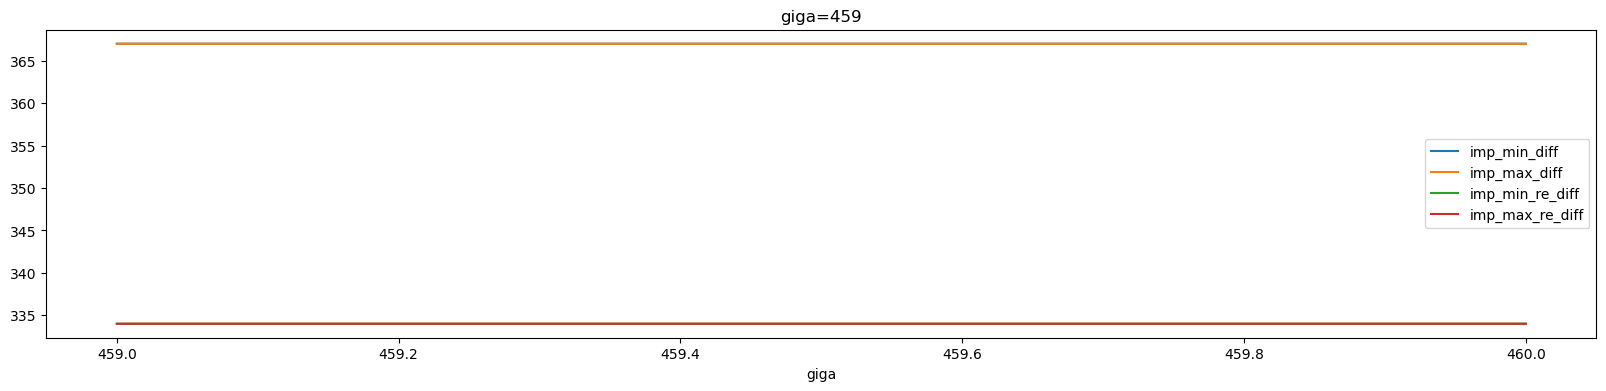

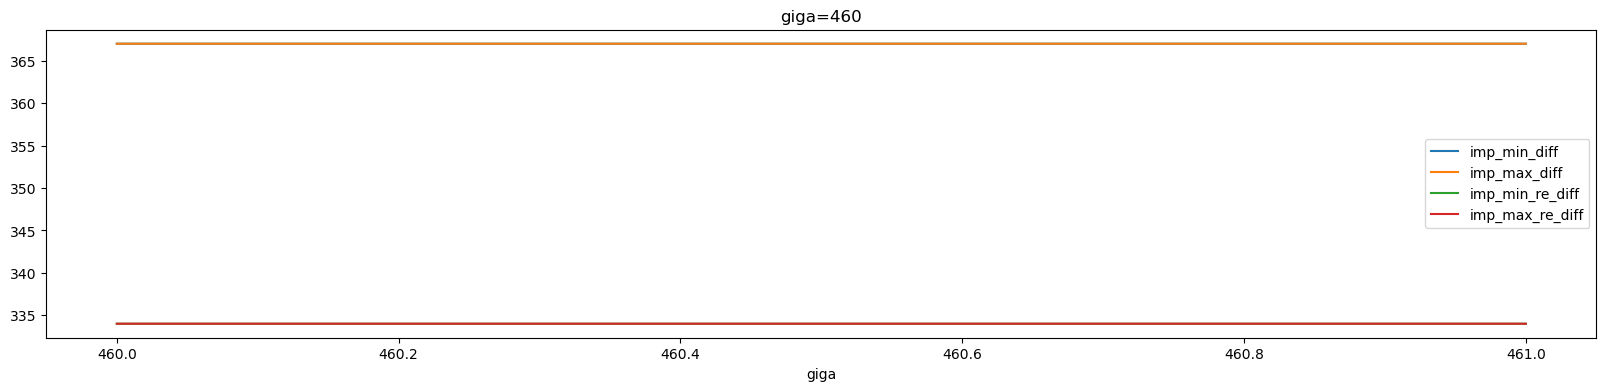

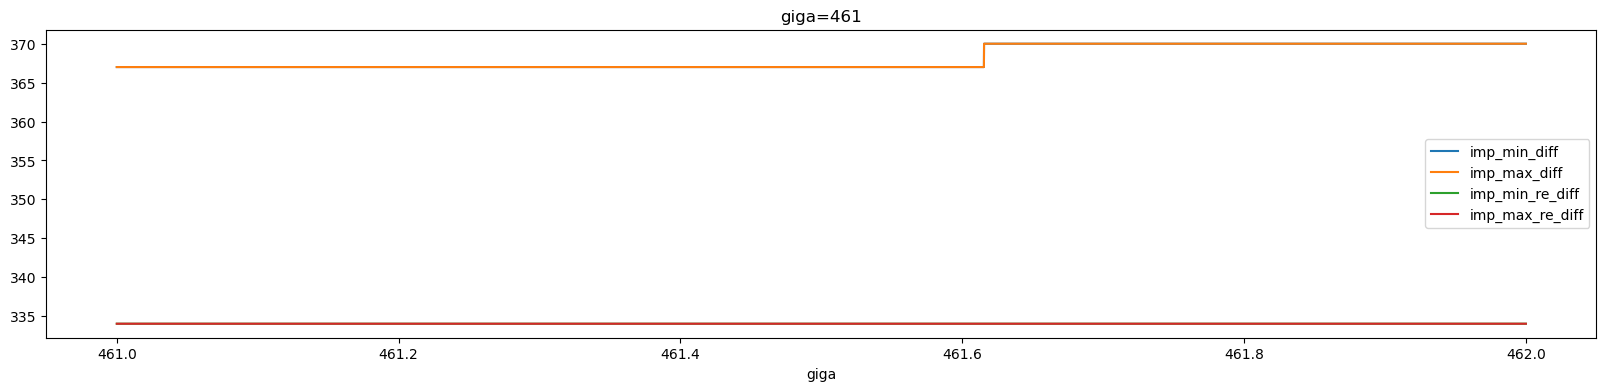

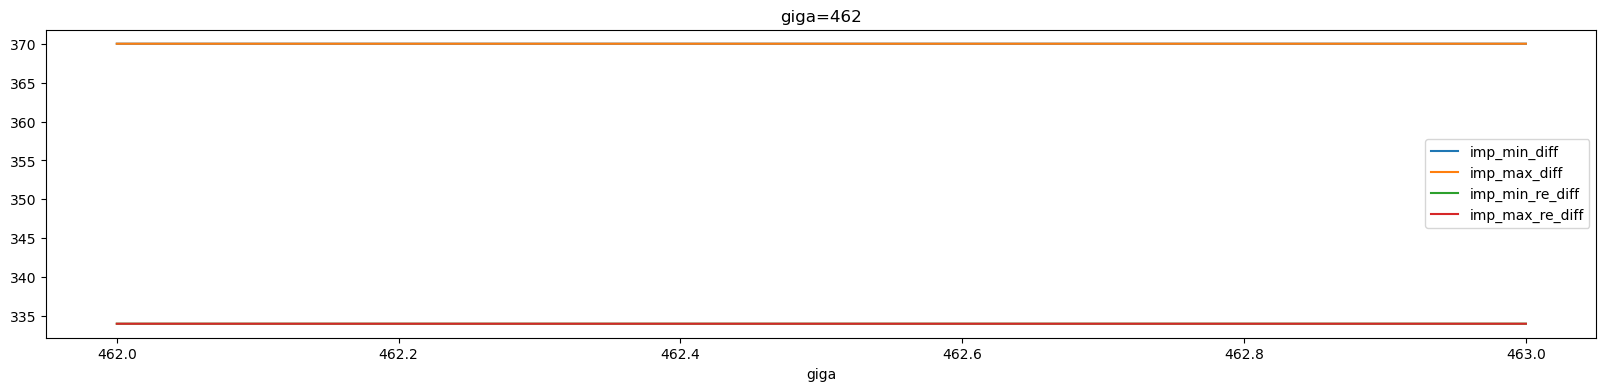

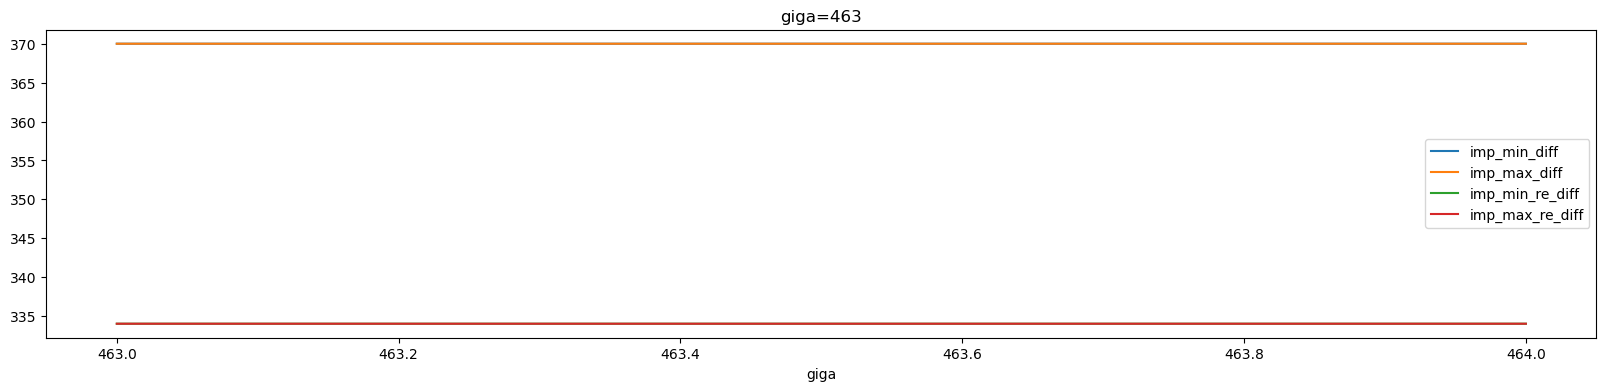

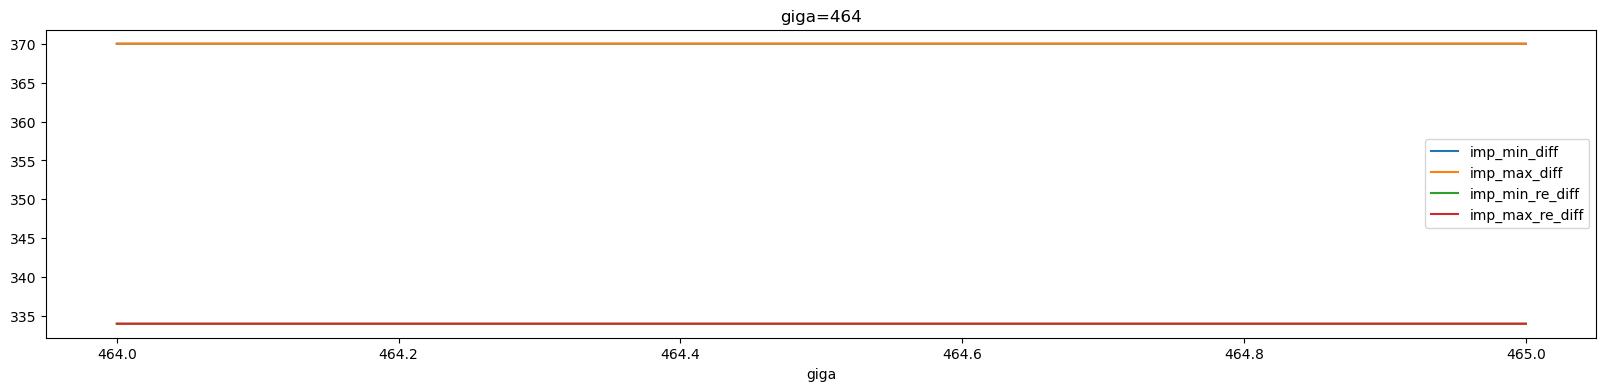

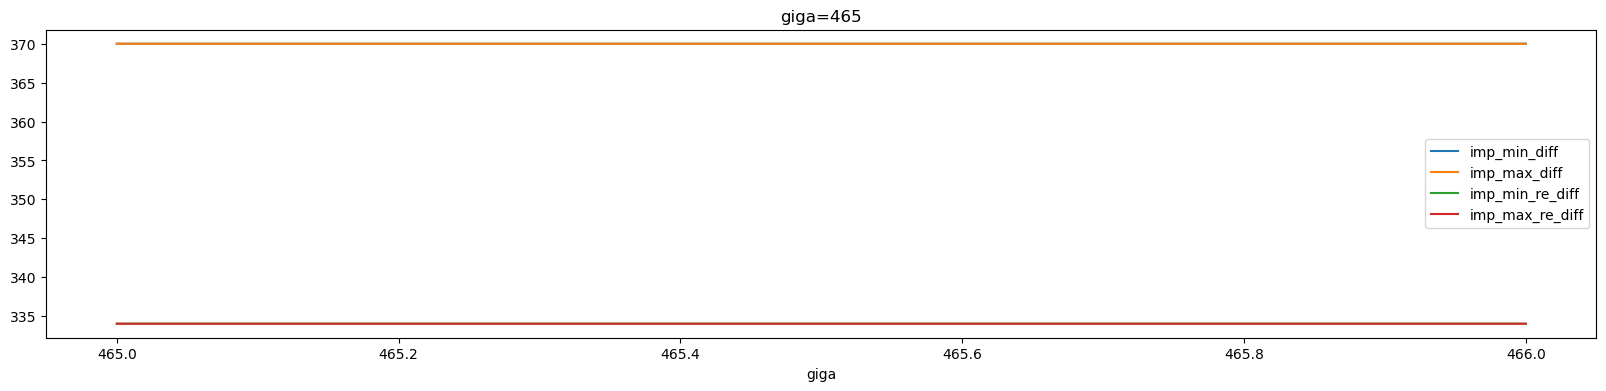

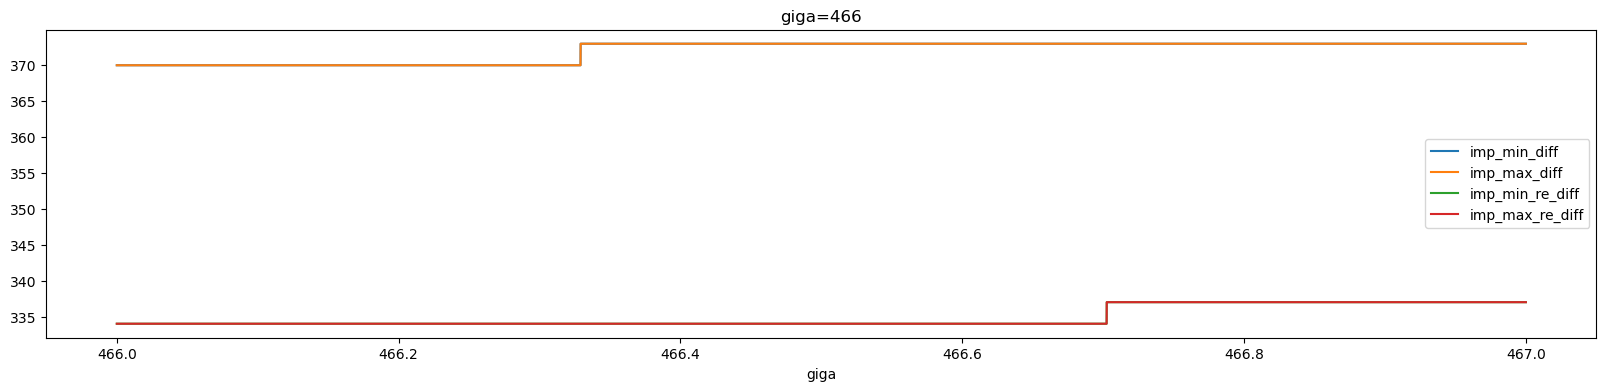

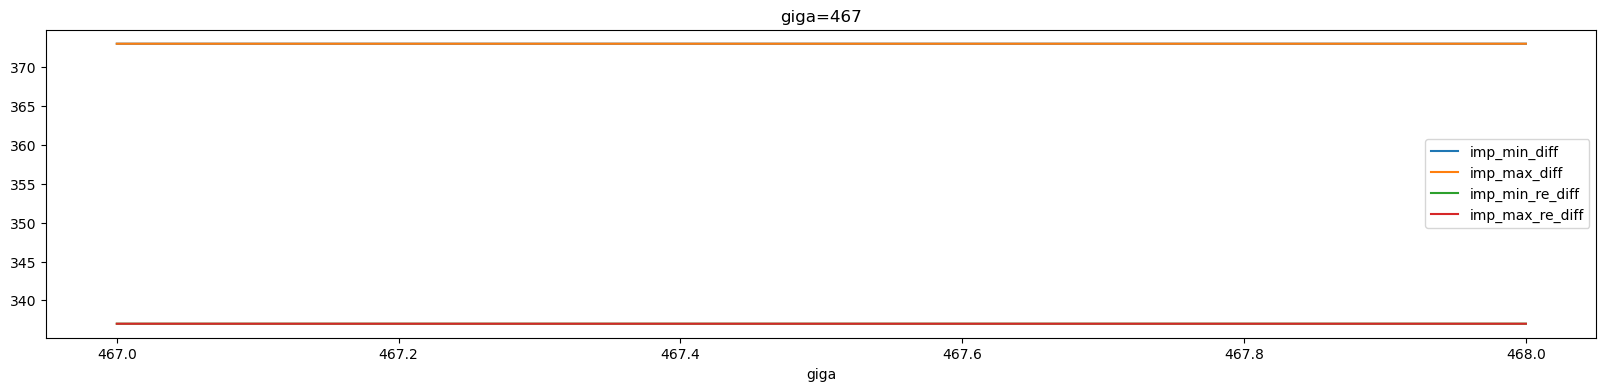

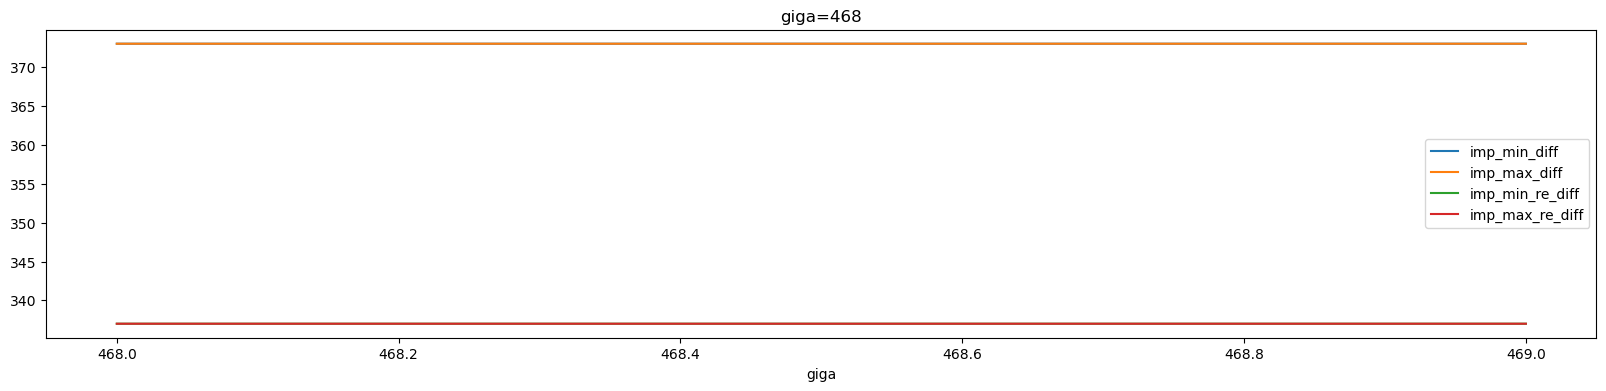

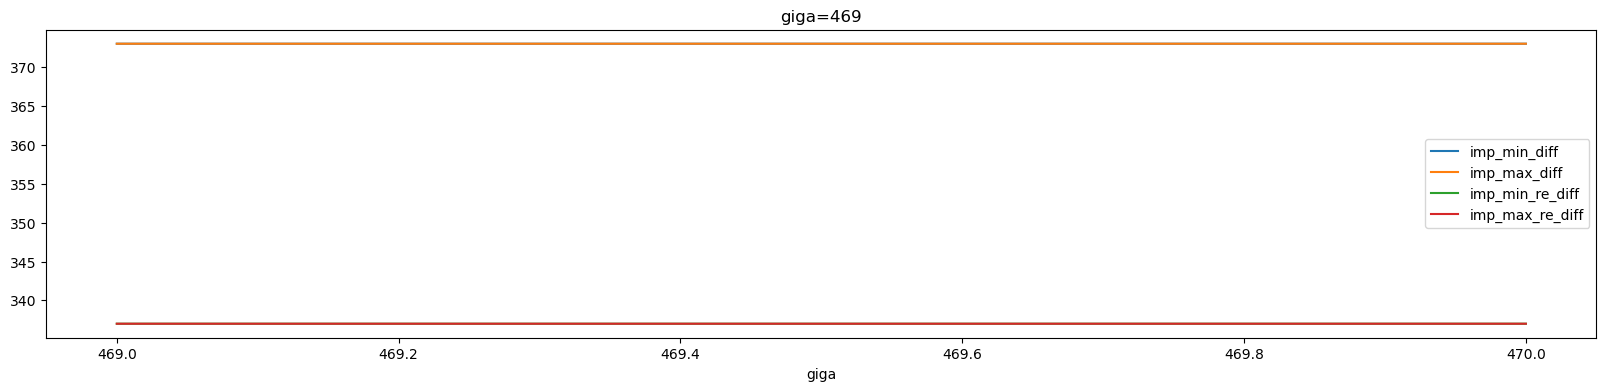

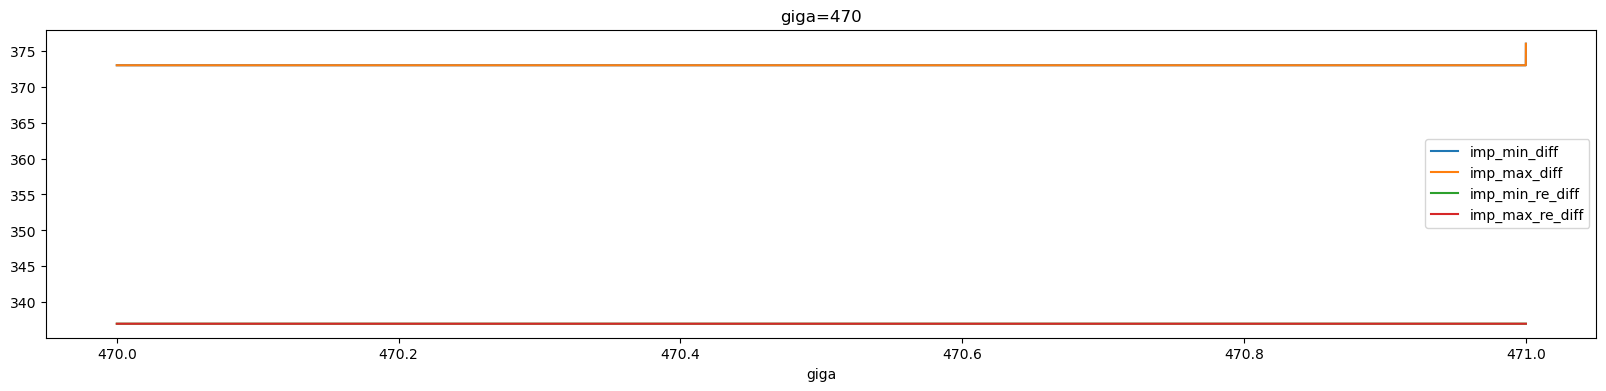

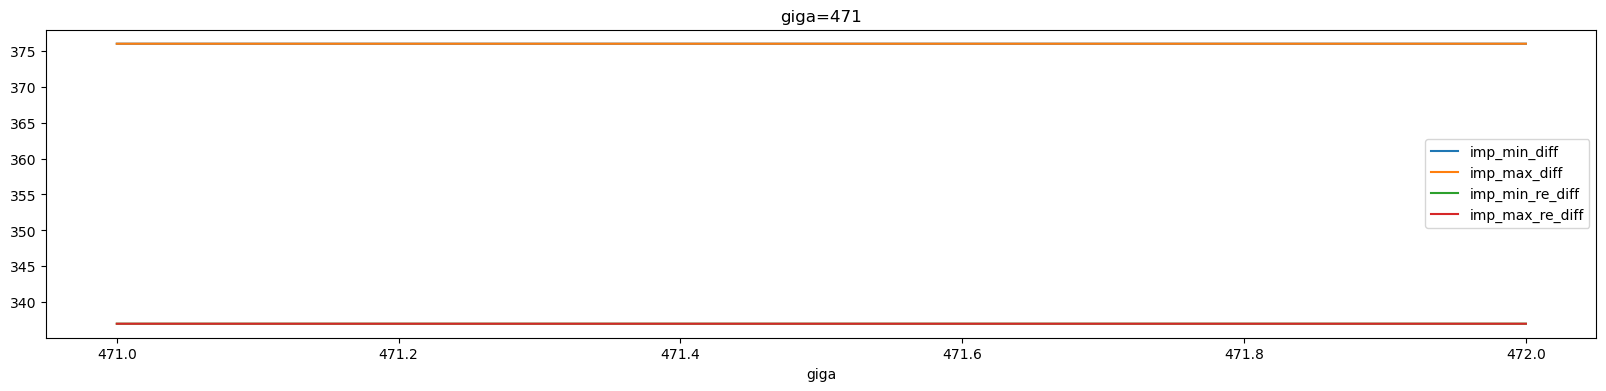

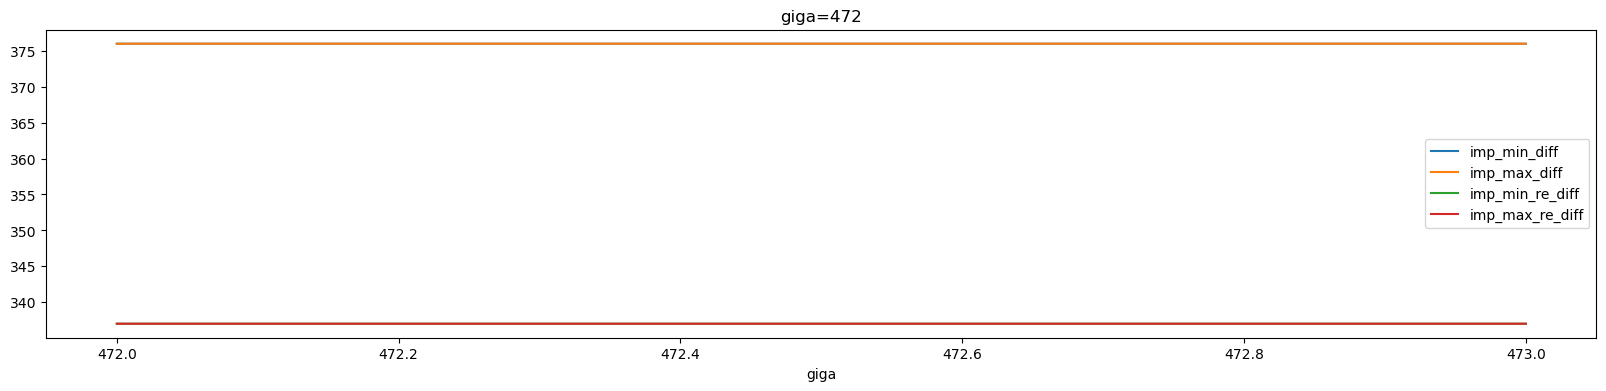

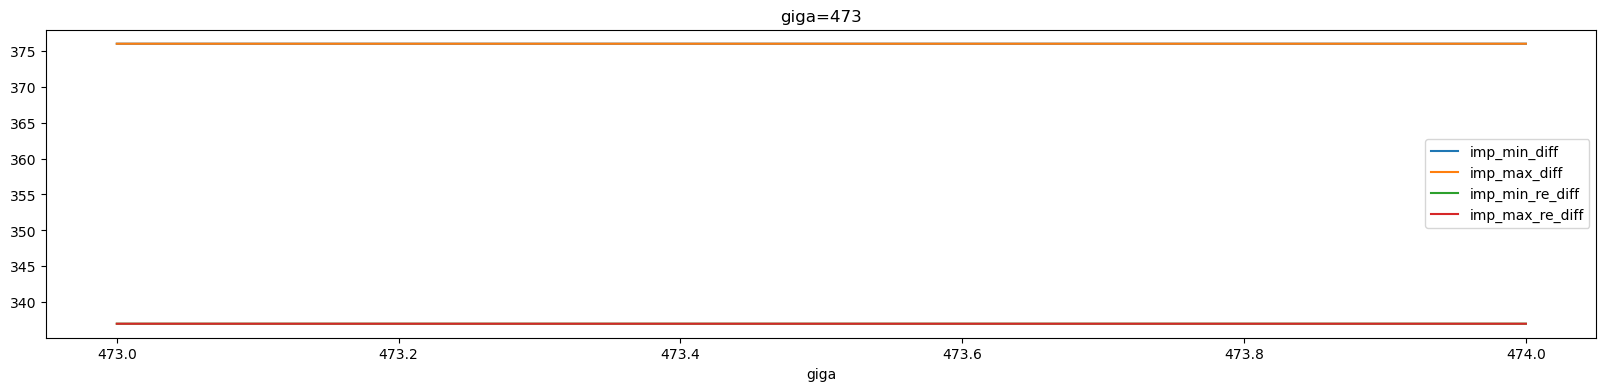

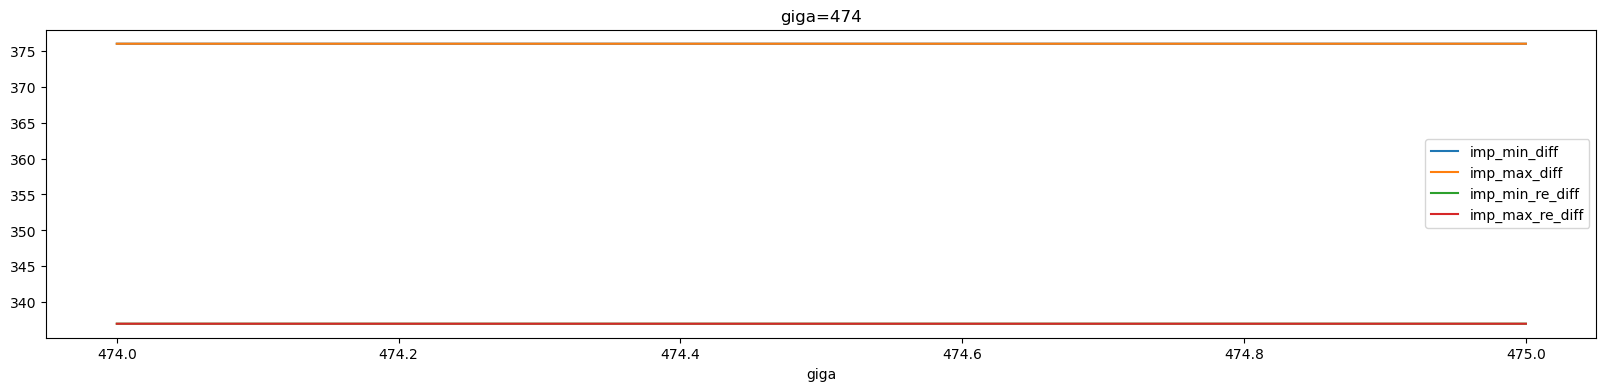

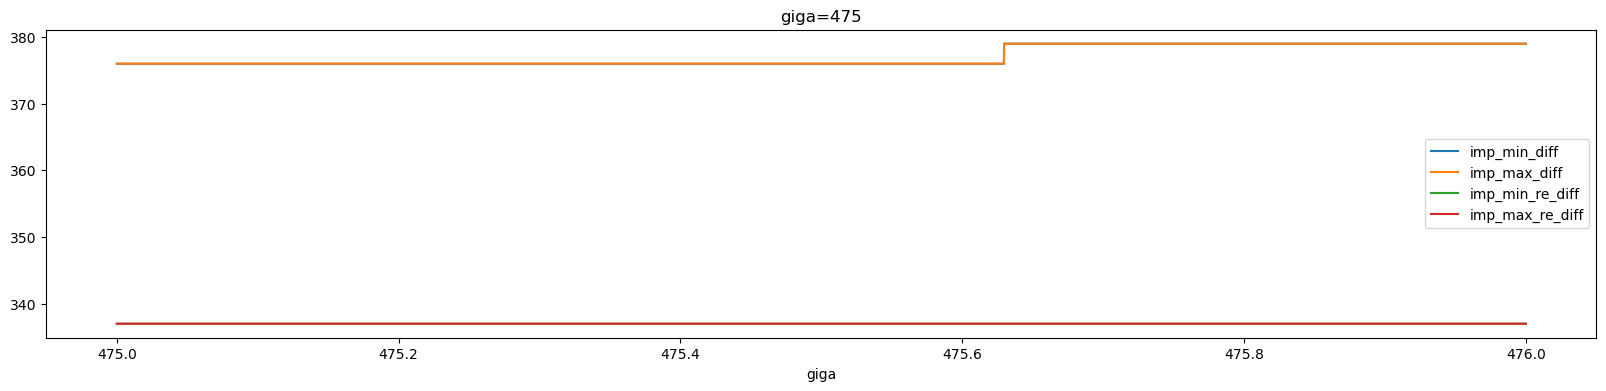

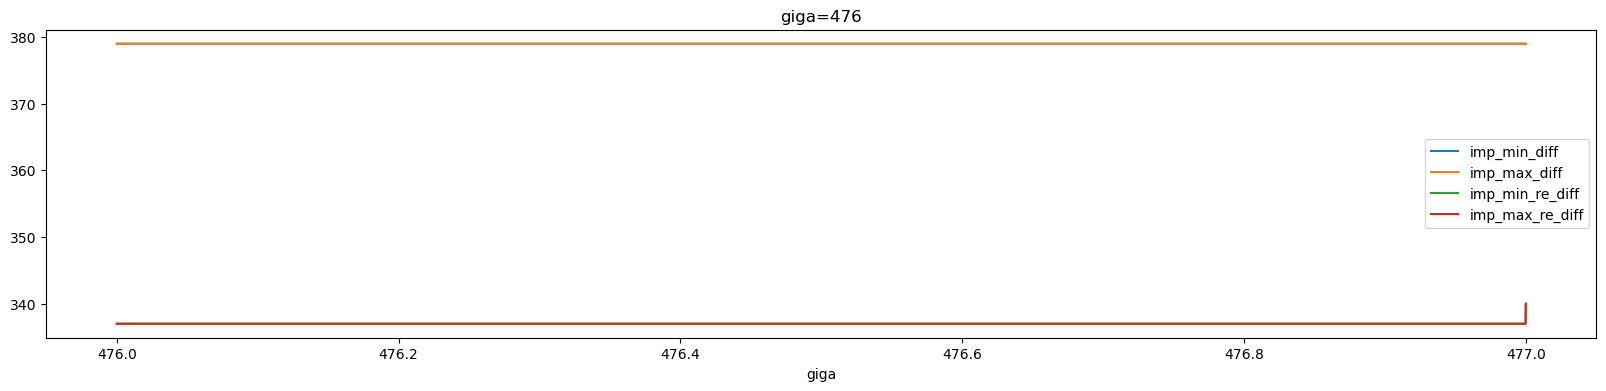

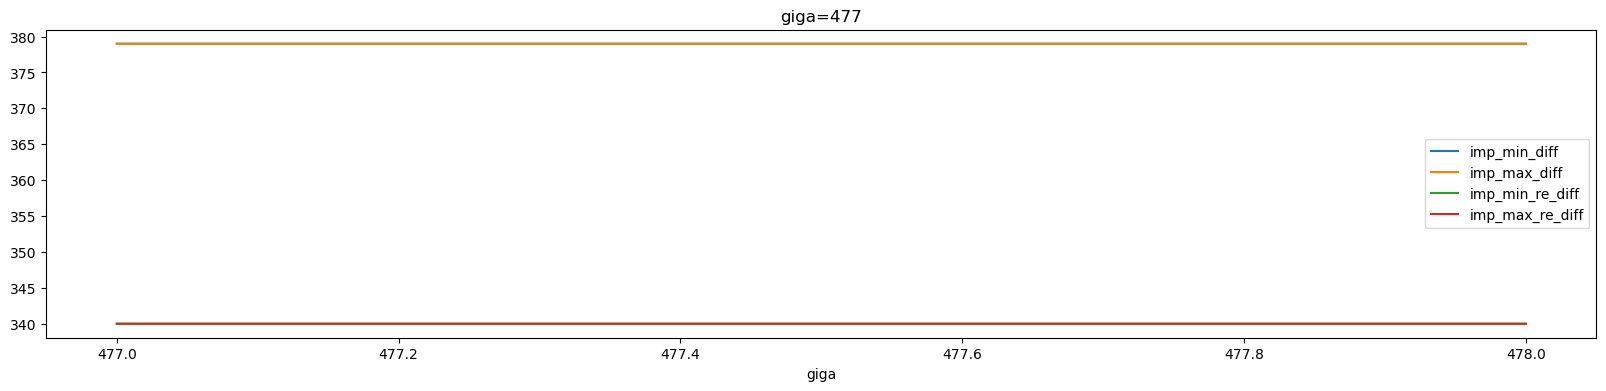

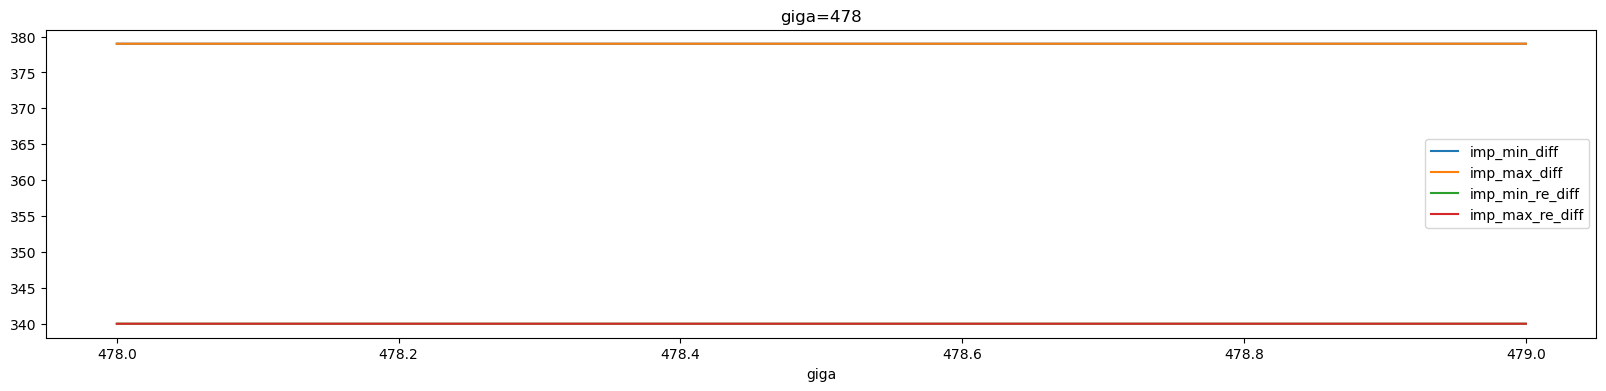

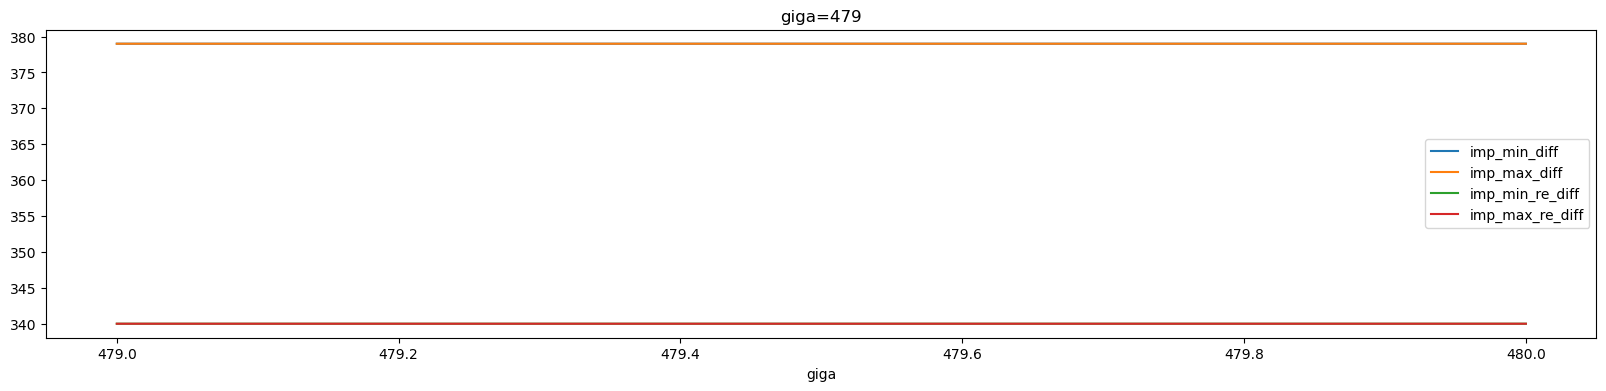

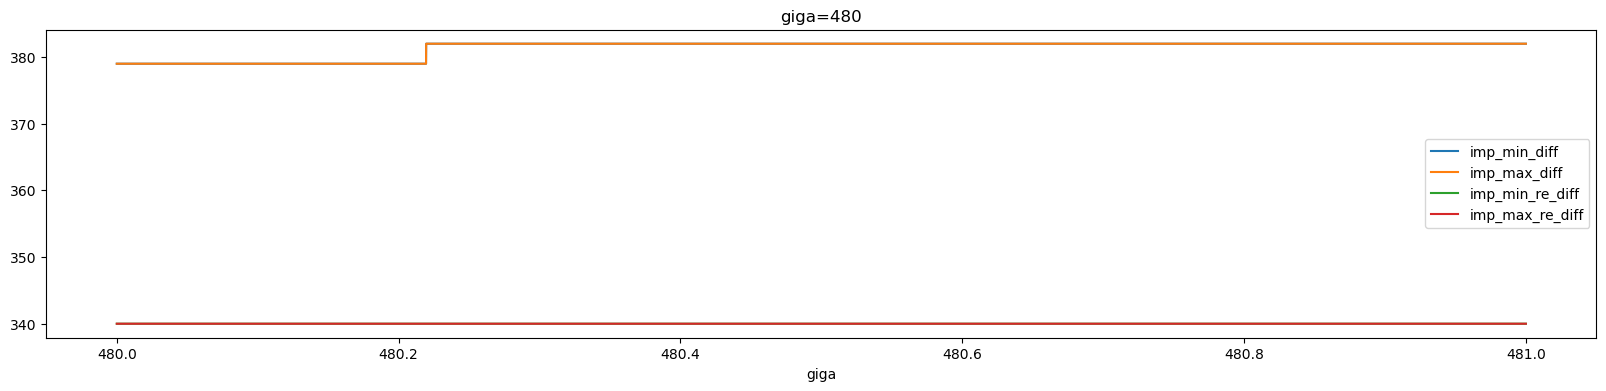

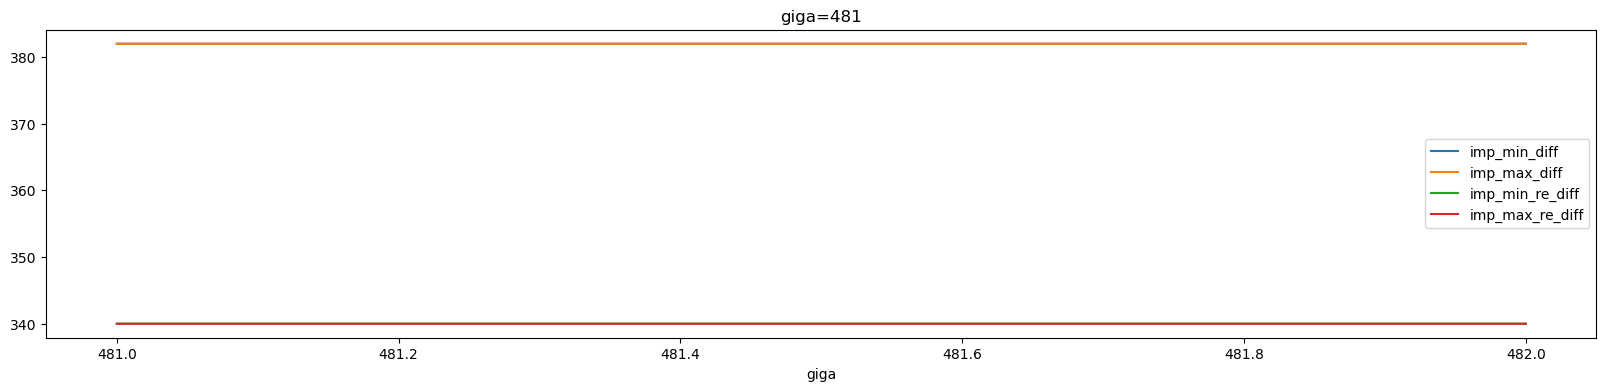

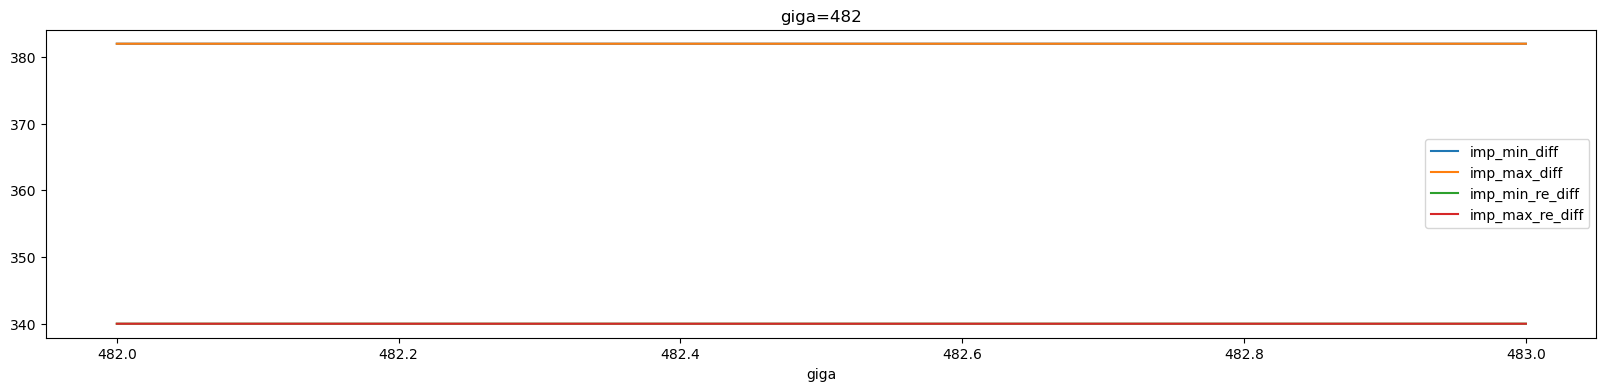

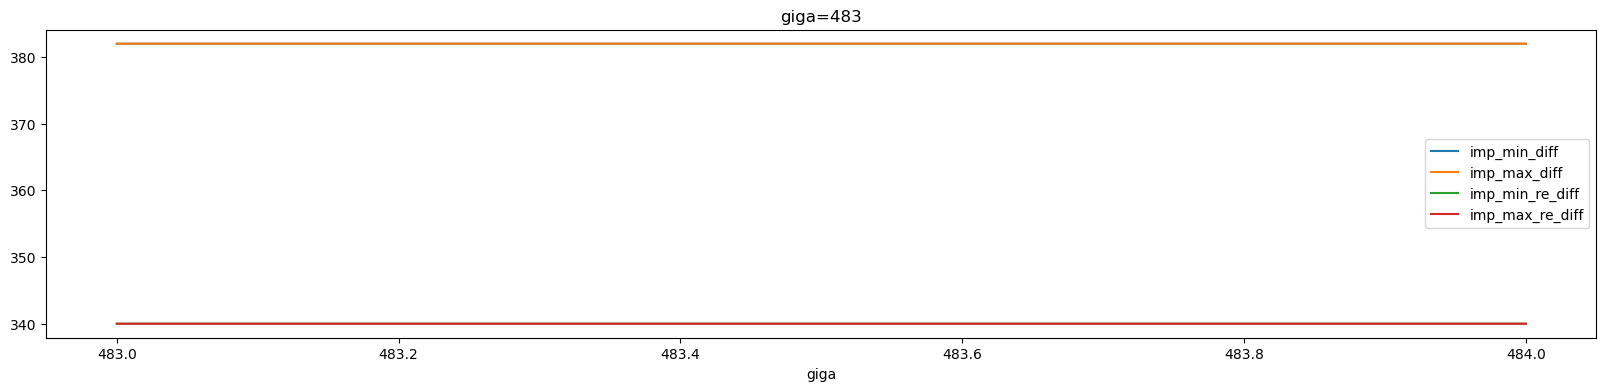

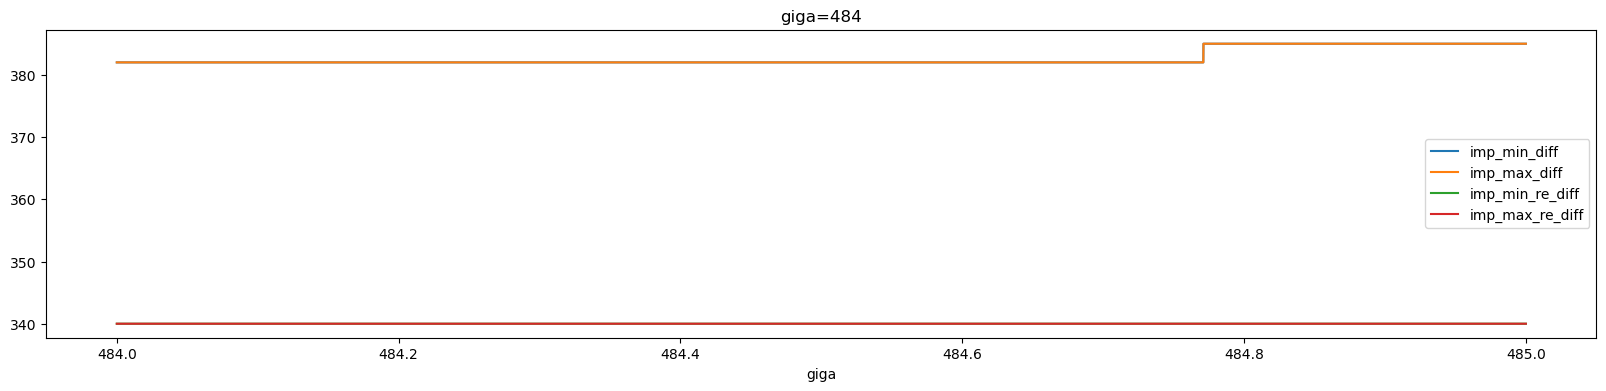

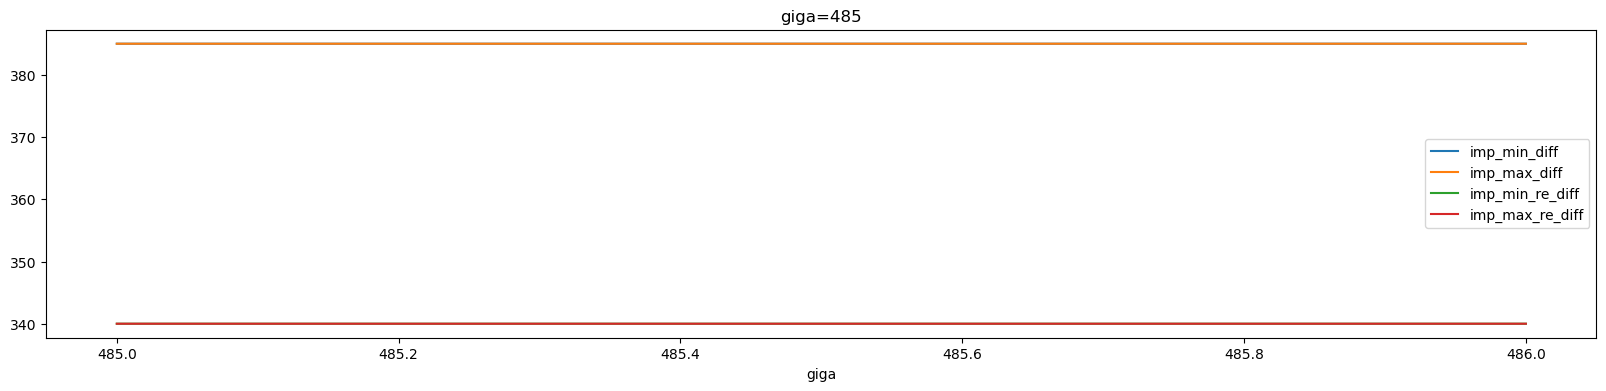

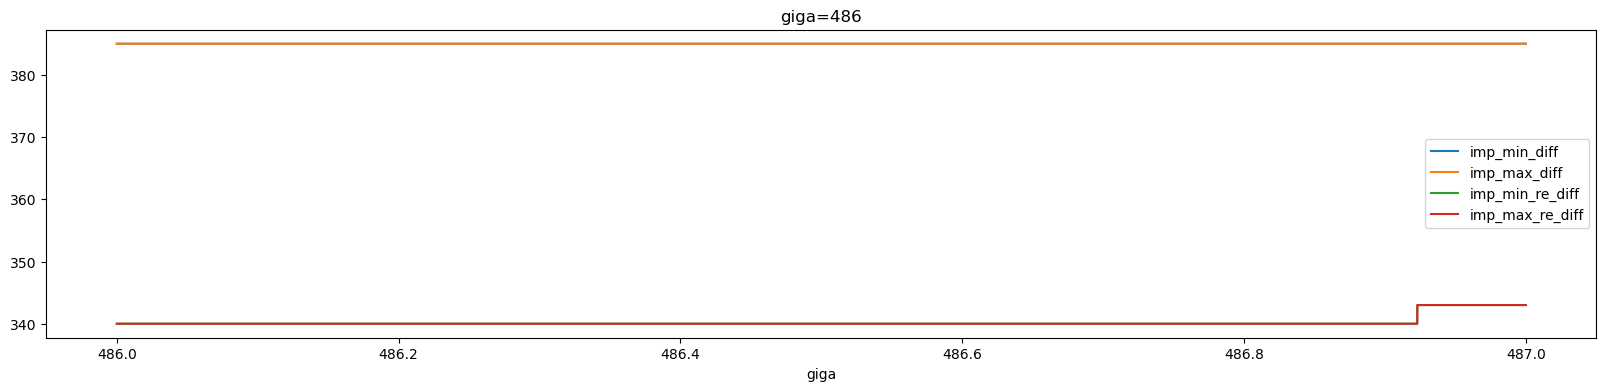

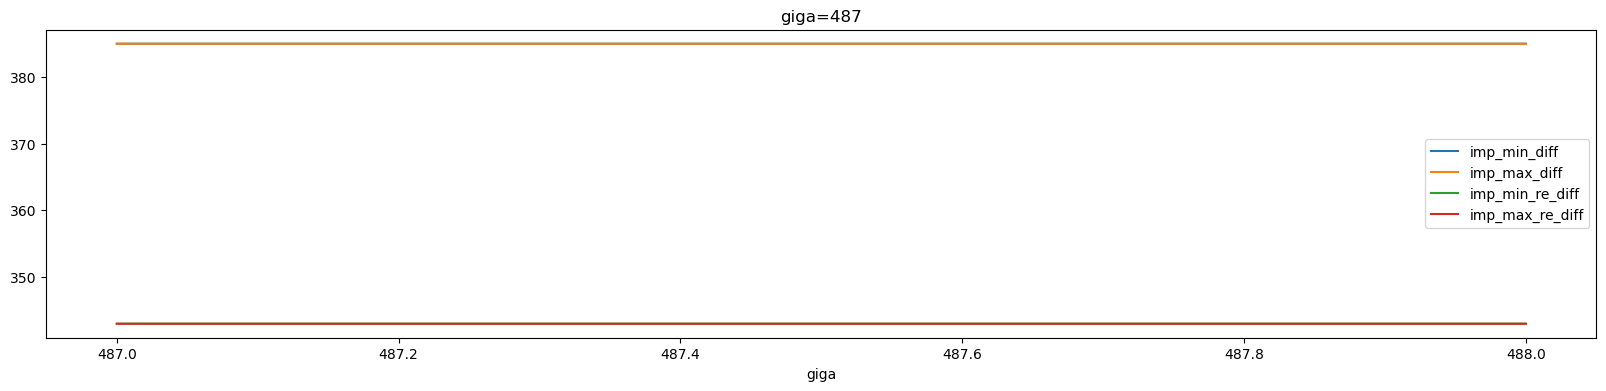

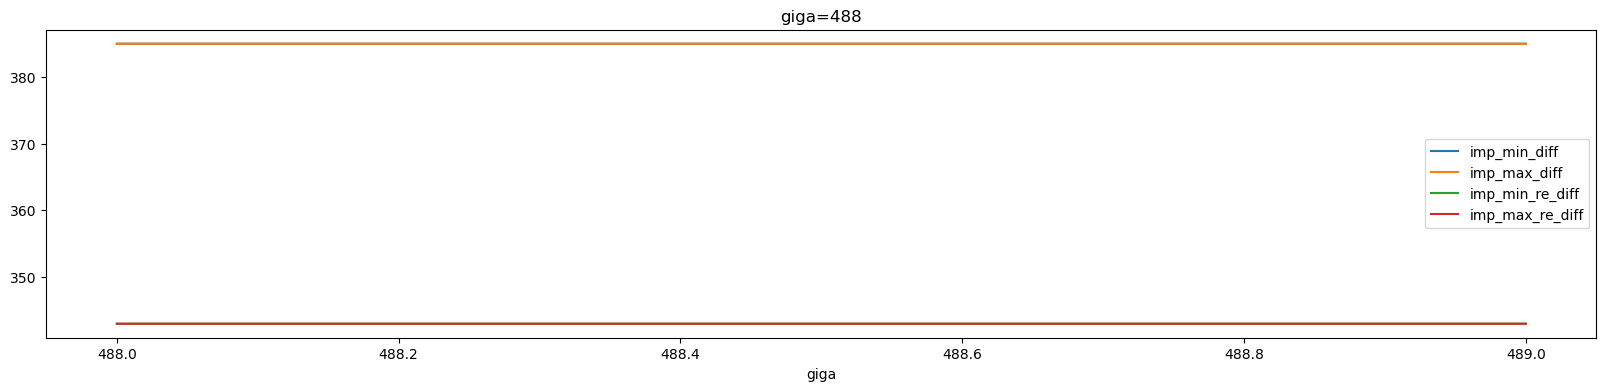

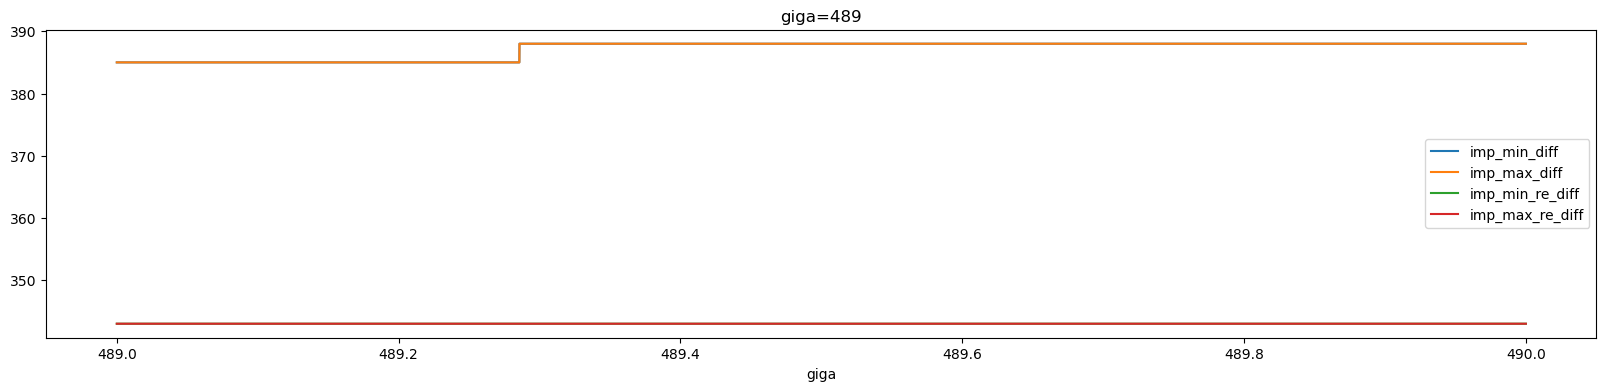

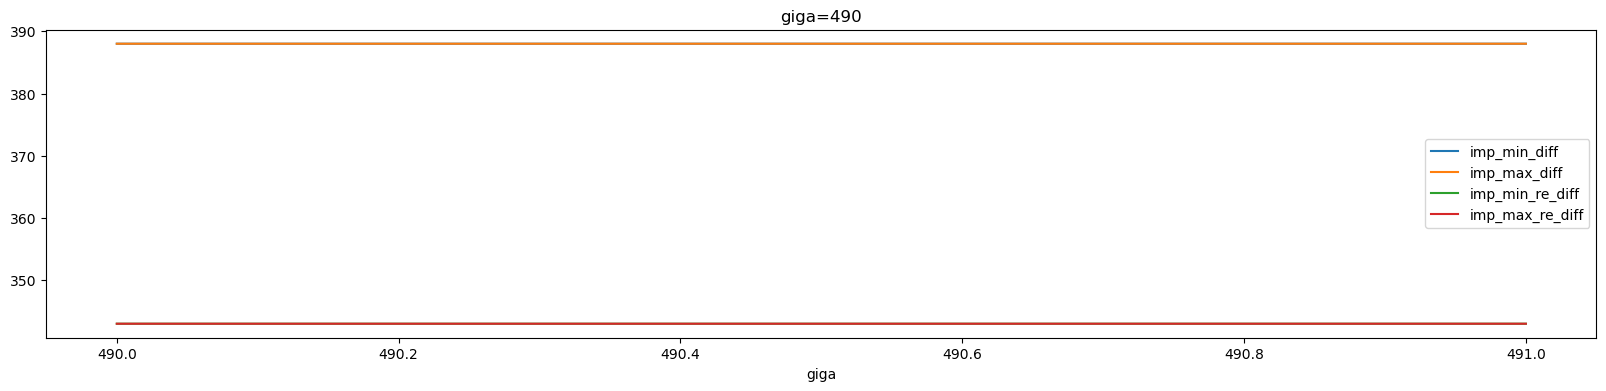

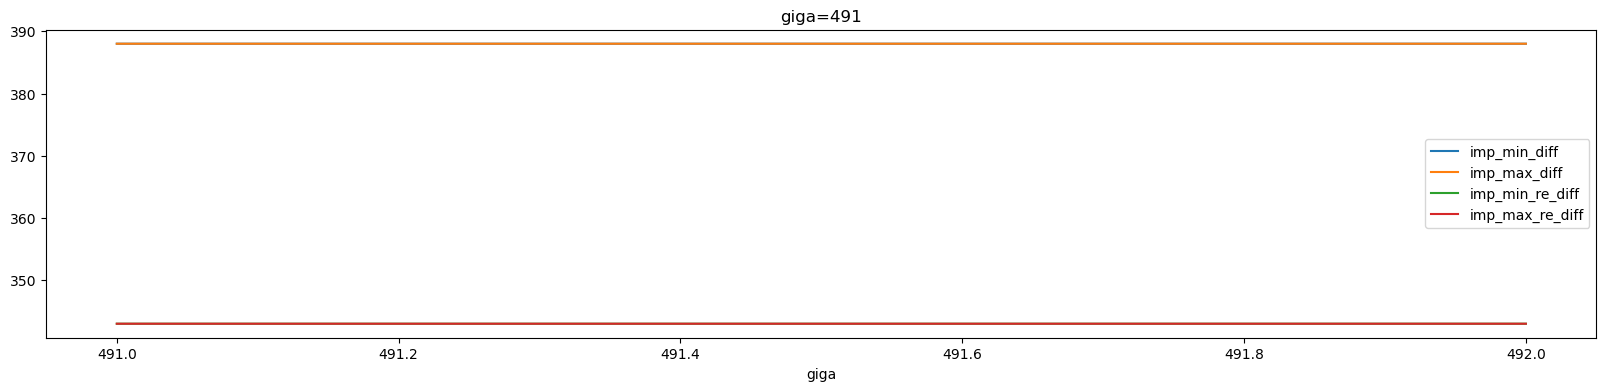

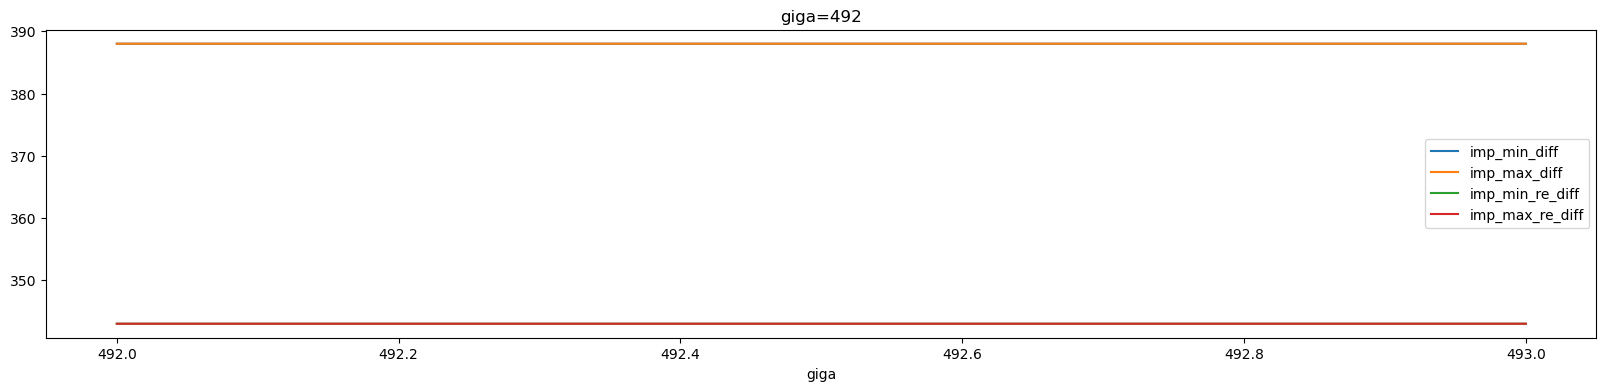

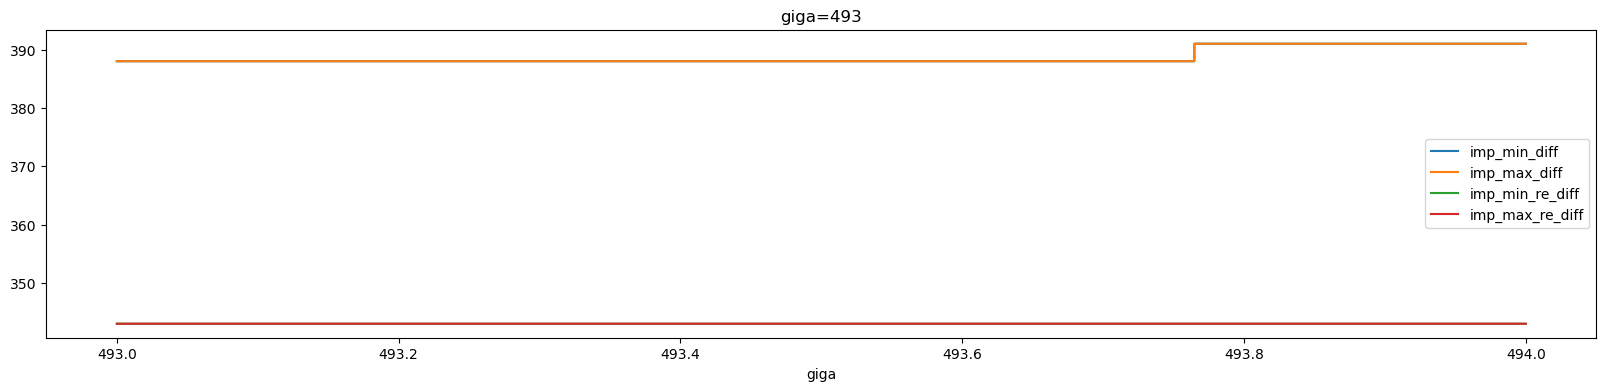

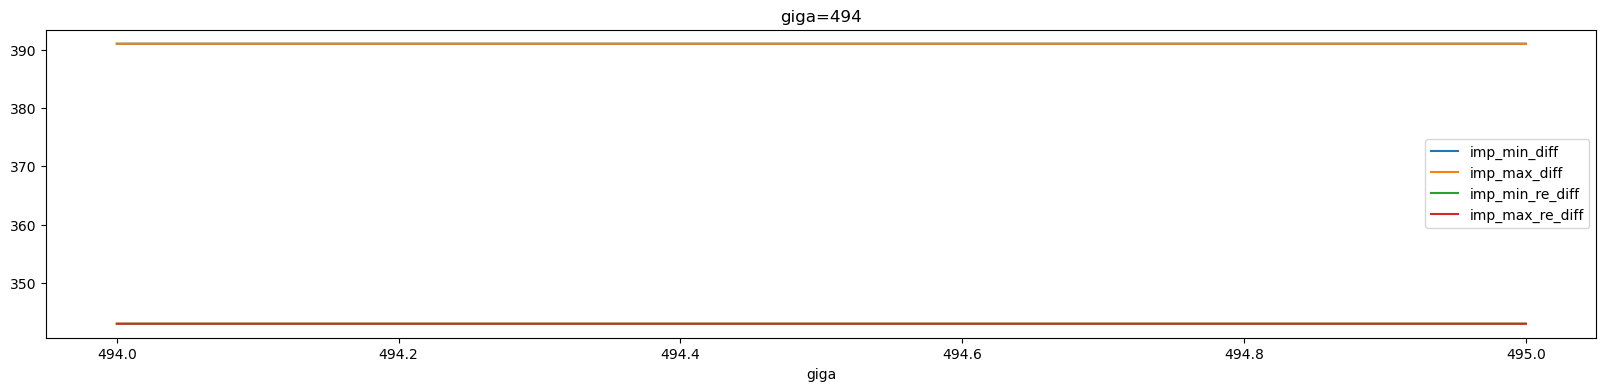

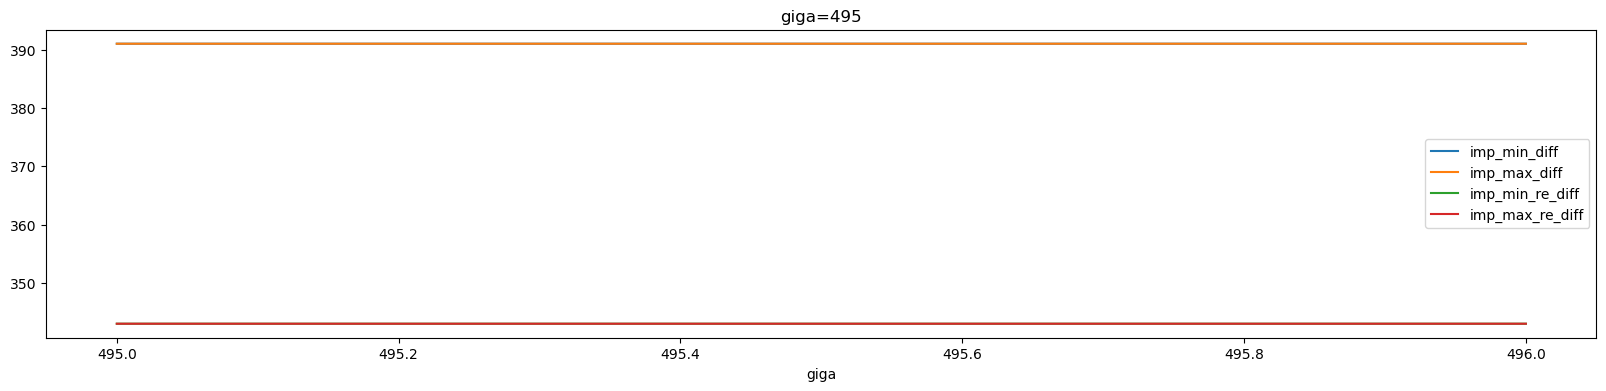

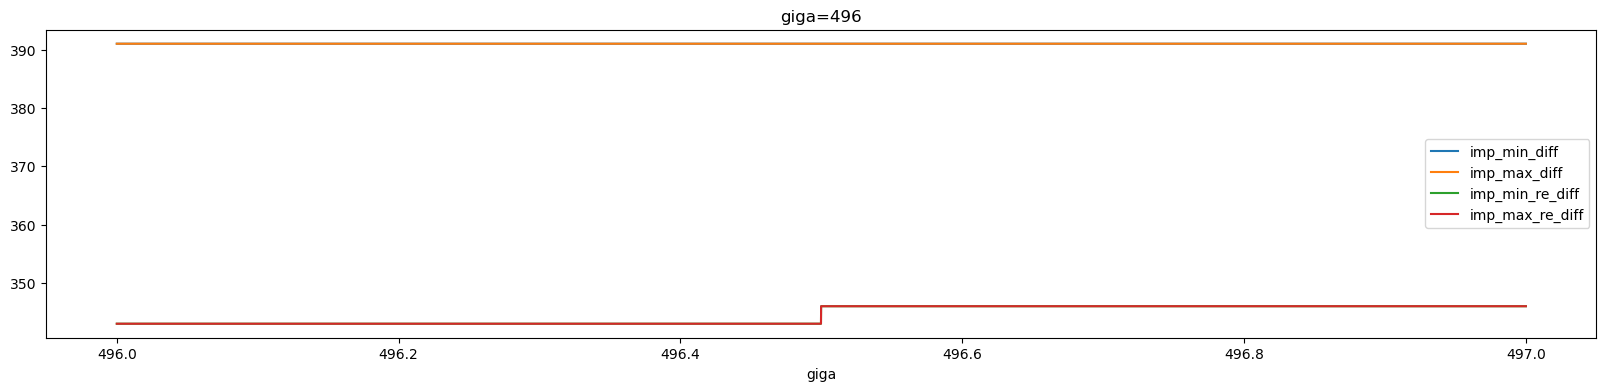

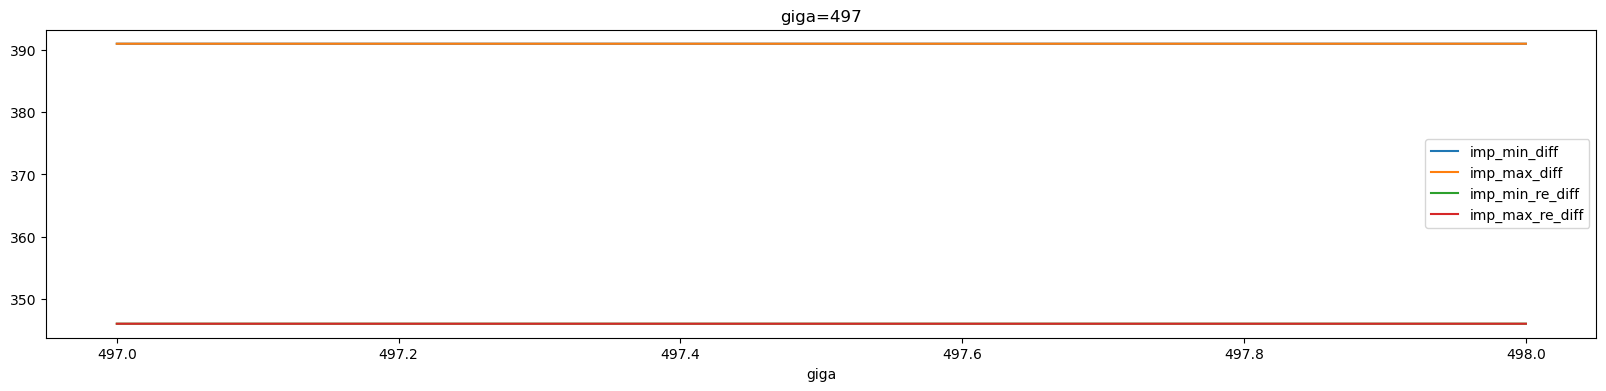

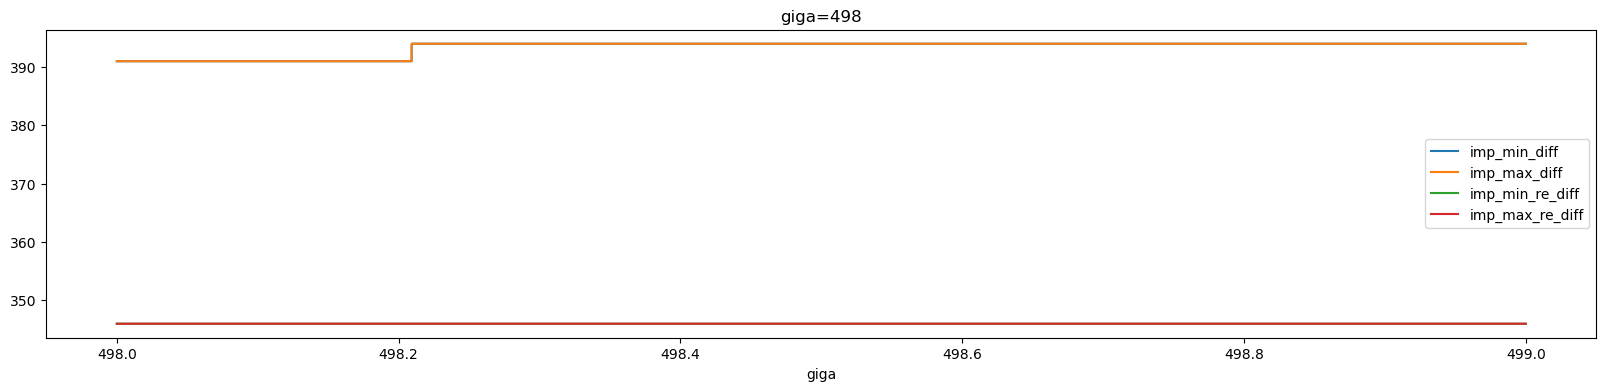

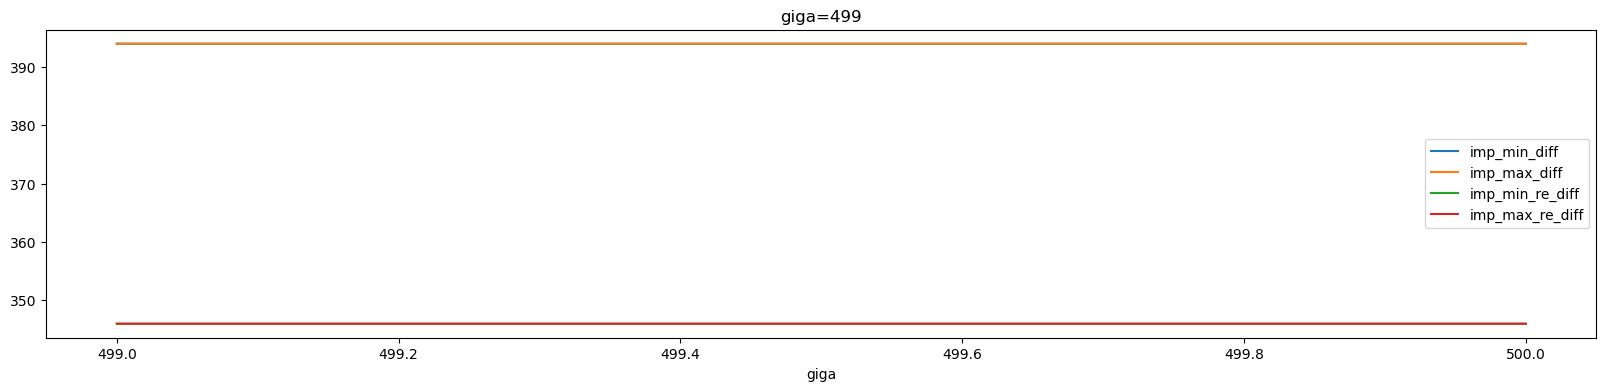

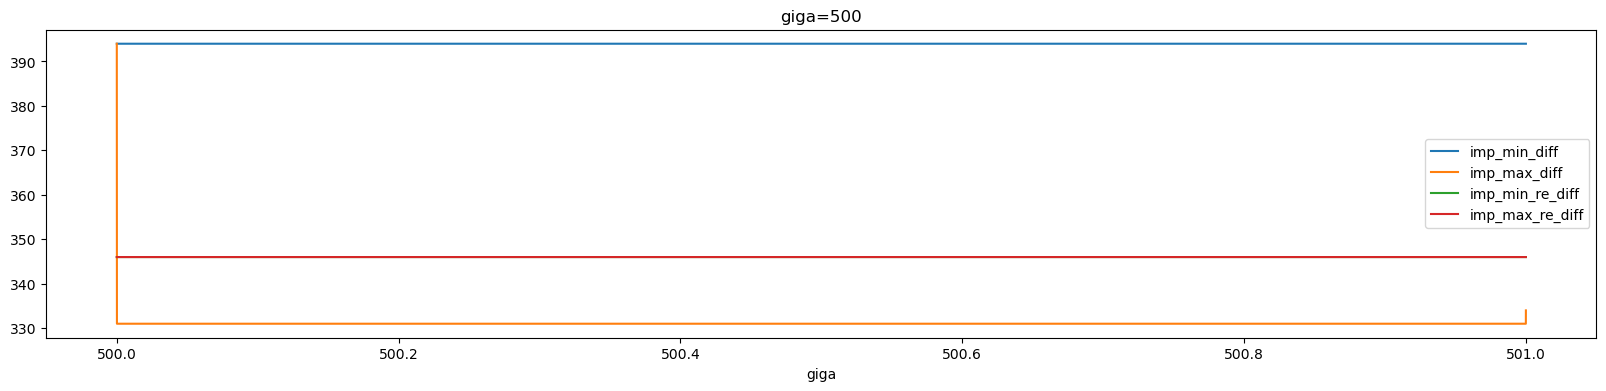

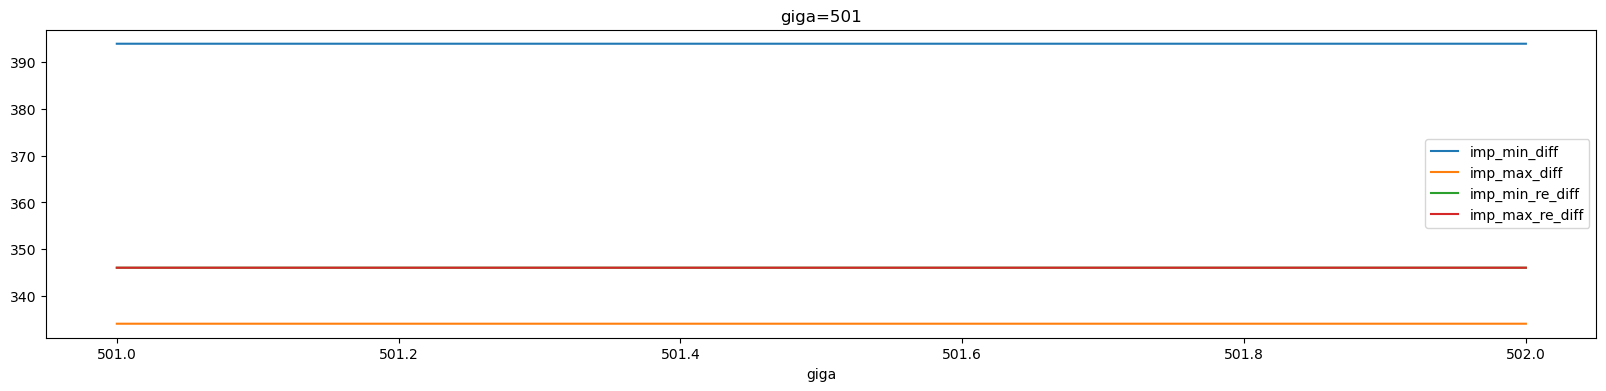

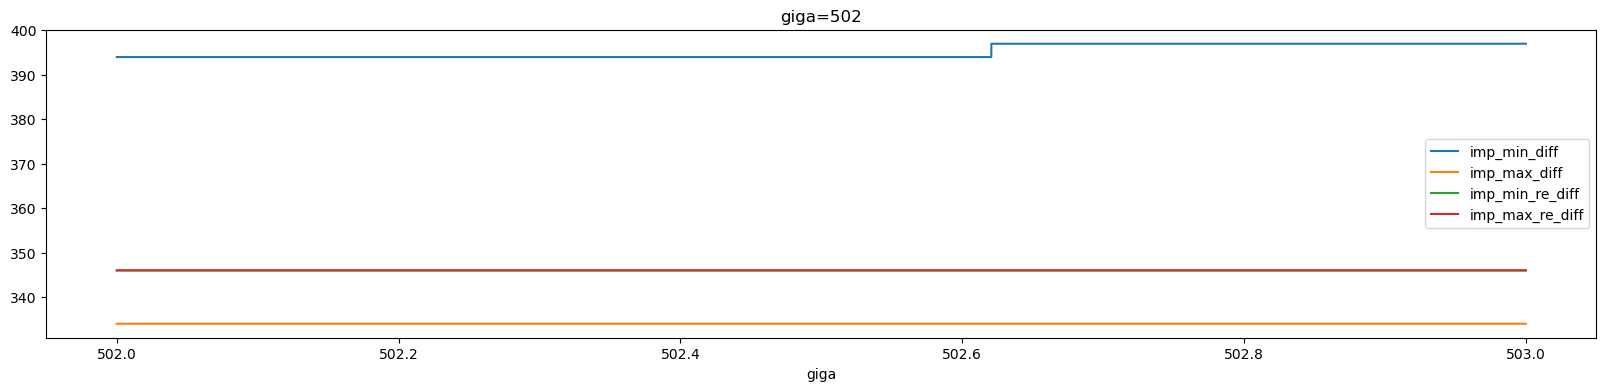

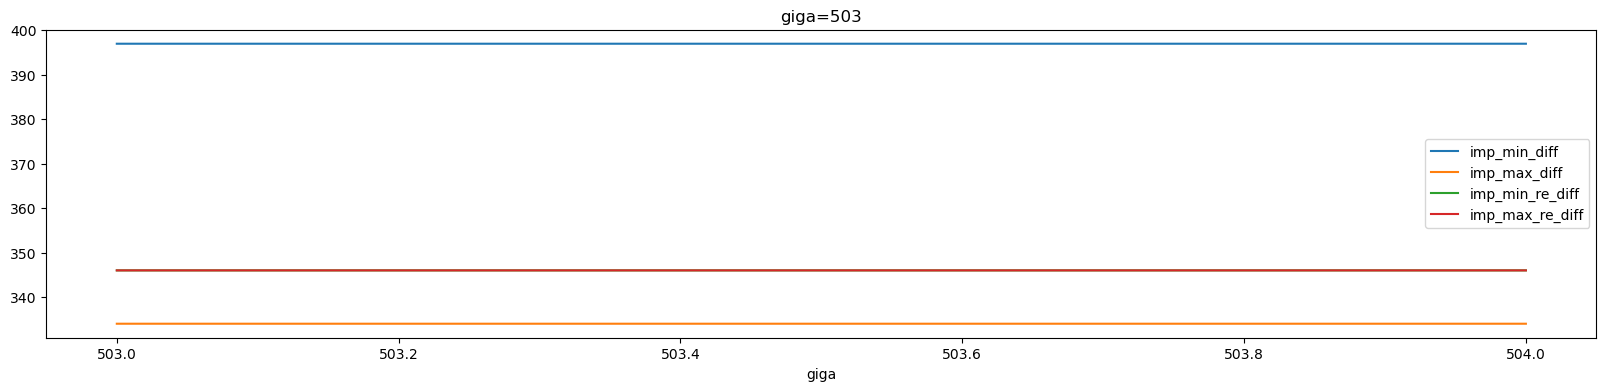

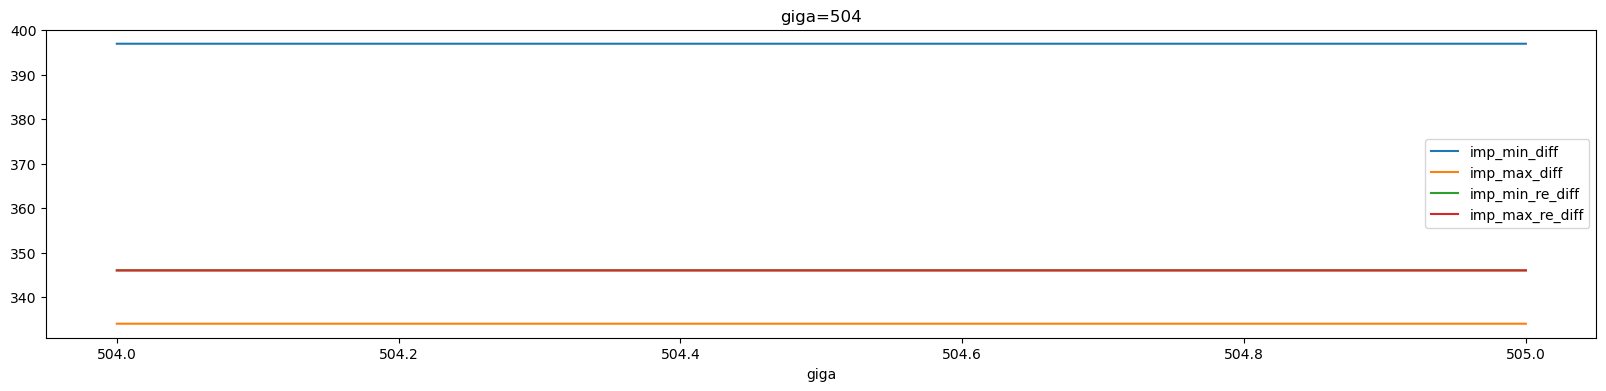

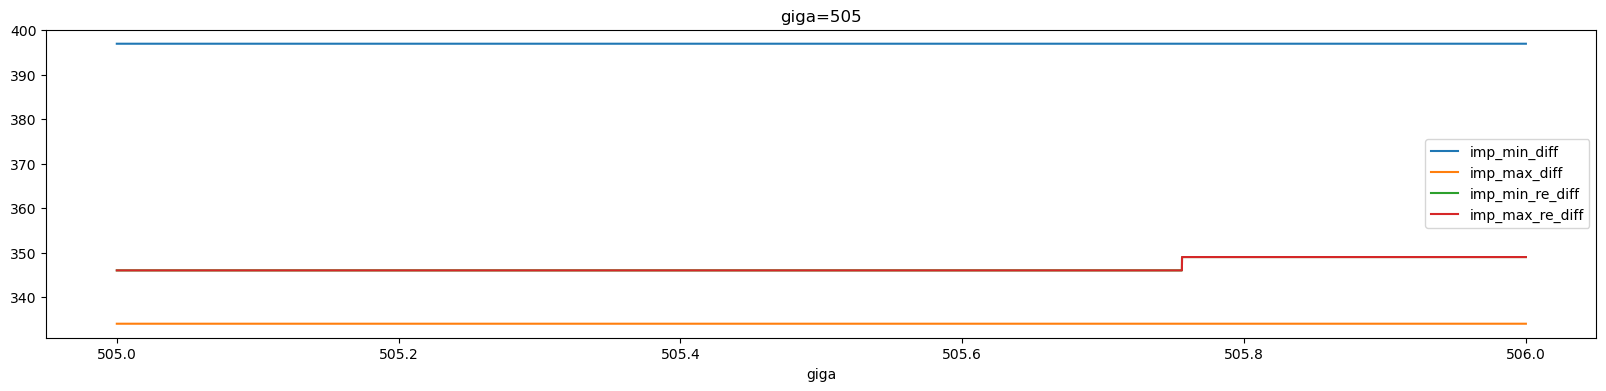

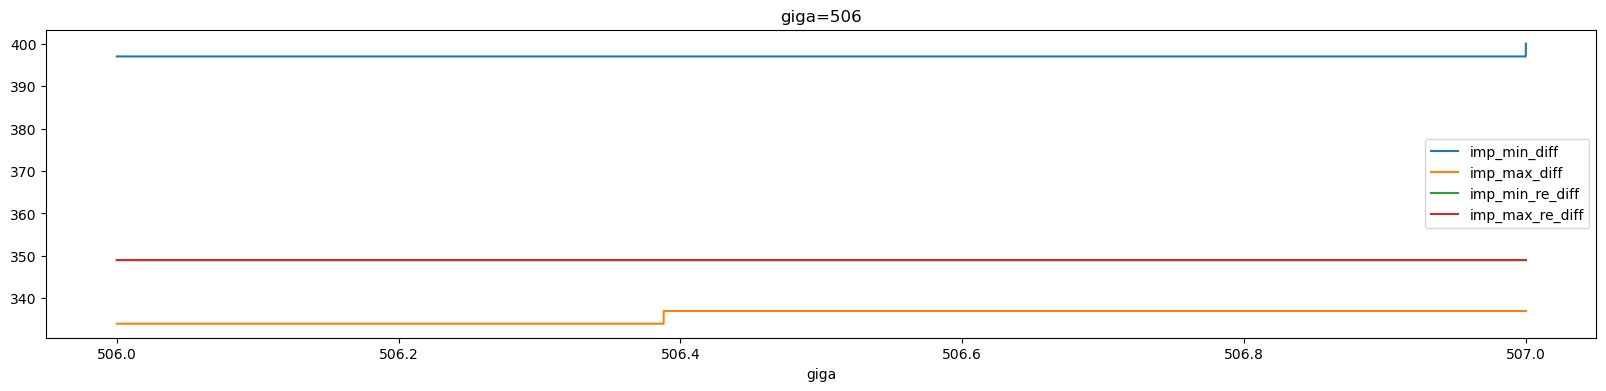

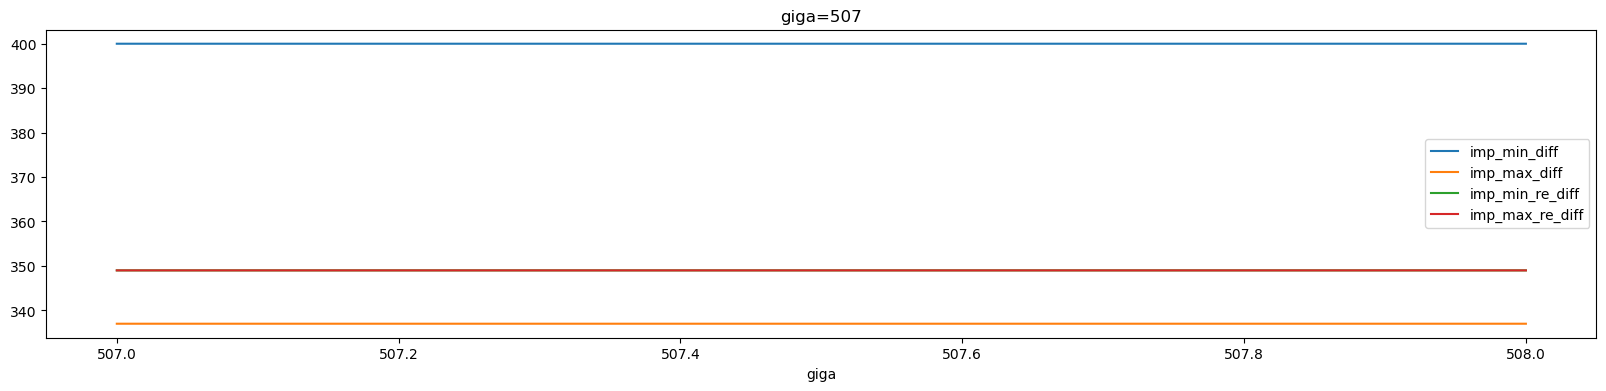

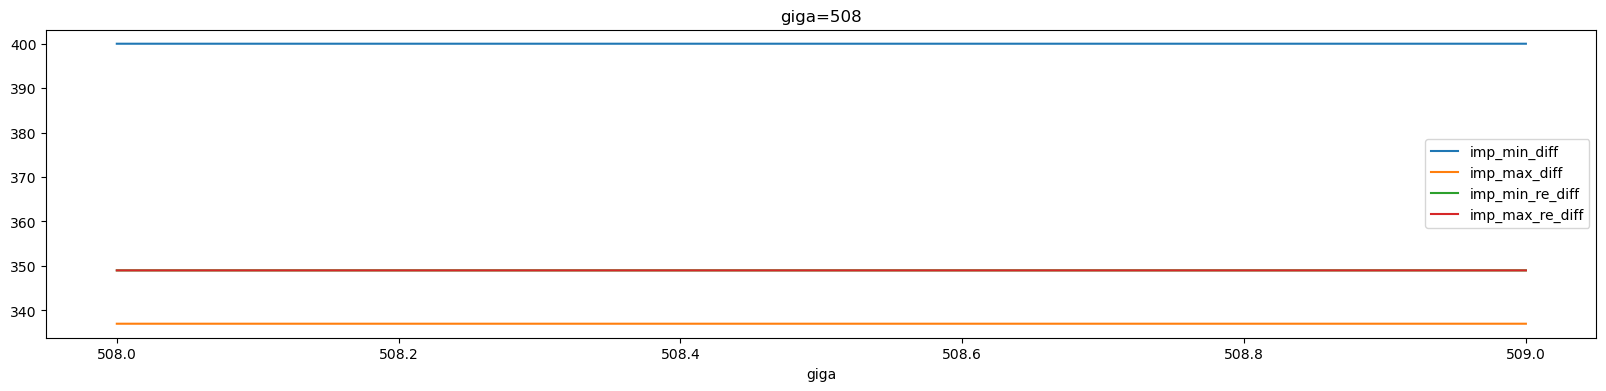

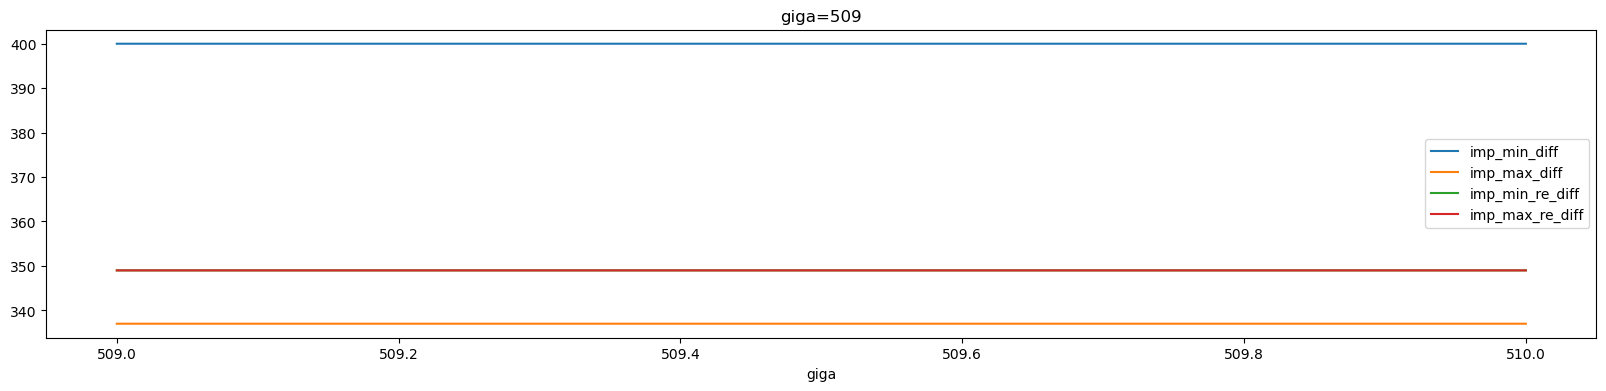

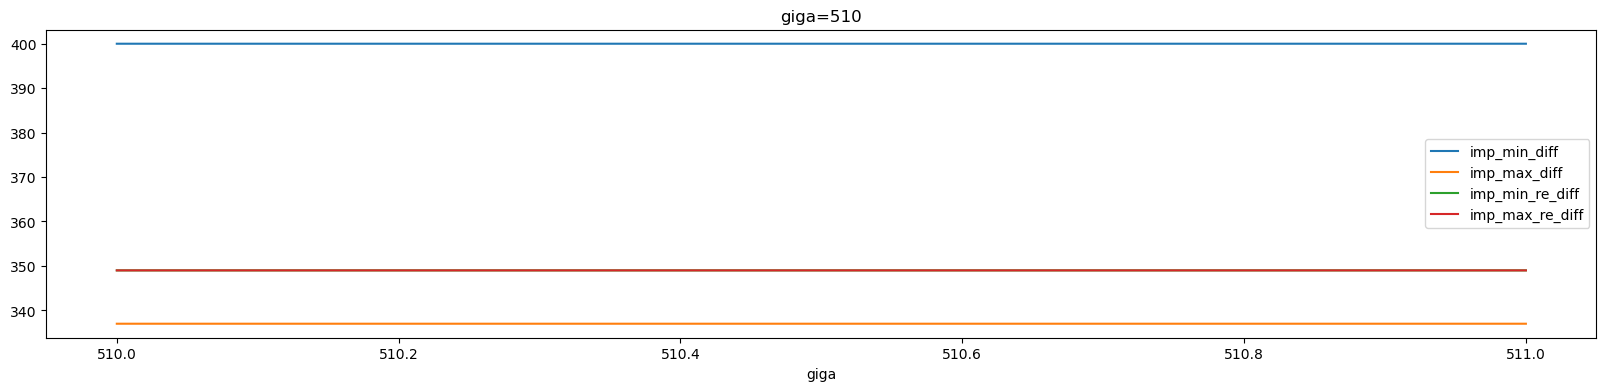

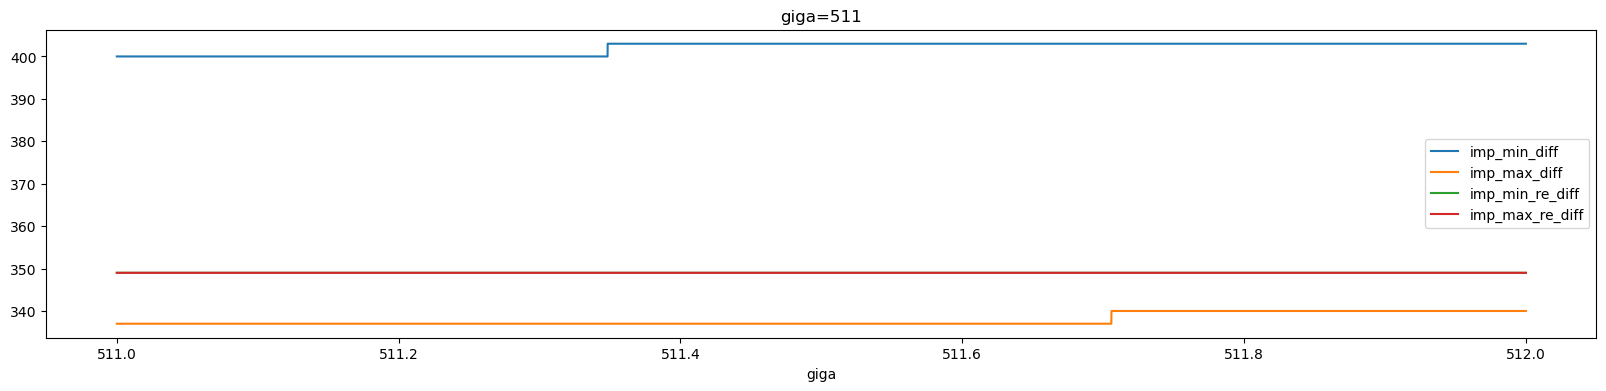

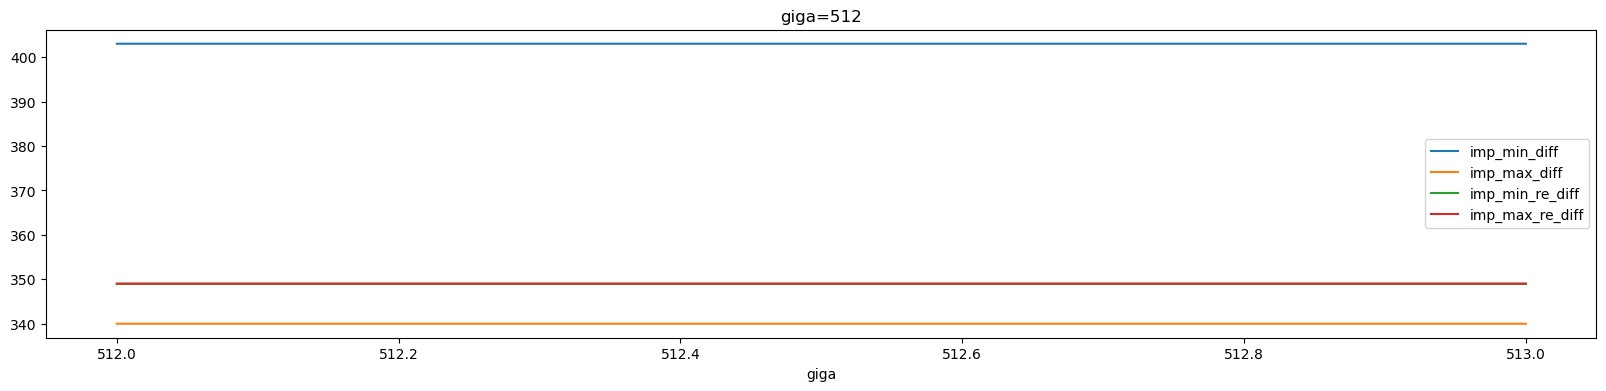

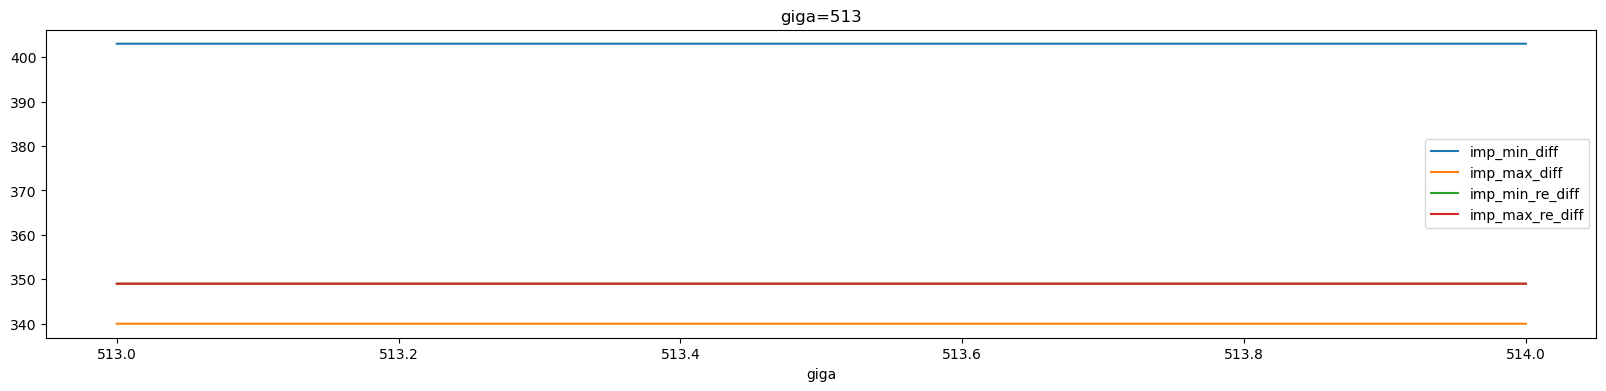

KeyboardInterrupt: 

In [10]:
for x_int in range(400, 855):
    df_sub = df[df['giga_int'] == x_int]
    df_sub.plot(
        x='giga', 
        y=['imp_min_diff', 'imp_max_diff', 'imp_min_re_diff', 'imp_max_re_diff'], 
        figsize=(20, 4), title=f'giga={x_int}'
    )
    plt.show()

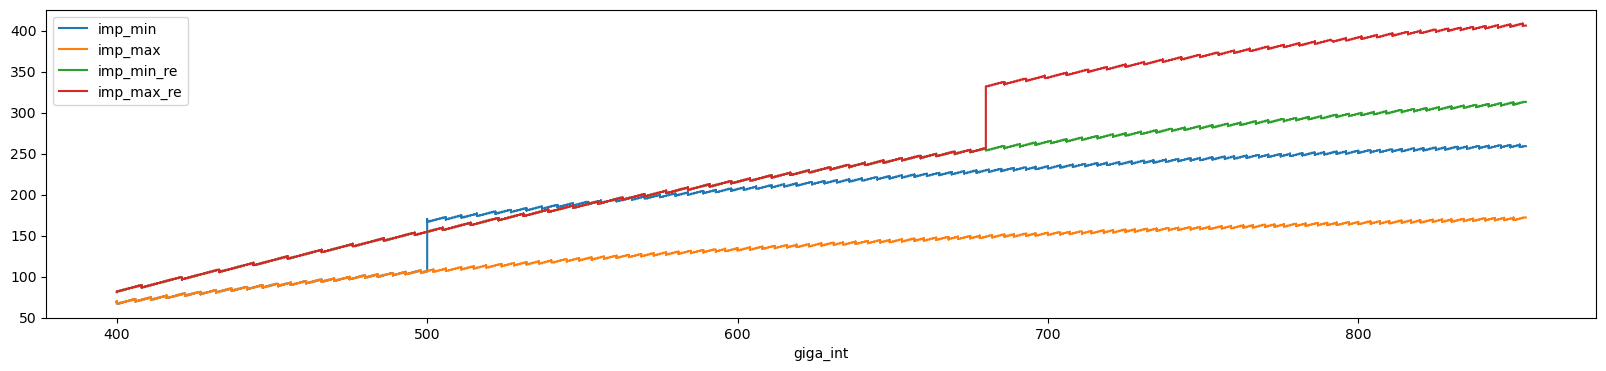

In [ ]:
df.plot(x='giga_int', y=['imp_min', 'imp_max', 'imp_min_re', 'imp_max_re'], figsize=(20, 4))
plt.show()

In [ ]:
# digger num
N = 100000
w_sum = 10401
arr = np.random.binomial(50, 1000.0/w_sum, N)

def handle_digger(n):
    tmp = np.random.randint(0,5,n)
    if tmp.size == 0:   return 0
    freq = np.bincount(tmp, minlength=5)    
    return freq.max()

handled = np.array([handle_digger(n) for n in arr])
handled[handled>=5].shape[0] / N * 100.0

1.366

In [ ]:
from scipy.stats import binom

w_sum = 10401
(1-binom.cdf(49, 50*8, 1000.0/w_sum))*100

3.414767603405089

In [ ]:
0x3e6b851f-0x3ebd70a4

-5368709